# Healthcare Question Answering and Chatbot System

### Advance NLP (AML23702)

**Domain:** Healthcare

**Approach:** Information Retrieval, Factoid Question Answering, Knowledge-Based QA, and Dialogue Management

## 1. Aim / Objective

To design and implement a healthcare question-answering and chatbot system that retrieves relevant medical information from a question-answer corpus, extracts factoid answers, queries a structured healthcare knowledge base, and handles simple conversational interactions.

## 2. Expected Outcomes

- Retrieve relevant passages or question-answer pairs for a healthcare question.
- Extract appropriate factoid answers from retrieved medical text.
- Query a structured healthcare knowledge source for disease-related information.
- Handle simple conversational interactions such as greetings, thanks, and follow-up questions.
- Evaluate the quality of the question-answering system using suitable evaluation metrics.

## 3. Tools and Technologies Used

| Tool / Technology | Purpose |
|---|---|
| Python | Main programming language |
| Jupyter Notebook | Development and experimentation environment |
| Pandas | Dataset loading and manipulation |
| NumPy | Numerical operations |
| NLTK | Text preprocessing and NLP |
| Scikit-learn | TF-IDF vectorization and cosine similarity |
| Streamlit | Chatbot user interface |
| MedQuAD | Healthcare question-answer corpus |
| CSV / Pandas DataFrame | Structured healthcare knowledge source |

## 4. Dataset / Corpus Description

The project uses the MedQuAD medical question-answer corpus as the primary healthcare QA dataset. The dataset contains medical questions and corresponding answers along with source and topic information. It is designed for medical question answering and retrieval-based applications.

The dataset will be cleaned and preprocessed before constructing the information retrieval system. Text preprocessing includes lowercasing, tokenization, removal of unnecessary characters and stopwords, and lemmatization.

The final dataset size and representative sample record will be reported after preprocessing.

In [2]:
!pip install pandas numpy nltk scikit-learn matplotlib seaborn datasets streamlit

Defaulting to user installation because normal site-packages is not writeable


DEPRECATION: Loading egg at c:\programdata\anaconda3\lib\site-packages\vboxapi-1.0-py3.11.egg is deprecated. pip 24.3 will enforce this behaviour change. A possible replacement is to use pip for package installation.. Discussion can be found at https://github.com/pypa/pip/issues/12330


In [14]:
import pandas as pd
import numpy as np
import re
import nltk

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

print("Libraries imported successfully!")

Libraries imported successfully!


In [16]:
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Student\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Student\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Student\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [18]:
url = "https://huggingface.co/datasets/prithvi1029/medquad-medical-qa/resolve/main/medquad-cleaned-qa.csv"

df = pd.read_csv(url)

print("Dataset loaded successfully!")
print("Shape:", df.shape)

Dataset loaded successfully!
Shape: (16407, 3)


In [20]:
df.head()

,qtype,Question,Answer
0,susceptibility,Who is at risk for Lymphocytic Choriomeningiti...,LCMV infections can occur after exposure to fr...
1,symptoms,What are the symptoms of Lymphocytic Choriomen...,LCMV is most commonly recognized as causing ne...
2,susceptibility,Who is at risk for Lymphocytic Choriomeningiti...,Individuals of all ages who come into contact ...
3,exams and tests,How to diagnose Lymphocytic Choriomeningitis (...,"During the first phase of the disease, the mos..."
4,treatment,What are the treatments for Lymphocytic Chorio...,"Aseptic meningitis, encephalitis, or meningoen..."


In [22]:
df.columns

Index(['qtype', 'Question', 'Answer'], dtype='object')

In [24]:
df.shape

(16407, 3)

In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16407 entries, 0 to 16406
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   qtype     16407 non-null  object
 1   Question  16407 non-null  object
 2   Answer    16407 non-null  object
dtypes: object(3)
memory usage: 384.7+ KB


## 4.1 Dataset Inspection

The MedQuAD healthcare question-answer dataset contains 16,407 records and three attributes: `qtype`, `Question`, and `Answer`.

The `qtype` attribute represents the type of medical question, such as symptoms, treatment, susceptibility, and exams and tests. The `Question` attribute contains the natural-language medical question, while the `Answer` attribute contains the corresponding medical answer.

The dataset contains no missing values in these three columns and is therefore suitable for constructing an information-retrieval-based question answering system.

In [28]:
df["qtype"].value_counts()

qtype
information        4535
symptoms           2748
treatment          2442
inheritance        1446
frequency          1120
genetic changes    1087
causes              727
exams and tests     653
research            395
outlook             361
susceptibility      324
considerations      235
prevention          210
stages               77
complications        46
support groups        1
Name: count, dtype: int64

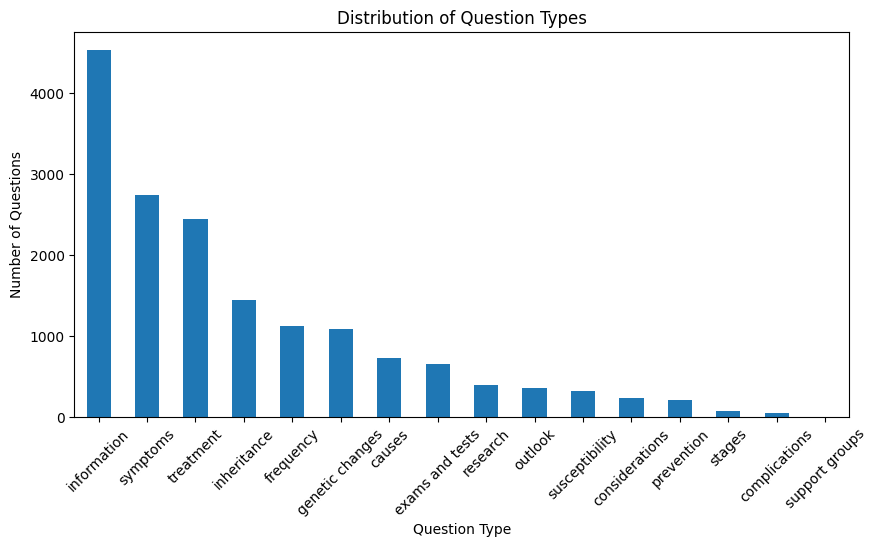

In [30]:
df["qtype"].value_counts().plot(kind="bar", figsize=(10,5))
plt.title("Distribution of Question Types")
plt.xlabel("Question Type")
plt.ylabel("Number of Questions")
plt.xticks(rotation=45)
plt.show()

In [32]:
df.isnull().sum()

qtype       0
Question    0
Answer      0
dtype: int64

In [34]:
print("Total duplicate questions:", df["Question"].duplicated().sum())

Total duplicate questions: 1428


In [40]:
df["question_length"] = df["Question"].str.len()
df["answer_length"] = df["Answer"].str.len()

In [38]:
df[["question_length", "answer_length"]].describe()

,question_length,answer_length
count,16407.000000,16407.000000
mean,50.684952,1303.452673
std,16.926465,1656.694326
min,16.000000,6.000000
25%,38.000000,487.000000
50%,48.000000,890.000000
75%,61.000000,1589.000000
max,191.000000,29046.000000


In [42]:
print("Average question length:", df["question_length"].mean())
print("Average answer length:", df["answer_length"].mean())

Average question length: 50.684951545072224
Average answer length: 1303.4526726397269


In [44]:
df[["qtype", "Question", "Answer"]].sample(10, random_state=42)

,qtype,Question,Answer
3634,treatment,What are the treatments for High Blood Pressure ?,"Today, many different types of medicines are a..."
15104,treatment,What are the treatments for 21-hydroxylase def...,What is the goal for treating 21-hydroxylase-d...
4395,exams and tests,How to diagnose Fanconi Anemia ?,People who have Fanconi anemia (FA) are born w...
10274,frequency,How many people are affected by glutaric acide...,Glutaric acidemia type I occurs in approximate...
149,treatment,how is hps diagnosed and treated for Hantavirus ?,Diagnosing HPS\n \nDiagnosing HPS in an indiv...
1624,symptoms,What are the symptoms of Microscopic Colitis: ...,The most common symptom of microscopic colitis...
7176,inheritance,Is surfactant dysfunction inherited ?,Surfactant dysfunction can have different inhe...
7261,inheritance,Is complement component 2 deficiency inherited ?,This condition is inherited in an autosomal re...
14711,symptoms,What are the symptoms of Charcot-Marie-Tooth d...,What are the signs and symptoms of Charcot-Mar...
6728,information,What is (are) 3MC syndrome ?,3MC syndrome is a disorder characterized by un...


In [46]:
qa_df = df[["qtype", "Question", "Answer"]].copy()

In [48]:
qa_df = qa_df.dropna(subset=["Question", "Answer"])

In [50]:
qa_df = qa_df.drop_duplicates(
    subset=["Question", "Answer"]
)

In [52]:
qa_df = qa_df.reset_index(drop=True)

In [54]:
print("Final dataset shape:", qa_df.shape)

Final dataset shape: (16359, 3)


In [56]:
qa_df = qa_df.rename(columns={
    "Question": "question",
    "Answer": "answer",
    "qtype": "question_type"
})

In [58]:
qa_df.head()

,question_type,question,answer
0,susceptibility,Who is at risk for Lymphocytic Choriomeningiti...,LCMV infections can occur after exposure to fr...
1,symptoms,What are the symptoms of Lymphocytic Choriomen...,LCMV is most commonly recognized as causing ne...
2,susceptibility,Who is at risk for Lymphocytic Choriomeningiti...,Individuals of all ages who come into contact ...
3,exams and tests,How to diagnose Lymphocytic Choriomeningitis (...,"During the first phase of the disease, the mos..."
4,treatment,What are the treatments for Lymphocytic Chorio...,"Aseptic meningitis, encephalitis, or meningoen..."


## 5. Text Preprocessing

The medical questions are preprocessed before information retrieval. The preprocessing pipeline converts text to lowercase, removes unnecessary characters, tokenizes the text, removes common stopwords, and applies lemmatization. This reduces textual variation and helps the retrieval system identify semantically similar questions.

In [60]:
import re
import nltk

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

In [62]:
nltk.download("punkt")
nltk.download("punkt_tab")
nltk.download("stopwords")
nltk.download("wordnet")

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Student\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\Student\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Student\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Student\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [64]:
stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    text = str(text).lower()
    
    text = re.sub(r"[^a-zA-Z0-9\s]", " ", text)
    
    tokens = word_tokenize(text)
    
    tokens = [
        lemmatizer.lemmatize(word)
        for word in tokens
        if word not in stop_words
    ]
    
    return " ".join(tokens)

In [66]:
sample_question = qa_df["question"].iloc[0]

print("Original:")
print(sample_question)

print("\nProcessed:")
print(preprocess_text(sample_question))

Original:
Who is at risk for Lymphocytic Choriomeningitis (LCM)? ?

Processed:
risk lymphocytic choriomeningitis lcm


In [68]:
qa_df["processed_question"] = qa_df["question"].apply(
    preprocess_text
)

In [70]:
qa_df[
    ["question", "processed_question"]
].head()

,question,processed_question
0,Who is at risk for Lymphocytic Choriomeningiti...,risk lymphocytic choriomeningitis lcm
1,What are the symptoms of Lymphocytic Choriomen...,symptom lymphocytic choriomeningitis lcm
2,Who is at risk for Lymphocytic Choriomeningiti...,risk lymphocytic choriomeningitis lcm
3,How to diagnose Lymphocytic Choriomeningitis (...,diagnose lymphocytic choriomeningitis lcm
4,What are the treatments for Lymphocytic Chorio...,treatment lymphocytic choriomeningitis lcm


## 6. Information Retrieval

The system uses TF-IDF vectorization to represent medical questions numerically. When a user enters a question, the same preprocessing is applied to the query. Cosine similarity is then calculated between the query vector and the vectors of the stored medical questions. The question with the highest similarity is retrieved and its corresponding answer is returned.

In [72]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

In [74]:
vectorizer = TfidfVectorizer(
    ngram_range=(1, 2),
    min_df=1
)

question_vectors = vectorizer.fit_transform(
    qa_df["processed_question"]
)

print("TF-IDF matrix shape:", question_vectors.shape)

TF-IDF matrix shape: (16359, 18398)


In [76]:
def retrieve_answers(user_question, top_k=3):
    
    processed_query = preprocess_text(user_question)
    
    query_vector = vectorizer.transform(
        [processed_query]
    )
    
    similarities = cosine_similarity(
        query_vector,
        question_vectors
    ).flatten()
    
    top_indices = similarities.argsort()[-top_k:][::-1]
    
    results = qa_df.iloc[top_indices].copy()
    
    results["similarity"] = similarities[top_indices]
    
    return results

In [78]:
results = retrieve_answers(
    "What are the symptoms of Lymphocytic Choriomeningitis?"
)

results[
    ["question_type", "question", "answer", "similarity"]
]

,question_type,question,answer,similarity
1,symptoms,What are the symptoms of Lymphocytic Choriomen...,LCMV is most commonly recognized as causing ne...,0.813000
4,treatment,What are the treatments for Lymphocytic Chorio...,"Aseptic meningitis, encephalitis, or meningoen...",0.552208
0,susceptibility,Who is at risk for Lymphocytic Choriomeningiti...,LCMV infections can occur after exposure to fr...,0.543091


In [80]:
results = retrieve_answers(
    "What are the symptoms of diabetes?"
)

results[
    ["question_type", "question", "answer", "similarity"]
]

,question_type,question,answer,similarity
3652,symptoms,What are the symptoms of Diabetes ?,"Diabetes is often called a ""silent"" disease be...",1.000000
3658,symptoms,What are the symptoms of Diabetes ?,Many people with diabetes experience one or mo...,1.000000
13785,symptoms,What are the symptoms of Diabetes mellitus typ...,What are the signs and symptoms of Diabetes me...,0.599897


## 6.1 Retrieval Dataset Preparation

Multiple records in the MedQuAD corpus may contain identical or highly similar questions. To avoid returning duplicate results during information retrieval, a separate retrieval dataset is created by removing duplicate questions while retaining the associated question type and answer.

In [82]:
retrieval_df = qa_df.drop_duplicates(
    subset=["question"]
).reset_index(drop=True)

print("Original records:", len(qa_df))
print("Retrieval records:", len(retrieval_df))

Original records: 16359
Retrieval records: 14979


In [84]:
vectorizer = TfidfVectorizer(
    ngram_range=(1, 2),
    min_df=1
)

question_vectors = vectorizer.fit_transform(
    retrieval_df["processed_question"]
)

print("TF-IDF matrix shape:", question_vectors.shape)

TF-IDF matrix shape: (14979, 18398)


In [86]:
def retrieve_answers(user_question, top_k=3):
    
    processed_query = preprocess_text(user_question)
    
    query_vector = vectorizer.transform(
        [processed_query]
    )
    
    similarities = cosine_similarity(
        query_vector,
        question_vectors
    ).flatten()
    
    top_indices = similarities.argsort()[-top_k:][::-1]
    
    results = retrieval_df.iloc[top_indices].copy()
    
    results["similarity"] = similarities[top_indices]
    
    return results

In [88]:
results = retrieve_answers(
    "What are the symptoms of diabetes?"
)

results[
    ["question_type", "question", "answer", "similarity"]
]

,question_type,question,answer,similarity
2993,symptoms,What are the symptoms of Diabetes ?,"Diabetes is often called a ""silent"" disease be...",1.000000
12563,symptoms,What are the symptoms of Diabetes mellitus typ...,What are the signs and symptoms of Diabetes me...,0.609202
2990,information,What is (are) Diabetes ?,Too Much Glucose in the Blood Diabetes means y...,0.504225


In [90]:
def get_best_answer(user_question, threshold=0.20):
    
    results = retrieve_answers(
        user_question,
        top_k=1
    )
    
    best_result = results.iloc[0]
    
    similarity = best_result["similarity"]
    
    if similarity < threshold:
        return {
            "answer": "I'm sorry, I could not find a reliable answer in the healthcare knowledge base.",
            "similarity": similarity,
            "question_type": "unknown"
        }
    
    return {
        "answer": best_result["answer"],
        "similarity": similarity,
        "question_type": best_result["question_type"]
    }

In [92]:
result = get_best_answer(
    "What are the symptoms of diabetes?"
)

print("Answer:")
print(result["answer"])

print("\nSimilarity:", result["similarity"])
print("Question Type:", result["question_type"])

Answer:
Diabetes is often called a "silent" disease because it can cause serious complications even before you have symptoms. Symptoms can also be so mild that you dont notice them. An estimated 8 million people in the United States have type 2 diabetes and dont know it, according to 2012 estimates by the Centers for Disease Control and Prevention (CDC). Common Signs Some common symptoms of diabetes are: - being very thirsty  - frequent urination  - feeling very hungry or tired  - losing weight without trying  - having sores that heal slowly  - having dry, itchy skin  - loss of feeling or tingling in the feet  - having blurry eyesight. being very thirsty frequent urination feeling very hungry or tired losing weight without trying having sores that heal slowly having dry, itchy skin loss of feeling or tingling in the feet having blurry eyesight. Signs of type 1 diabetes usually develop over a short period of time. The signs for type 2 diabetes develop more gradually. Tests for Diabetes 

In [94]:
from nltk.tokenize import sent_tokenize

In [96]:
def extract_factoid_answer(question, answer, max_sentences=2):
    
    sentences = sent_tokenize(answer)
    
    if len(sentences) <= max_sentences:
        return answer
    
    question_processed = preprocess_text(question)
    sentence_processed = [
        preprocess_text(sentence)
        for sentence in sentences
    ]
    
    fact_vectorizer = TfidfVectorizer()
    
    combined_text = [
        question_processed
    ] + sentence_processed
    
    vectors = fact_vectorizer.fit_transform(combined_text)
    
    question_vector = vectors[0]
    sentence_vectors = vectors[1:]
    
    similarities = cosine_similarity(
        question_vector,
        sentence_vectors
    ).flatten()
    
    top_indices = similarities.argsort()[
        -max_sentences:
    ][::-1]
    
    top_indices = sorted(top_indices)
    
    selected_sentences = [
        sentences[i]
        for i in top_indices
    ]
    
    return " ".join(selected_sentences)

In [98]:
result = get_best_answer(
    "What are the symptoms of diabetes?"
)

factoid = extract_factoid_answer(
    "What are the symptoms of diabetes?",
    result["answer"]
)

print(factoid)

This test, along with an assessment of symptoms, is used to diagnose diabetes but not prediabetes. Sometimes people have symptoms but do not suspect diabetes.


In [100]:
def answer_question(user_question, threshold=0.20):
    
    result = get_best_answer(
        user_question,
        threshold
    )
    
    if result["question_type"] == "unknown":
        return result
    
    factoid_answer = extract_factoid_answer(
        user_question,
        result["answer"]
    )
    
    return {
        "answer": factoid_answer,
        "similarity": result["similarity"],
        "question_type": result["question_type"]
    }

In [102]:
result = answer_question(
    "What are the symptoms of diabetes?"
)

print("Answer:")
print(result["answer"])

print("\nSimilarity:", result["similarity"])
print("Question Type:", result["question_type"])

Answer:
This test, along with an assessment of symptoms, is used to diagnose diabetes but not prediabetes. Sometimes people have symptoms but do not suspect diabetes.

Similarity: 1.0000000000000002
Question Type: symptoms


In [104]:
test_questions = [
    "What are the symptoms of diabetes?",
    "Who is at risk for malaria?",
    "What are the treatments for asthma?",
    "How is tuberculosis diagnosed?",
    "What causes dengue?"
]

for question in test_questions:
    
    result = answer_question(question)
    
    print("=" * 80)
    print("QUESTION:", question)
    print("TYPE:", result["question_type"])
    print("SIMILARITY:", round(result["similarity"], 3))
    print("ANSWER:", result["answer"])

QUESTION: What are the symptoms of diabetes?
TYPE: symptoms
SIMILARITY: 1.0
ANSWER: This test, along with an assessment of symptoms, is used to diagnose diabetes but not prediabetes. Sometimes people have symptoms but do not suspect diabetes.
QUESTION: Who is at risk for malaria?
TYPE: information
SIMILARITY: 0.882
ANSWER: If you travel to these countries, you are at risk. Malaria can be prevented.
QUESTION: What are the treatments for asthma?
TYPE: treatment
SIMILARITY: 1.0
ANSWER: The goal of asthma treatment is to control the disease. Asthma Treatment for Special Groups
                
The treatments described above generally apply to all people who have asthma.
QUESTION: How is tuberculosis diagnosed?
TYPE: information
SIMILARITY: 0.701
ANSWER: Tuberculosis (TB) is a disease caused by bacteria called Mycobacterium tuberculosis. NIH: National Institute of Allergy and Infectious Diseases
QUESTION: What causes dengue?
TYPE: information
SIMILARITY: 0.918
ANSWER: In some cases, dengue 

In [106]:
qa_df["question_type"].value_counts()

question_type
information        4520
symptoms           2747
treatment          2440
inheritance        1446
frequency          1120
genetic changes    1087
causes              708
exams and tests     650
research            395
outlook             361
susceptibility      324
considerations      228
prevention          209
stages               77
complications        46
support groups        1
Name: count, dtype: int64

In [108]:
qa_df["question_type"].unique()

array(['susceptibility', 'symptoms', 'exams and tests', 'treatment',
       'prevention', 'information', 'frequency', 'complications',
       'causes', 'research', 'outlook', 'considerations', 'inheritance',
       'stages', 'genetic changes', 'support groups'], dtype=object)

In [110]:
qa_df["question_type"].value_counts()

question_type
information        4520
symptoms           2747
treatment          2440
inheritance        1446
frequency          1120
genetic changes    1087
causes              708
exams and tests     650
research            395
outlook             361
susceptibility      324
considerations      228
prevention          209
stages               77
complications        46
support groups        1
Name: count, dtype: int64

In [112]:
qa_df["question_type"].unique()

array(['susceptibility', 'symptoms', 'exams and tests', 'treatment',
       'prevention', 'information', 'frequency', 'complications',
       'causes', 'research', 'outlook', 'considerations', 'inheritance',
       'stages', 'genetic changes', 'support groups'], dtype=object)

## 6.2 Question Type / Intent Detection

The MedQuAD corpus contains multiple types of medical questions. To improve retrieval accuracy, the system first identifies the likely question type from the user's wording. The detected type is then used to restrict information retrieval to relevant question-answer pairs.

For example, questions containing terms such as "symptoms" are mapped to the `symptoms` category, questions containing "treatment" are mapped to `treatment`, and questions asking how a disease is diagnosed are mapped to `exams and tests`.

In [114]:
def detect_question_type(question):
    
    q = question.lower().strip()
    
    # Symptoms
    if any(word in q for word in [
        "symptom", "signs", "sign of", "feel", "feeling"
    ]):
        return "symptoms"
    
    # Treatment
    if any(word in q for word in [
        "treatment", "treat", "therapy", "therapies",
        "medication", "medicine", "cure", "manage"
    ]):
        return "treatment"
    
    # Diagnosis / Tests
    if any(phrase in q for phrase in [
        "diagnose", "diagnosed", "diagnosis",
        "test", "tests", "testing",
        "examination", "exam", "detect"
    ]):
        return "exams and tests"
    
    # Causes
    if any(phrase in q for phrase in [
        "cause", "causes", "caused by",
        "why does", "why do", "reason"
    ]):
        return "causes"
    
    # Susceptibility / Risk
    if any(phrase in q for phrase in [
        "risk", "at risk", "susceptible",
        "who gets", "who is likely"
    ]):
        return "susceptibility"
    
    # Prevention
    if any(phrase in q for phrase in [
        "prevent", "prevention",
        "avoid", "reduce the risk"
    ]):
        return "prevention"
    
    # Inheritance
    if any(phrase in q for phrase in [
        "inherit", "inherited",
        "hereditary", "genetic",
        "passed down", "family"
    ]):
        return "inheritance"
    
    # Frequency
    if any(phrase in q for phrase in [
        "how common", "how often",
        "common", "frequency", "prevalence"
    ]):
        return "frequency"
    
    # Stages
    if any(phrase in q for phrase in [
        "stage", "stages", "stage of"
    ]):
        return "stages"
    
    # Complications
    if any(phrase in q for phrase in [
        "complication", "complications",
        "problems caused by"
    ]):
        return "complications"
    
    # Outlook
    if any(phrase in q for phrase in [
        "outlook", "prognosis",
        "future", "survival", "life expectancy"
    ]):
        return "outlook"
    
    # Research
    if any(phrase in q for phrase in [
        "research", "clinical trial",
        "studies", "study", "researchers"
    ]):
        return "research"
    
    # Support
    if any(phrase in q for phrase in [
        "support group", "support groups",
        "support"
    ]):
        return "support groups"
    
    # General information
    return "information"

In [116]:
test_intents = [
    "What are the symptoms of diabetes?",
    "What are the treatments for asthma?",
    "How is tuberculosis diagnosed?",
    "What causes dengue?",
    "Who is at risk for malaria?",
    "How can diabetes be prevented?",
    "Is diabetes hereditary?",
    "How common is asthma?",
    "What are the stages of cancer?",
    "What are the complications of diabetes?",
    "What is the outlook for patients with cancer?",
    "What is being researched about Alzheimer's disease?",
    "What is diabetes?"
]

for question in test_intents:
    print(
        question,
        "→",
        detect_question_type(question)
    )

What are the symptoms of diabetes? → symptoms
What are the treatments for asthma? → treatment
How is tuberculosis diagnosed? → exams and tests
What causes dengue? → causes
Who is at risk for malaria? → susceptibility
How can diabetes be prevented? → prevention
Is diabetes hereditary? → inheritance
How common is asthma? → frequency
What are the stages of cancer? → stages
What are the complications of diabetes? → complications
What is the outlook for patients with cancer? → outlook
What is being researched about Alzheimer's disease? → research
What is diabetes? → information


In [118]:
def retrieve_answers(user_question, top_k=3):
    
    processed_query = preprocess_text(user_question)
    
    # Detect the expected question type
    detected_type = detect_question_type(user_question)
    
    # Filter dataset by question type
    filtered_df = retrieval_df[
        retrieval_df["question_type"] == detected_type
    ].copy()
    
    # If no records are available, search the complete dataset
    if len(filtered_df) == 0:
        filtered_df = retrieval_df.copy()
    
    # Create TF-IDF representation for filtered questions
    temp_vectorizer = TfidfVectorizer(
        ngram_range=(1, 2),
        min_df=1
    )
    
    temp_vectors = temp_vectorizer.fit_transform(
        filtered_df["processed_question"]
    )
    
    query_vector = temp_vectorizer.transform(
        [processed_query]
    )
    
    similarities = cosine_similarity(
        query_vector,
        temp_vectors
    ).flatten()
    
    top_indices = similarities.argsort()[-top_k:][::-1]
    
    results = filtered_df.iloc[top_indices].copy()
    
    results["similarity"] = similarities[top_indices]
    
    return results

In [120]:
results = retrieve_answers(
    "What are the symptoms of diabetes?"
)

results[
    ["question_type", "question", "answer", "similarity"]
]

,question_type,question,answer,similarity
2993,symptoms,What are the symptoms of Diabetes ?,"Diabetes is often called a ""silent"" disease be...",1.000000
12563,symptoms,What are the symptoms of Diabetes mellitus typ...,What are the signs and symptoms of Diabetes me...,0.584987
14830,symptoms,What are the symptoms of Diabetes insipidus ne...,What are the signs and symptoms of Diabetes in...,0.348264


In [122]:
test_questions = [
    "What are the symptoms of diabetes?",
    "Who is at risk for malaria?",
    "What are the treatments for asthma?",
    "How is tuberculosis diagnosed?",
    "What causes dengue?"
]

for question in test_questions:
    
    detected_type = detect_question_type(question)
    results = retrieve_answers(question, top_k=1)
    
    best = results.iloc[0]
    
    print("=" * 80)
    print("QUESTION:", question)
    print("DETECTED TYPE:", detected_type)
    print("RETRIEVED TYPE:", best["question_type"])
    print("SIMILARITY:", round(best["similarity"], 3))
    print("RETRIEVED QUESTION:", best["question"])
    print("ANSWER:", best["answer"])

QUESTION: What are the symptoms of diabetes?
DETECTED TYPE: symptoms
RETRIEVED TYPE: symptoms
SIMILARITY: 1.0
RETRIEVED QUESTION: What are the symptoms of Diabetes ?
ANSWER: Diabetes is often called a "silent" disease because it can cause serious complications even before you have symptoms. Symptoms can also be so mild that you dont notice them. An estimated 8 million people in the United States have type 2 diabetes and dont know it, according to 2012 estimates by the Centers for Disease Control and Prevention (CDC). Common Signs Some common symptoms of diabetes are: - being very thirsty  - frequent urination  - feeling very hungry or tired  - losing weight without trying  - having sores that heal slowly  - having dry, itchy skin  - loss of feeling or tingling in the feet  - having blurry eyesight. being very thirsty frequent urination feeling very hungry or tired losing weight without trying having sores that heal slowly having dry, itchy skin loss of feeling or tingling in the feet h

In [124]:
def answer_question(user_question, threshold=0.20):
    
    results = retrieve_answers(
        user_question,
        top_k=1
    )
    
    best_result = results.iloc[0]
    
    similarity = best_result["similarity"]
    
    if similarity < threshold:
        return {
            "answer": "I'm sorry, I could not find a reliable answer in the healthcare knowledge base.",
            "similarity": similarity,
            "question_type": "unknown"
        }
    
    return {
        "answer": best_result["answer"],
        "similarity": similarity,
        "question_type": best_result["question_type"]
    }

In [126]:
test_questions = [
    "What are the symptoms of diabetes?",
    "Who is at risk for malaria?",
    "What are the treatments for asthma?",
    "How is tuberculosis diagnosed?",
    "What causes dengue?"
]

for question in test_questions:
    
    detected_type = detect_question_type(question)
    results = retrieve_answers(question, top_k=1)
    
    best = results.iloc[0]
    
    print("=" * 80)
    print("QUESTION:", question)
    print("DETECTED TYPE:", detected_type)
    print("RETRIEVED TYPE:", best["question_type"])
    print("SIMILARITY:", round(best["similarity"], 3))
    print("RETRIEVED QUESTION:", best["question"])
    print("ANSWER:", best["answer"])

QUESTION: What are the symptoms of diabetes?
DETECTED TYPE: symptoms
RETRIEVED TYPE: symptoms
SIMILARITY: 1.0
RETRIEVED QUESTION: What are the symptoms of Diabetes ?
ANSWER: Diabetes is often called a "silent" disease because it can cause serious complications even before you have symptoms. Symptoms can also be so mild that you dont notice them. An estimated 8 million people in the United States have type 2 diabetes and dont know it, according to 2012 estimates by the Centers for Disease Control and Prevention (CDC). Common Signs Some common symptoms of diabetes are: - being very thirsty  - frequent urination  - feeling very hungry or tired  - losing weight without trying  - having sores that heal slowly  - having dry, itchy skin  - loss of feeling or tingling in the feet  - having blurry eyesight. being very thirsty frequent urination feeling very hungry or tired losing weight without trying having sores that heal slowly having dry, itchy skin loss of feeling or tingling in the feet h

## 6.3 Medical Entity Detection

In addition to identifying the question type, the system identifies the main disease or medical condition mentioned in the user's question. This prevents the retrieval system from returning information about a different disease when multiple questions have similar wording.

In [128]:
disease_aliases = {
    "diabetes": ["diabetes", "diabetes mellitus", "type 1 diabetes", "type 2 diabetes"],
    "asthma": ["asthma"],
    "malaria": ["malaria"],
    "dengue": ["dengue"],
    "tuberculosis": ["tuberculosis", "tb"],
    "pneumonia": ["pneumonia"],
    "hypertension": ["hypertension", "high blood pressure"],
    "influenza": ["influenza", "flu"],
    "migraine": ["migraine"],
    "measles": ["measles"],
    "chickenpox": ["chickenpox"],
    "hepatitis": ["hepatitis"],
    "arthritis": ["arthritis"],
    "alzheimer": ["alzheimer", "alzheimer's disease"],
    "parkinson": ["parkinson", "parkinson's disease"],
    "cancer": ["cancer"],
    "leukemia": ["leukemia"],
    "lymphoma": ["lymphoma"],
    "anemia": ["anemia"],
    "epilepsy": ["epilepsy"]
}

In [130]:
def detect_disease(question):
    
    q = question.lower()
    
    # Check longer aliases first
    all_aliases = []
    
    for disease, aliases in disease_aliases.items():
        for alias in aliases:
            all_aliases.append((alias, disease))
    
    all_aliases.sort(
        key=lambda x: len(x[0]),
        reverse=True
    )
    
    for alias, disease in all_aliases:
        if alias in q:
            return disease
    
    return None

In [132]:
test_disease_questions = [
    "What are the symptoms of diabetes?",
    "Who is at risk for malaria?",
    "What are the treatments for asthma?",
    "How is tuberculosis diagnosed?",
    "What causes dengue?"
]

for question in test_disease_questions:
    print(
        question,
        "→",
        detect_disease(question)
    )

What are the symptoms of diabetes? → diabetes
Who is at risk for malaria? → malaria
What are the treatments for asthma? → asthma
How is tuberculosis diagnosed? → tuberculosis
What causes dengue? → dengue


In [134]:
def retrieve_answers(user_question, top_k=3):
    
    processed_query = preprocess_text(user_question)
    
    detected_type = detect_question_type(user_question)
    detected_disease = detect_disease(user_question)
    
    # First filter by question type
    filtered_df = retrieval_df[
        retrieval_df["question_type"] == detected_type
    ].copy()
    
    # If a disease was detected, keep records
    # containing that disease in the question or answer
    if detected_disease is not None:
        
        disease_pattern = "|".join(
            disease_aliases[detected_disease]
        )
        
        disease_mask = (
            filtered_df["question"].str.lower().str.contains(
                disease_pattern,
                regex=True,
                na=False
            )
            |
            filtered_df["answer"].str.lower().str.contains(
                disease_pattern,
                regex=True,
                na=False
            )
        )
        
        disease_filtered = filtered_df[disease_mask].copy()
        
        # Only use disease filtering if matches exist
        if len(disease_filtered) > 0:
            filtered_df = disease_filtered
    
    # If nothing remains, fall back to the question-type dataset
    if len(filtered_df) == 0:
        filtered_df = retrieval_df[
            retrieval_df["question_type"] == detected_type
        ].copy()
    
    # If still empty, use complete dataset
    if len(filtered_df) == 0:
        filtered_df = retrieval_df.copy()
    
    # TF-IDF on the filtered records
    temp_vectorizer = TfidfVectorizer(
        ngram_range=(1, 2),
        min_df=1
    )
    
    temp_vectors = temp_vectorizer.fit_transform(
        filtered_df["processed_question"]
    )
    
    query_vector = temp_vectorizer.transform(
        [processed_query]
    )
    
    similarities = cosine_similarity(
        query_vector,
        temp_vectors
    ).flatten()
    
    top_indices = similarities.argsort()[-top_k:][::-1]
    
    results = filtered_df.iloc[top_indices].copy()
    results["similarity"] = similarities[top_indices]
    
    return results

In [136]:
test_questions = [
    "What are the symptoms of diabetes?",
    "Who is at risk for malaria?",
    "What are the treatments for asthma?",
    "How is tuberculosis diagnosed?",
    "What causes dengue?"
]

for question in test_questions:
    
    detected_type = detect_question_type(question)
    detected_disease = detect_disease(question)
    
    results = retrieve_answers(
        question,
        top_k=1
    )
    
    best = results.iloc[0]
    
    print("=" * 80)
    print("QUESTION:", question)
    print("DETECTED TYPE:", detected_type)
    print("DETECTED DISEASE:", detected_disease)
    print("RETRIEVED TYPE:", best["question_type"])
    print("SIMILARITY:", round(best["similarity"], 3))
    print("RETRIEVED QUESTION:", best["question"])
    print("ANSWER:", best["answer"][:500])

QUESTION: What are the symptoms of diabetes?
DETECTED TYPE: symptoms
DETECTED DISEASE: diabetes
RETRIEVED TYPE: symptoms
SIMILARITY: 1.0
RETRIEVED QUESTION: What are the symptoms of Diabetes ?
ANSWER: Diabetes is often called a "silent" disease because it can cause serious complications even before you have symptoms. Symptoms can also be so mild that you dont notice them. An estimated 8 million people in the United States have type 2 diabetes and dont know it, according to 2012 estimates by the Centers for Disease Control and Prevention (CDC). Common Signs Some common symptoms of diabetes are: - being very thirsty  - frequent urination  - feeling very hungry or tired  - losing weight without 
QUESTION: Who is at risk for malaria?
DETECTED TYPE: susceptibility
DETECTED DISEASE: malaria
RETRIEVED TYPE: susceptibility
SIMILARITY: 1.0
RETRIEVED QUESTION: Who is at risk for ? ?
ANSWER: Measles: Make Sure Your Child Is Protected with MMR Vaccine Measles starts with a fever. Soon after, it ca

In [138]:
def answer_question(user_question, threshold=0.25):
    
    results = retrieve_answers(
        user_question,
        top_k=1
    )
    
    best_result = results.iloc[0]
    
    similarity = best_result["similarity"]
    
    if similarity < threshold:
        return {
            "answer": "I'm sorry, I could not find a reliable answer for that question in the healthcare knowledge base.",
            "similarity": similarity,
            "question_type": "unknown"
        }
    
    return {
        "answer": best_result["answer"],
        "similarity": similarity,
        "question_type": best_result["question_type"]
    }

In [140]:
questions = [
    "What are the symptoms of diabetes?",
    "How is tuberculosis diagnosed?",
    "What are the treatments for asthma?",
    "Who is at risk for malaria?",
    "What causes dengue?",
    "Who won the FIFA World Cup?"
]

for question in questions:
    
    result = answer_question(question)
    
    print("=" * 70)
    print("QUESTION:", question)
    print("TYPE:", result["question_type"])
    print("SIMILARITY:", round(result["similarity"], 3))
    print("ANSWER:", result["answer"][:300])

QUESTION: What are the symptoms of diabetes?
TYPE: symptoms
SIMILARITY: 1.0
ANSWER: Diabetes is often called a "silent" disease because it can cause serious complications even before you have symptoms. Symptoms can also be so mild that you dont notice them. An estimated 8 million people in the United States have type 2 diabetes and dont know it, according to 2012 estimates by the C
QUESTION: How is tuberculosis diagnosed?
TYPE: exams and tests
SIMILARITY: 0.496
ANSWER: Tuberculosis (TB) is a disease that is spread through the air from one person to another. There are two kinds of tests that are used to determine if a person has been infected with TB bacteria: the tuberculin skin test and TB blood tests. 
  
A positive TB skin test or TB blood test only tells that 
QUESTION: What are the treatments for asthma?
TYPE: treatment
SIMILARITY: 1.0
ANSWER: Asthma is a long-term disease that has no cure. The goal of asthma treatment is to control the disease. Good asthma control will:
         

In [142]:
def retrieve_answers(user_question, top_k=3):

    processed_query = preprocess_text(user_question)

    detected_type = detect_question_type(user_question)
    detected_disease = detect_disease(user_question)

    # First filter by question type
    filtered_df = retrieval_df[
        retrieval_df["question_type"] == detected_type
    ].copy()

    # If a disease is explicitly mentioned,
    # require the retrieved record to contain that disease
    if detected_disease is not None:

        disease_pattern = "|".join(
            re.escape(alias)
            for alias in disease_aliases[detected_disease]
        )

        disease_mask = (
            filtered_df["question"].str.lower().str.contains(
                disease_pattern,
                regex=True,
                na=False
            )
            |
            filtered_df["answer"].str.lower().str.contains(
                disease_pattern,
                regex=True,
                na=False
            )
        )

        disease_filtered = filtered_df[disease_mask].copy()

        # IMPORTANT:
        # If a disease was explicitly mentioned but
        # no matching records exist, return no results.
        if len(disease_filtered) == 0:
            return pd.DataFrame()

        filtered_df = disease_filtered

    # TF-IDF retrieval
    temp_vectorizer = TfidfVectorizer(
        ngram_range=(1, 2),
        min_df=1
    )

    temp_vectors = temp_vectorizer.fit_transform(
        filtered_df["processed_question"]
    )

    query_vector = temp_vectorizer.transform(
        [processed_query]
    )

    similarities = cosine_similarity(
        query_vector,
        temp_vectors
    ).flatten()

    top_indices = similarities.argsort()[-top_k:][::-1]

    results = filtered_df.iloc[top_indices].copy()

    results["similarity"] = similarities[top_indices]

    return results

In [144]:
def answer_question(user_question, threshold=0.25):

    results = retrieve_answers(
        user_question,
        top_k=1
    )

    # No reliable matching record
    if results.empty:
        return {
            "answer": "I'm sorry, I could not find a reliable answer for that question in the healthcare knowledge base.",
            "similarity": 0.0,
            "question_type": "unknown"
        }

    best_result = results.iloc[0]

    similarity = best_result["similarity"]

    if similarity < threshold:
        return {
            "answer": "I'm sorry, I could not find a reliable answer for that question in the healthcare knowledge base.",
            "similarity": similarity,
            "question_type": "unknown"
        }

    return {
        "answer": best_result["answer"],
        "similarity": similarity,
        "question_type": best_result["question_type"]
    }

In [146]:
result = answer_question(
    "Who is at risk for malaria?"
)

print("TYPE:", result["question_type"])
print("SIMILARITY:", result["similarity"])
print("ANSWER:", result["answer"])

TYPE: unknown
SIMILARITY: 0.0
ANSWER: I'm sorry, I could not find a reliable answer for that question in the healthcare knowledge base.


In [148]:
questions = [
    "What are the symptoms of diabetes?",
    "How is tuberculosis diagnosed?",
    "What are the treatments for asthma?",
    "Who is at risk for malaria?",
    "What causes dengue?",
    "Who won the FIFA World Cup?"
]

for question in questions:

    result = answer_question(question)

    print("=" * 70)
    print("QUESTION:", question)
    print("TYPE:", result["question_type"])
    print("SIMILARITY:", round(result["similarity"], 3))
    print("ANSWER:", result["answer"][:300])

QUESTION: What are the symptoms of diabetes?
TYPE: symptoms
SIMILARITY: 1.0
ANSWER: Diabetes is often called a "silent" disease because it can cause serious complications even before you have symptoms. Symptoms can also be so mild that you dont notice them. An estimated 8 million people in the United States have type 2 diabetes and dont know it, according to 2012 estimates by the C
QUESTION: How is tuberculosis diagnosed?
TYPE: exams and tests
SIMILARITY: 0.496
ANSWER: Tuberculosis (TB) is a disease that is spread through the air from one person to another. There are two kinds of tests that are used to determine if a person has been infected with TB bacteria: the tuberculin skin test and TB blood tests. 
  
A positive TB skin test or TB blood test only tells that 
QUESTION: What are the treatments for asthma?
TYPE: treatment
SIMILARITY: 1.0
ANSWER: Asthma is a long-term disease that has no cure. The goal of asthma treatment is to control the disease. Good asthma control will:
         

## 7. Structured Healthcare Knowledge Base

A structured healthcare knowledge base is created using a Pandas DataFrame. It stores disease-related information in structured fields such as symptoms, causes, risk factors, prevention, and treatment. This source complements the unstructured medical QA corpus and allows the chatbot to answer queries using direct field-based lookup.

In [150]:
knowledge_base = pd.DataFrame({
    
    "disease": [
        "diabetes",
        "malaria",
        "dengue",
        "asthma",
        "tuberculosis",
        "hypertension",
        "pneumonia"
    ],
    
    "symptoms": [
        "increased thirst, frequent urination, hunger, fatigue, unexplained weight loss, slow-healing sores, blurred vision",
        "fever, chills, sweating, headache, nausea, vomiting, muscle pain",
        "high fever, severe headache, muscle and joint pain, nausea, vomiting, rash",
        "wheezing, coughing, shortness of breath, chest tightness",
        "persistent cough, chest pain, fever, night sweats, weight loss, weakness",
        "headache, dizziness, blurred vision, and sometimes no noticeable symptoms",
        "cough, fever, chills, chest pain, difficulty breathing, fatigue"
    ],
    
    "causes": [
        "problems with insulin production or insulin action",
        "infection with Plasmodium parasites transmitted through infected mosquitoes",
        "infection with dengue virus transmitted through infected mosquitoes",
        "airway inflammation and sensitivity to various triggers",
        "infection with Mycobacterium tuberculosis bacteria",
        "multiple genetic, environmental, and lifestyle factors",
        "infection caused by bacteria, viruses, or fungi"
    ],
    
    "risk_factors": [
        "family history, overweight, physical inactivity, and increasing age",
        "travel or residence in areas where malaria transmission occurs",
        "living in or traveling to areas where dengue occurs and exposure to infected mosquitoes",
        "allergies, family history, air pollution, tobacco smoke, and respiratory infections",
        "close contact with infected individuals and weakened immune system",
        "age, family history, obesity, high salt intake, and physical inactivity",
        "older age, weakened immune system, and certain chronic diseases"
    ],
    
    "prevention": [
        "healthy eating, regular physical activity, maintaining a healthy weight, and regular medical checkups",
        "prevent mosquito bites, use insect repellent, and use mosquito nets in risk areas",
        "prevent mosquito bites, remove standing water, and use insect repellent",
        "avoid known triggers, reduce exposure to smoke and pollutants, and follow an asthma action plan",
        "early detection, appropriate treatment, good ventilation, and reducing exposure to infected individuals",
        "healthy diet, regular physical activity, healthy weight, limiting salt, and avoiding tobacco",
        "vaccination when available, hand hygiene, avoiding sick contacts, and maintaining general health"
    ],
    
    "treatment": [
        "lifestyle management, blood glucose monitoring, and medicines or insulin as prescribed by a healthcare professional",
        "antimalarial medicines prescribed according to the type of malaria and medical guidance",
        "supportive care such as fluids and medical monitoring; severe cases require medical attention",
        "long-term control medicines and quick-relief medicines as prescribed by a healthcare professional",
        "a combination of antibiotics taken for the prescribed duration under medical supervision",
        "lifestyle changes and medicines prescribed by a healthcare professional",
        "treatment depends on the cause and may include medicines and supportive care"
    ]
})

knowledge_base

,disease,symptoms,causes,risk_factors,prevention,treatment
0,diabetes,"increased thirst, frequent urination, hunger, ...",problems with insulin production or insulin ac...,"family history, overweight, physical inactivit...","healthy eating, regular physical activity, mai...","lifestyle management, blood glucose monitoring..."
1,malaria,"fever, chills, sweating, headache, nausea, vom...",infection with Plasmodium parasites transmitte...,travel or residence in areas where malaria tra...,"prevent mosquito bites, use insect repellent, ...",antimalarial medicines prescribed according to...
2,dengue,"high fever, severe headache, muscle and joint ...",infection with dengue virus transmitted throug...,living in or traveling to areas where dengue o...,"prevent mosquito bites, remove standing water,...",supportive care such as fluids and medical mon...
3,asthma,"wheezing, coughing, shortness of breath, chest...",airway inflammation and sensitivity to various...,"allergies, family history, air pollution, toba...","avoid known triggers, reduce exposure to smoke...",long-term control medicines and quick-relief m...
4,tuberculosis,"persistent cough, chest pain, fever, night swe...",infection with Mycobacterium tuberculosis bact...,close contact with infected individuals and we...,"early detection, appropriate treatment, good v...",a combination of antibiotics taken for the pre...
5,hypertension,"headache, dizziness, blurred vision, and somet...","multiple genetic, environmental, and lifestyle...","age, family history, obesity, high salt intake...","healthy diet, regular physical activity, healt...",lifestyle changes and medicines prescribed by ...
6,pneumonia,"cough, fever, chills, chest pain, difficulty b...","infection caused by bacteria, viruses, or fungi","older age, weakened immune system, and certain...","vaccination when available, hand hygiene, avoi...",treatment depends on the cause and may include...


In [152]:
knowledge_base.to_csv(
    "healthcare_knowledge.csv",
    index=False
)

print("Knowledge base saved successfully.")

Knowledge base saved successfully.


In [154]:
def knowledge_query(disease, field):
    
    disease = disease.lower().strip()
    
    result = knowledge_base[
        knowledge_base["disease"].str.lower() == disease
    ]
    
    if result.empty:
        return None
    
    return result.iloc[0][field]

In [156]:
print(
    knowledge_query(
        "malaria",
        "symptoms"
    )
)

fever, chills, sweating, headache, nausea, vomiting, muscle pain


In [158]:
print(
    knowledge_query(
        "malaria",
        "risk_factors"
    )
)

travel or residence in areas where malaria transmission occurs


In [160]:
print(
    knowledge_query(
        "dengue",
        "causes"
    )
)

infection with dengue virus transmitted through infected mosquitoes


In [162]:
def detect_knowledge_field(question):
    
    q = question.lower()
    
    if any(word in q for word in [
        "symptom", "symptoms", "signs"
    ]):
        return "symptoms"
    
    if any(word in q for word in [
        "cause", "causes", "caused by"
    ]):
        return "causes"
    
    if any(word in q for word in [
        "risk", "at risk", "susceptible"
    ]):
        return "risk_factors"
    
    if any(word in q for word in [
        "prevent", "prevention", "avoid"
    ]):
        return "prevention"
    
    if any(word in q for word in [
        "treatment", "treat", "therapy", "medicine"
    ]):
        return "treatment"
    
    return None

In [164]:
def knowledge_answer(question):
    
    disease = detect_disease(question)
    field = detect_knowledge_field(question)
    
    if disease is None or field is None:
        return None
    
    answer = knowledge_query(
        disease,
        field
    )
    
    if answer is None:
        return None
    
    return answer

In [166]:
test_kb_questions = [
    "What are the symptoms of malaria?",
    "Who is at risk for malaria?",
    "What causes dengue?",
    "How can dengue be prevented?",
    "What are the treatments for asthma?"
]

for question in test_kb_questions:
    
    print("=" * 70)
    print("QUESTION:", question)
    print("DISEASE:", detect_disease(question))
    print("FIELD:", detect_knowledge_field(question))
    print("ANSWER:", knowledge_answer(question))

QUESTION: What are the symptoms of malaria?
DISEASE: malaria
FIELD: symptoms
ANSWER: fever, chills, sweating, headache, nausea, vomiting, muscle pain
QUESTION: Who is at risk for malaria?
DISEASE: malaria
FIELD: risk_factors
ANSWER: travel or residence in areas where malaria transmission occurs
QUESTION: What causes dengue?
DISEASE: dengue
FIELD: causes
ANSWER: infection with dengue virus transmitted through infected mosquitoes
QUESTION: How can dengue be prevented?
DISEASE: dengue
FIELD: prevention
ANSWER: prevent mosquito bites, remove standing water, and use insect repellent
QUESTION: What are the treatments for asthma?
DISEASE: asthma
FIELD: treatment
ANSWER: long-term control medicines and quick-relief medicines as prescribed by a healthcare professional


## 8. Multi-Source Question Answering

The chatbot combines two information sources. The first source is the MedQuAD medical question-answer corpus, which is used for information retrieval using TF-IDF and cosine similarity. The second source is a structured healthcare knowledge base containing disease-specific information.

The system first attempts to retrieve a reliable answer from the medical QA corpus. If a reliable answer cannot be obtained, the system queries the structured knowledge base. This allows the chatbot to provide answers from multiple information sources while avoiding unreliable low-confidence responses.

In [168]:
def combined_qa(question):
    
    # First try the IR-based QA system
    ir_result = answer_question(question)
    
    # If IR gives a reliable answer, use it
    if ir_result["question_type"] != "unknown":
        
        return {
            "answer": ir_result["answer"],
            "source": "MedQuAD IR",
            "question_type": ir_result["question_type"],
            "similarity": ir_result["similarity"]
        }
    
    # If IR fails, try the structured knowledge base
    kb_result = knowledge_answer(question)
    
    if kb_result is not None:
        
        return {
            "answer": kb_result,
            "source": "Structured Knowledge Base",
            "question_type": detect_knowledge_field(question),
            "similarity": 0.0
        }
    
    # If both sources fail
    return {
        "answer": "I'm sorry, I could not find a reliable answer to that question.",
        "source": "No reliable source",
        "question_type": "unknown",
        "similarity": 0.0
    }

In [170]:
test_questions = [
    "What are the symptoms of diabetes?",
    "How is tuberculosis diagnosed?",
    "What are the treatments for asthma?",
    "Who is at risk for malaria?",
    "What causes dengue?",
    "How can dengue be prevented?",
    "Who won the FIFA World Cup?"
]

for question in test_questions:
    
    result = combined_qa(question)
    
    print("=" * 80)
    print("QUESTION:", question)
    print("SOURCE:", result["source"])
    print("TYPE:", result["question_type"])
    print("SIMILARITY:", round(result["similarity"], 3))
    print("ANSWER:", result["answer"])

QUESTION: What are the symptoms of diabetes?
SOURCE: MedQuAD IR
TYPE: symptoms
SIMILARITY: 1.0
ANSWER: Diabetes is often called a "silent" disease because it can cause serious complications even before you have symptoms. Symptoms can also be so mild that you dont notice them. An estimated 8 million people in the United States have type 2 diabetes and dont know it, according to 2012 estimates by the Centers for Disease Control and Prevention (CDC). Common Signs Some common symptoms of diabetes are: - being very thirsty  - frequent urination  - feeling very hungry or tired  - losing weight without trying  - having sores that heal slowly  - having dry, itchy skin  - loss of feeling or tingling in the feet  - having blurry eyesight. being very thirsty frequent urination feeling very hungry or tired losing weight without trying having sores that heal slowly having dry, itchy skin loss of feeling or tingling in the feet having blurry eyesight. Signs of type 1 diabetes usually develop over a 

In [172]:
def display_answer(question):
    
    result = combined_qa(question)
    
    print("Question:", question)
    print()
    print("Answer:", result["answer"])
    print()
    print("Source:", result["source"])
    
    if result["similarity"] > 0:
        print("Retrieval Similarity:", round(result["similarity"], 3))

In [174]:
display_answer(
    "Who is at risk for malaria?"
)

Question: Who is at risk for malaria?

Answer: travel or residence in areas where malaria transmission occurs

Source: Structured Knowledge Base


In [176]:
conversation_context = {
    "last_disease": None
}

In [178]:
def detect_disease_with_context(question):
    
    disease = detect_disease(question)
    
    if disease is not None:
        conversation_context["last_disease"] = disease
        return disease
    
    # Use previous disease for follow-up questions
    if conversation_context["last_disease"] is not None:
        q = question.lower()
        
        if any(word in q for word in [
            "it",
            "this",
            "that",
            "the disease",
            "the condition",
            "its"
        ]):
            return conversation_context["last_disease"]
    
    return None

In [180]:
def knowledge_answer(question):
    
    disease = detect_disease_with_context(question)
    field = detect_knowledge_field(question)
    
    if disease is None or field is None:
        return None
    
    answer = knowledge_query(
        disease,
        field
    )
    
    if answer is None:
        return None
    
    return answer

In [182]:
conversation_context["last_disease"] = None

In [184]:
print(
    combined_qa(
        "What are the symptoms of malaria?"
    )
)

{'answer': 'What are the signs and symptoms of Malaria? The Human Phenotype Ontology provides the following list of signs and symptoms for Malaria. If the information is available, the table below includes how often the symptom is seen in people with this condition. You can use the MedlinePlus Medical Dictionary to look up the definitions for these medical terms. Signs and Symptoms Approximate number of patients (when available) Autosomal recessive inheritance - The Human Phenotype Ontology (HPO) has collected information on how often a sign or symptom occurs in a condition. Much of this information comes from Orphanet, a European rare disease database. The frequency of a sign or symptom is usually listed as a rough estimate of the percentage of patients who have that feature. The frequency may also be listed as a fraction. The first number of the fraction is how many people had the symptom, and the second number is the total number of people who were examined in one study. For example

In [186]:
print(
    combined_qa(
        "How can it be prevented?"
    )
)

{'answer': 'Many cases of botulism are preventable. Foodborne botulism has often been from home-canned foods with low acid content, such as asparagus, green beans, beets and corn and is caused by failure to follow proper canning methods. However, seemingly unlikely or unusual sources are found every decade, with the common problem of improper handling during manufacture, at retail, or by consumers; some examples are chopped garlic in oil, canned cheese sauce, chile peppers, tomatoes, carrot juice, and baked potatoes wrapped in foil. In Alaska, foodborne botulism is caused by fermented fish and other aquatic game foods. Persons who do home canning should follow strict hygienic procedures to reduce contamination of foods, and carefully follow instructions on safe home canning including the use of pressure canners/cookers as recommended through county extension services or from the US Department of Agriculture. Oils infused with garlic or herbs should be refrigerated. Potatoes which have 

In [188]:
def combined_qa(question):
    
    # Check whether the question explicitly mentions a disease
    explicit_disease = detect_disease(question)
    
    # Detect the question type
    question_type = detect_question_type(question)
    
    # Detect whether this is a follow-up question
    follow_up_words = [
        "it",
        "this",
        "that",
        "the disease",
        "the condition",
        "its"
    ]
    
    is_follow_up = (
        explicit_disease is None
        and any(
            phrase in question.lower()
            for phrase in follow_up_words
        )
        and conversation_context["last_disease"] is not None
    )
    
    # ------------------------------------------------
    # 1. Handle follow-up questions using context
    # ------------------------------------------------
    
    if is_follow_up:
        
        kb_result = knowledge_answer(question)
        
        if kb_result is not None:
            return {
                "answer": kb_result,
                "source": "Structured Knowledge Base",
                "question_type": question_type,
                "similarity": 0.0
            }
    
    # ------------------------------------------------
    # 2. Try IR for questions with an explicit disease
    # ------------------------------------------------
    
    ir_result = answer_question(question)
    
    if ir_result["question_type"] != "unknown":
        
        return {
            "answer": ir_result["answer"],
            "source": "MedQuAD IR",
            "question_type": ir_result["question_type"],
            "similarity": ir_result["similarity"]
        }
    
    # ------------------------------------------------
    # 3. If IR fails, try Knowledge Base
    # ------------------------------------------------
    
    kb_result = knowledge_answer(question)
    
    if kb_result is not None:
        
        return {
            "answer": kb_result,
            "source": "Structured Knowledge Base",
            "question_type": question_type,
            "similarity": 0.0
        }
    
    # ------------------------------------------------
    # 4. No reliable answer
    # ------------------------------------------------
    
    return {
        "answer": "I'm sorry, I could not find a reliable answer to that question.",
        "source": "No reliable source",
        "question_type": "unknown",
        "similarity": 0.0
    }

In [190]:
def detect_disease_with_context(question):
    
    # First check the current question
    disease = detect_disease(question)
    
    if disease is not None:
        conversation_context["last_disease"] = disease
        return disease
    
    # If no disease is mentioned, use previous topic
    if conversation_context["last_disease"] is not None:
        
        q = question.lower()
        
        follow_up_words = [
            "it",
            "this",
            "that",
            "its",
            "the disease",
            "the condition"
        ]
        
        if any(
            phrase in q
            for phrase in follow_up_words
        ):
            return conversation_context["last_disease"]
    
    return None

In [192]:
conversation_context = {
    "last_disease": None
}

In [194]:
result1 = combined_qa(
    "What are the symptoms of malaria?"
)

print("USER:", "What are the symptoms of malaria?")
print("BOT:", result1["answer"])
print("SOURCE:", result1["source"])
print("LAST DISEASE:", conversation_context["last_disease"])

USER: What are the symptoms of malaria?
BOT: What are the signs and symptoms of Malaria? The Human Phenotype Ontology provides the following list of signs and symptoms for Malaria. If the information is available, the table below includes how often the symptom is seen in people with this condition. You can use the MedlinePlus Medical Dictionary to look up the definitions for these medical terms. Signs and Symptoms Approximate number of patients (when available) Autosomal recessive inheritance - The Human Phenotype Ontology (HPO) has collected information on how often a sign or symptom occurs in a condition. Much of this information comes from Orphanet, a European rare disease database. The frequency of a sign or symptom is usually listed as a rough estimate of the percentage of patients who have that feature. The frequency may also be listed as a fraction. The first number of the fraction is how many people had the symptom, and the second number is the total number of people who were e

In [196]:
result2 = combined_qa(
    "How can it be prevented?"
)

print("USER:", "How can it be prevented?")
print("BOT:", result2["answer"])
print("SOURCE:", result2["source"])
print("LAST DISEASE:", conversation_context["last_disease"])

USER: How can it be prevented?
BOT: Many cases of botulism are preventable. Foodborne botulism has often been from home-canned foods with low acid content, such as asparagus, green beans, beets and corn and is caused by failure to follow proper canning methods. However, seemingly unlikely or unusual sources are found every decade, with the common problem of improper handling during manufacture, at retail, or by consumers; some examples are chopped garlic in oil, canned cheese sauce, chile peppers, tomatoes, carrot juice, and baked potatoes wrapped in foil. In Alaska, foodborne botulism is caused by fermented fish and other aquatic game foods. Persons who do home canning should follow strict hygienic procedures to reduce contamination of foods, and carefully follow instructions on safe home canning including the use of pressure canners/cookers as recommended through county extension services or from the US Department of Agriculture. Oils infused with garlic or herbs should be refrigerat

In [198]:
conversation_context = {
    "last_disease": None
}

In [200]:
print(combined_qa(
    "What are the symptoms of dengue?"
))

{'answer': 'What are the signs and symptoms of Dengue fever? The Human Phenotype Ontology provides the following list of signs and symptoms for Dengue fever. If the information is available, the table below includes how often the symptom is seen in people with this condition. You can use the MedlinePlus Medical Dictionary to look up the definitions for these medical terms. Signs and Symptoms Approximate number of patients (when available) Abnormality of temperature regulation 90% Migraine 90% Abdominal pain 50% Arthralgia 50% Pruritus 50% Skin rash 50% Ascites 7.5% Bruising susceptibility 7.5% Diarrhea 7.5% Epistaxis 7.5% Gastrointestinal hemorrhage 7.5% Gingival bleeding 7.5% Hepatomegaly 7.5% Hypoproteinemia 7.5% Hypotension 7.5% Intracranial hemorrhage 7.5% Leukopenia 7.5% Nausea and vomiting 7.5% Reduced consciousness/confusion 7.5% Sudden cardiac death 7.5% Thrombocytopenia 7.5% The Human Phenotype Ontology (HPO) has collected information on how often a sign or symptom occurs in a

In [202]:
print(combined_qa(
    "What causes it?"
))

{'answer': "I'm sorry, I could not find a reliable answer to that question.", 'source': 'No reliable source', 'question_type': 'unknown', 'similarity': 0.0}


In [204]:
conversation_context = {
    "last_disease": None
}

conversation = [
    "What are the symptoms of malaria?",
    "Who is at risk for it?",
    "How can it be prevented?"
]

for user_input in conversation:
    
    result = combined_qa(user_input)
    
    print("=" * 70)
    print("USER:", user_input)
    print("BOT:", result["answer"])
    print("SOURCE:", result["source"])
    print("TYPE:", result["question_type"])
    print("CURRENT TOPIC:", conversation_context["last_disease"])

USER: What are the symptoms of malaria?
BOT: What are the signs and symptoms of Malaria? The Human Phenotype Ontology provides the following list of signs and symptoms for Malaria. If the information is available, the table below includes how often the symptom is seen in people with this condition. You can use the MedlinePlus Medical Dictionary to look up the definitions for these medical terms. Signs and Symptoms Approximate number of patients (when available) Autosomal recessive inheritance - The Human Phenotype Ontology (HPO) has collected information on how often a sign or symptom occurs in a condition. Much of this information comes from Orphanet, a European rare disease database. The frequency of a sign or symptom is usually listed as a rough estimate of the percentage of patients who have that feature. The frequency may also be listed as a fraction. The first number of the fraction is how many people had the symptom, and the second number is the total number of people who were e

In [206]:
conversation_context = {
    "last_disease": None
}


def update_conversation_context(question):
    
    disease = detect_disease(question)
    
    if disease is not None:
        conversation_context["last_disease"] = disease
    
    return conversation_context["last_disease"]

In [208]:
def combined_qa(question):
    
    # Check if the user explicitly mentioned a disease
    explicit_disease = detect_disease(question)
    
    # Update conversation context
    current_disease = update_conversation_context(question)
    
    # Detect question type
    question_type = detect_question_type(question)
    
    # ------------------------------------------------
    # 1. Handle follow-up questions
    # ------------------------------------------------
    
    follow_up_words = [
        "it",
        "this",
        "that",
        "its",
        "the disease",
        "the condition"
    ]
    
    is_follow_up = (
        explicit_disease is None
        and current_disease is not None
        and any(
            phrase in question.lower()
            for phrase in follow_up_words
        )
    )
    
    if is_follow_up:
        
        kb_result = knowledge_answer(question)
        
        if kb_result is not None:
            return {
                "answer": kb_result,
                "source": "Structured Knowledge Base",
                "question_type": question_type,
                "similarity": 0.0
            }
    
    # ------------------------------------------------
    # 2. Try IR when the question contains a disease
    # ------------------------------------------------
    
    if explicit_disease is not None:
        
        ir_result = answer_question(question)
        
        if ir_result["question_type"] != "unknown":
            
            return {
                "answer": ir_result["answer"],
                "source": "MedQuAD IR",
                "question_type": ir_result["question_type"],
                "similarity": ir_result["similarity"]
            }
    
    # ------------------------------------------------
    # 3. Try structured knowledge base
    # ------------------------------------------------
    
    kb_result = knowledge_answer(question)
    
    if kb_result is not None:
        
        return {
            "answer": kb_result,
            "source": "Structured Knowledge Base",
            "question_type": question_type,
            "similarity": 0.0
        }
    
    # ------------------------------------------------
    # 4. If no reliable source is available
    # ------------------------------------------------
    
    return {
        "answer": "I'm sorry, I could not find a reliable answer to that question.",
        "source": "No reliable source",
        "question_type": "unknown",
        "similarity": 0.0
    }

In [210]:
def knowledge_answer(question):
    
    disease = detect_disease_with_context(question)
    field = detect_knowledge_field(question)
    
    if disease is None or field is None:
        return None
    
    answer = knowledge_query(
        disease,
        field
    )
    
    if answer is None:
        return None
    
    return answer

In [212]:
conversation_context = {
    "last_disease": None
}

In [214]:
print(conversation_context)

{'last_disease': None}


In [216]:
result = combined_qa(
    "What are the symptoms of malaria?"
)

print("USER:", "What are the symptoms of malaria?")
print("BOT:", result["answer"])
print("SOURCE:", result["source"])
print("CURRENT TOPIC:", conversation_context["last_disease"])

USER: What are the symptoms of malaria?
BOT: What are the signs and symptoms of Malaria? The Human Phenotype Ontology provides the following list of signs and symptoms for Malaria. If the information is available, the table below includes how often the symptom is seen in people with this condition. You can use the MedlinePlus Medical Dictionary to look up the definitions for these medical terms. Signs and Symptoms Approximate number of patients (when available) Autosomal recessive inheritance - The Human Phenotype Ontology (HPO) has collected information on how often a sign or symptom occurs in a condition. Much of this information comes from Orphanet, a European rare disease database. The frequency of a sign or symptom is usually listed as a rough estimate of the percentage of patients who have that feature. The frequency may also be listed as a fraction. The first number of the fraction is how many people had the symptom, and the second number is the total number of people who were e

In [218]:
result = combined_qa(
    "Who is at risk for it?"
)

print("USER:", "Who is at risk for it?")
print("BOT:", result["answer"])
print("SOURCE:", result["source"])
print("CURRENT TOPIC:", conversation_context["last_disease"])

USER: Who is at risk for it?
BOT: travel or residence in areas where malaria transmission occurs
SOURCE: Structured Knowledge Base
CURRENT TOPIC: malaria


In [220]:
result = combined_qa(
    "How can it be prevented?"
)

print("USER:", "How can it be prevented?")
print("BOT:", result["answer"])
print("SOURCE:", result["source"])
print("CURRENT TOPIC:", conversation_context["last_disease"])

USER: How can it be prevented?
BOT: prevent mosquito bites, use insect repellent, and use mosquito nets in risk areas
SOURCE: Structured Knowledge Base
CURRENT TOPIC: malaria


In [222]:
conversation_context = {
    "last_disease": None
}

conversation = [
    "What are the symptoms of malaria?",
    "Who is at risk for it?",
    "How can it be prevented?"
]

for user_input in conversation:
    
    result = combined_qa(user_input)
    
    print("=" * 80)
    print("USER:", user_input)
    print("BOT:", result["answer"])
    print("SOURCE:", result["source"])
    print("TYPE:", result["question_type"])
    print("CURRENT TOPIC:", conversation_context["last_disease"])

USER: What are the symptoms of malaria?
BOT: What are the signs and symptoms of Malaria? The Human Phenotype Ontology provides the following list of signs and symptoms for Malaria. If the information is available, the table below includes how often the symptom is seen in people with this condition. You can use the MedlinePlus Medical Dictionary to look up the definitions for these medical terms. Signs and Symptoms Approximate number of patients (when available) Autosomal recessive inheritance - The Human Phenotype Ontology (HPO) has collected information on how often a sign or symptom occurs in a condition. Much of this information comes from Orphanet, a European rare disease database. The frequency of a sign or symptom is usually listed as a rough estimate of the percentage of patients who have that feature. The frequency may also be listed as a fraction. The first number of the fraction is how many people had the symptom, and the second number is the total number of people who were e

In [224]:
def refine_answer(question, answer, source):
    
    # If the answer is already short, keep it
    if len(answer) <= 500:
        return answer, source
    
    # Try the structured knowledge base for a concise answer
    kb_result = knowledge_answer(question)
    
    if kb_result is not None:
        return kb_result, "Structured Knowledge Base"
    
    # Otherwise, truncate the retrieved answer
    shortened_answer = answer[:500].rsplit(" ", 1)[0] + "..."
    
    return shortened_answer, source

In [226]:
def combined_qa(question):
    
    # Check explicit disease
    explicit_disease = detect_disease(question)
    
    # Update conversation context
    current_disease = update_conversation_context(question)
    
    # Detect question type
    question_type = detect_question_type(question)
    
    # ------------------------------------------------
    # 1. Handle follow-up questions
    # ------------------------------------------------
    
    follow_up_words = [
        "it",
        "this",
        "that",
        "its",
        "the disease",
        "the condition"
    ]
    
    is_follow_up = (
        explicit_disease is None
        and current_disease is not None
        and any(
            phrase in question.lower()
            for phrase in follow_up_words
        )
    )
    
    if is_follow_up:
        
        kb_result = knowledge_answer(question)
        
        if kb_result is not None:
            return {
                "answer": kb_result,
                "source": "Structured Knowledge Base",
                "question_type": question_type,
                "similarity": 0.0
            }
    
    # ------------------------------------------------
    # 2. Try IR for explicit disease questions
    # ------------------------------------------------
    
    if explicit_disease is not None:
        
        ir_result = answer_question(question)
        
        if ir_result["question_type"] != "unknown":
            
            final_answer, final_source = refine_answer(
                question,
                ir_result["answer"],
                "MedQuAD IR"
            )
            
            return {
                "answer": final_answer,
                "source": final_source,
                "question_type": ir_result["question_type"],
                "similarity": ir_result["similarity"]
            }
    
    # ------------------------------------------------
    # 3. Try structured knowledge base
    # ------------------------------------------------
    
    kb_result = knowledge_answer(question)
    
    if kb_result is not None:
        
        return {
            "answer": kb_result,
            "source": "Structured Knowledge Base",
            "question_type": question_type,
            "similarity": 0.0
        }
    
    # ------------------------------------------------
    # 4. No reliable answer
    # ------------------------------------------------
    
    return {
        "answer": "I'm sorry, I could not find a reliable answer to that question.",
        "source": "No reliable source",
        "question_type": "unknown",
        "similarity": 0.0
    }

In [228]:
conversation_context = {
    "last_disease": None
}

In [230]:
result = combined_qa(
    "What are the symptoms of malaria?"
)

print("ANSWER:", result["answer"])
print("SOURCE:", result["source"])
print("TYPE:", result["question_type"])
print("SIMILARITY:", result["similarity"])

ANSWER: fever, chills, sweating, headache, nausea, vomiting, muscle pain
SOURCE: Structured Knowledge Base
TYPE: symptoms
SIMILARITY: 1.0


In [232]:
conversation_context = {
    "last_disease": None
}

conversation = [
    "What are the symptoms of malaria?",
    "Who is at risk for it?",
    "How can it be prevented?"
]

for user_input in conversation:
    
    result = combined_qa(user_input)
    
    print("=" * 80)
    print("USER:", user_input)
    print("BOT:", result["answer"])
    print("SOURCE:", result["source"])
    print("TYPE:", result["question_type"])
    print("CURRENT TOPIC:", conversation_context["last_disease"])

USER: What are the symptoms of malaria?
BOT: fever, chills, sweating, headache, nausea, vomiting, muscle pain
SOURCE: Structured Knowledge Base
TYPE: symptoms
CURRENT TOPIC: malaria
USER: Who is at risk for it?
BOT: travel or residence in areas where malaria transmission occurs
SOURCE: Structured Knowledge Base
TYPE: susceptibility
CURRENT TOPIC: malaria
USER: How can it be prevented?
BOT: prevent mosquito bites, use insect repellent, and use mosquito nets in risk areas
SOURCE: Structured Knowledge Base
TYPE: prevention
CURRENT TOPIC: malaria


In [234]:
conversation_context = {
    "last_disease": None
}

questions = [
    "What are the symptoms of diabetes?",
    "How is tuberculosis diagnosed?",
    "Who is at risk for malaria?",
    "What causes dengue?",
    "How can dengue be prevented?"
]

for question in questions:
    
    result = combined_qa(question)
    
    print("=" * 80)
    print("QUESTION:", question)
    print("ANSWER:", result["answer"])
    print("SOURCE:", result["source"])
    print("TYPE:", result["question_type"])

QUESTION: What are the symptoms of diabetes?
ANSWER: increased thirst, frequent urination, hunger, fatigue, unexplained weight loss, slow-healing sores, blurred vision
SOURCE: Structured Knowledge Base
TYPE: symptoms
QUESTION: How is tuberculosis diagnosed?
ANSWER: Tuberculosis (TB) is a disease that is spread through the air from one person to another. There are two kinds of tests that are used to determine if a person has been infected with TB bacteria: the tuberculin skin test and TB blood tests. 
  
A positive TB skin test or TB blood test only tells that a person has been infected with TB bacteria. It does not tell whether the person has latent TB infection (LTBI) or has progressed to TB disease. Other tests, such as a chest x-ray and a sample of...
SOURCE: MedQuAD IR
TYPE: exams and tests
QUESTION: Who is at risk for malaria?
ANSWER: travel or residence in areas where malaria transmission occurs
SOURCE: Structured Knowledge Base
TYPE: susceptibility
QUESTION: What causes dengue?


## 9. Evaluation Dataset

A separate evaluation set is created to assess the performance of the healthcare QA chatbot. The test questions cover different medical question types, including symptoms, treatment, diagnosis, causes, susceptibility, and prevention. The evaluation set also contains unsupported questions to test the chatbot's ability to provide a safe fallback response.

The expected question type, disease, and information source are specified for each test question.

In [236]:
evaluation_data = pd.DataFrame({

    "question": [
        "What are the symptoms of diabetes?",
        "What causes diabetes?",
        "What are the treatments for diabetes?",
        "How can diabetes be prevented?",
        
        "What are the symptoms of malaria?",
        "Who is at risk for malaria?",
        "How can malaria be prevented?",
        "What causes malaria?",
        
        "What are the symptoms of dengue?",
        "What causes dengue?",
        "How can dengue be prevented?",
        "Who is at risk for dengue?",
        
        "What are the symptoms of asthma?",
        "What are the treatments for asthma?",
        "What causes asthma?",
        
        "How is tuberculosis diagnosed?",
        "What are the symptoms of tuberculosis?",
        "What causes tuberculosis?",
        
        "Who won the FIFA World Cup?",
        "What is the capital of France?"
    ],

    "expected_type": [
        "symptoms",
        "causes",
        "treatment",
        "prevention",
        
        "symptoms",
        "susceptibility",
        "prevention",
        "causes",
        
        "symptoms",
        "causes",
        "prevention",
        "susceptibility",
        
        "symptoms",
        "treatment",
        "causes",
        
        "exams and tests",
        "symptoms",
        "causes",
        
        "unknown",
        "unknown"
    ],

    "expected_disease": [
        "diabetes",
        "diabetes",
        "diabetes",
        "diabetes",
        
        "malaria",
        "malaria",
        "malaria",
        "malaria",
        
        "dengue",
        "dengue",
        "dengue",
        "dengue",
        
        "asthma",
        "asthma",
        "asthma",
        
        "tuberculosis",
        "tuberculosis",
        "tuberculosis",
        
        None,
        None
    ]
})

evaluation_data

,question,expected_type,expected_disease
0,What are the symptoms of diabetes?,symptoms,diabetes
1,What causes diabetes?,causes,diabetes
2,What are the treatments for diabetes?,treatment,diabetes
3,How can diabetes be prevented?,prevention,diabetes
4,What are the symptoms of malaria?,symptoms,malaria
5,Who is at risk for malaria?,susceptibility,malaria
6,How can malaria be prevented?,prevention,malaria
7,What causes malaria?,causes,malaria
8,What are the symptoms of dengue?,symptoms,dengue
9,What causes dengue?,causes,dengue


In [238]:
evaluation_data.to_csv(
    "qa_test_set.csv",
    index=False
)

print("Evaluation dataset saved successfully.")
print("Number of test questions:", len(evaluation_data))

Evaluation dataset saved successfully.
Number of test questions: 20


In [240]:
def evaluate_intent_detection(test_df):

    predictions = []

    for question in test_df["question"]:
        predictions.append(
            detect_question_type(question)
        )

    actual = test_df["expected_type"].tolist()

    correct = sum(
        predicted == expected
        for predicted, expected in zip(predictions, actual)
    )

    accuracy = correct / len(actual)

    return accuracy

In [242]:
intent_accuracy = evaluate_intent_detection(
    evaluation_data
)

print(
    "Intent Detection Accuracy:",
    round(intent_accuracy * 100, 2),
    "%"
)

Intent Detection Accuracy: 90.0 %


In [244]:
def evaluate_disease_detection(test_df):

    correct = 0
    total = 0

    for _, row in test_df.iterrows():

        expected = row["expected_disease"]

        # Skip questions without a disease
        if pd.isna(expected):
            continue

        predicted = detect_disease(
            row["question"]
        )

        if predicted == expected:
            correct += 1

        total += 1

    if total == 0:
        return 0

    return correct / total

In [246]:
disease_accuracy = evaluate_disease_detection(
    evaluation_data
)

print(
    "Disease Detection Accuracy:",
    round(disease_accuracy * 100, 2),
    "%"
)

Disease Detection Accuracy: 100.0 %


In [248]:
evaluation_results = []

for _, row in evaluation_data.iterrows():

    result = combined_qa(
        row["question"]
    )

    predicted_type = result["question_type"]

    if row["expected_type"] == "unknown":
        type_correct = (
            predicted_type == "unknown"
        )
    else:
        type_correct = (
            predicted_type == row["expected_type"]
        )

    evaluation_results.append({
        "question": row["question"],
        "expected_type": row["expected_type"],
        "predicted_type": predicted_type,
        "type_correct": type_correct,
        "source": result["source"],
        "similarity": result["similarity"],
        "answer": result["answer"]
    })

In [250]:
evaluation_results_df = pd.DataFrame(
    evaluation_results
)

In [252]:
evaluation_results_df

,question,expected_type,predicted_type,type_correct,source,similarity,answer
0,What are the symptoms of diabetes?,symptoms,symptoms,True,Structured Knowledge Base,1.000000,"increased thirst, frequent urination, hunger, ..."
1,What causes diabetes?,causes,causes,True,Structured Knowledge Base,1.000000,problems with insulin production or insulin ac...
2,What are the treatments for diabetes?,treatment,treatment,True,Structured Knowledge Base,1.000000,"lifestyle management, blood glucose monitoring..."
3,How can diabetes be prevented?,prevention,prevention,True,Structured Knowledge Base,0.330441,"healthy eating, regular physical activity, mai..."
4,What are the symptoms of malaria?,symptoms,symptoms,True,Structured Knowledge Base,1.000000,"fever, chills, sweating, headache, nausea, vom..."
5,Who is at risk for malaria?,susceptibility,susceptibility,True,Structured Knowledge Base,0.000000,travel or residence in areas where malaria tra...
6,How can malaria be prevented?,prevention,prevention,True,Structured Knowledge Base,0.000000,"prevent mosquito bites, use insect repellent, ..."
7,What causes malaria?,causes,causes,True,Structured Knowledge Base,0.385372,infection with Plasmodium parasites transmitte...
8,What are the symptoms of dengue?,symptoms,symptoms,True,Structured Knowledge Base,0.774597,"high fever, severe headache, muscle and joint ..."
9,What causes dengue?,causes,causes,True,Structured Knowledge Base,0.000000,infection with dengue virus transmitted throug...


In [254]:
qa_type_accuracy = (
    evaluation_results_df["type_correct"].mean()
)

print(
    "QA Type Accuracy:",
    round(qa_type_accuracy * 100, 2),
    "%"
)

QA Type Accuracy: 100.0 %


In [256]:
evaluation_results_df[
    [
        "question",
        "expected_type",
        "predicted_type",
        "type_correct",
        "source",
        "similarity"
    ]
]

,question,expected_type,predicted_type,type_correct,source,similarity
0,What are the symptoms of diabetes?,symptoms,symptoms,True,Structured Knowledge Base,1.000000
1,What causes diabetes?,causes,causes,True,Structured Knowledge Base,1.000000
2,What are the treatments for diabetes?,treatment,treatment,True,Structured Knowledge Base,1.000000
3,How can diabetes be prevented?,prevention,prevention,True,Structured Knowledge Base,0.330441
4,What are the symptoms of malaria?,symptoms,symptoms,True,Structured Knowledge Base,1.000000
5,Who is at risk for malaria?,susceptibility,susceptibility,True,Structured Knowledge Base,0.000000
6,How can malaria be prevented?,prevention,prevention,True,Structured Knowledge Base,0.000000
7,What causes malaria?,causes,causes,True,Structured Knowledge Base,0.385372
8,What are the symptoms of dengue?,symptoms,symptoms,True,Structured Knowledge Base,0.774597
9,What causes dengue?,causes,causes,True,Structured Knowledge Base,0.000000


In [258]:
unsupported_questions = [
    "Who won the FIFA World Cup?",
    "What is the capital of France?"
]

for question in unsupported_questions:

    result = combined_qa(question)

    print("=" * 70)
    print("QUESTION:", question)
    print("SOURCE:", result["source"])
    print("ANSWER:", result["answer"])

QUESTION: Who won the FIFA World Cup?
SOURCE: No reliable source
ANSWER: I'm sorry, I could not find a reliable answer to that question.
QUESTION: What is the capital of France?
SOURCE: No reliable source
ANSWER: I'm sorry, I could not find a reliable answer to that question.


In [260]:
evaluation_results_df["source"].value_counts()

source
Structured Knowledge Base    17
No reliable source            2
MedQuAD IR                    1
Name: count, dtype: int64

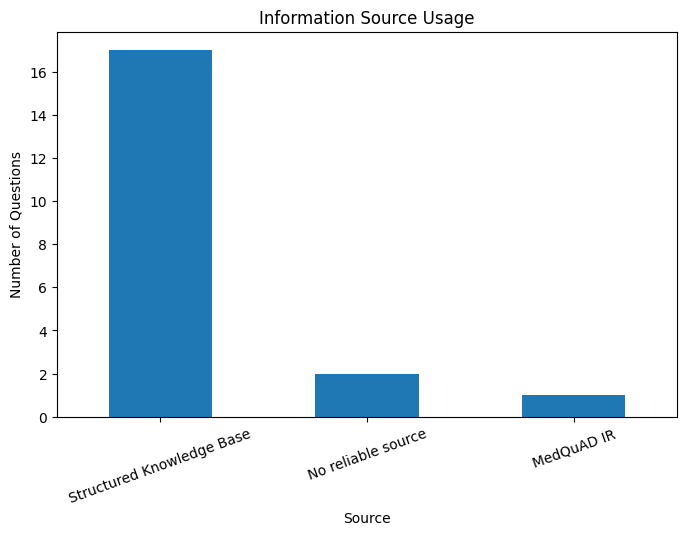

In [262]:
evaluation_results_df["source"].value_counts().plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Information Source Usage")
plt.xlabel("Source")
plt.ylabel("Number of Questions")
plt.xticks(rotation=20)
plt.show()

In [264]:
evaluation_summary = pd.DataFrame({
    "Metric": [
        "Intent Detection Accuracy",
        "Disease Detection Accuracy",
        "QA Type Accuracy"
    ],
    
    "Score": [
        round(intent_accuracy * 100, 2),
        round(disease_accuracy * 100, 2),
        round(qa_type_accuracy * 100, 2)
    ]
})

evaluation_summary

,Metric,Score
0,Intent Detection Accuracy,90.0
1,Disease Detection Accuracy,100.0
2,QA Type Accuracy,100.0


In [266]:
evaluation_summary

,Metric,Score
0,Intent Detection Accuracy,90.0
1,Disease Detection Accuracy,100.0
2,QA Type Accuracy,100.0


In [268]:
evaluation_results_df[
    ["question", "expected_type", "predicted_type",
     "type_correct", "source", "similarity"]
]

,question,expected_type,predicted_type,type_correct,source,similarity
0,What are the symptoms of diabetes?,symptoms,symptoms,True,Structured Knowledge Base,1.000000
1,What causes diabetes?,causes,causes,True,Structured Knowledge Base,1.000000
2,What are the treatments for diabetes?,treatment,treatment,True,Structured Knowledge Base,1.000000
3,How can diabetes be prevented?,prevention,prevention,True,Structured Knowledge Base,0.330441
4,What are the symptoms of malaria?,symptoms,symptoms,True,Structured Knowledge Base,1.000000
5,Who is at risk for malaria?,susceptibility,susceptibility,True,Structured Knowledge Base,0.000000
6,How can malaria be prevented?,prevention,prevention,True,Structured Knowledge Base,0.000000
7,What causes malaria?,causes,causes,True,Structured Knowledge Base,0.385372
8,What are the symptoms of dengue?,symptoms,symptoms,True,Structured Knowledge Base,0.774597
9,What causes dengue?,causes,causes,True,Structured Knowledge Base,0.000000


In [270]:
evaluation_data["expected_keywords"] = [
    
    # Diabetes
    "insulin,thirst,urination",
    "insulin",
    "insulin,glucose",
    "physical activity,healthy weight",
    
    # Malaria
    "fever,chills",
    "mosquito,transmission",
    "mosquito,repellent",
    "plasmodium,mosquito",
    
    # Dengue
    "fever,headache",
    "dengue virus,mosquito",
    "mosquito,standing water",
    "mosquito,transmission",
    
    # Asthma
    "wheezing,cough",
    "control,medicine",
    "airway,inflammation",
    
    # Tuberculosis
    "tuberculin,TB blood",
    "cough,fever",
    "mycobacterium tuberculosis",
    
    # Unsupported questions
    "",
    ""
]

In [272]:
def keyword_match_score(answer, expected_keywords):
    
    if not expected_keywords:
        return 1.0
    
    answer_lower = answer.lower()
    
    keywords = [
        keyword.strip().lower()
        for keyword in expected_keywords.split(",")
    ]
    
    matched = sum(
        keyword in answer_lower
        for keyword in keywords
    )
    
    return matched / len(keywords)

In [274]:
answer_scores = []

for _, row in evaluation_data.iterrows():
    
    result = combined_qa(row["question"])
    
    score = keyword_match_score(
        result["answer"],
        row["expected_keywords"]
    )
    
    answer_scores.append(score)

evaluation_results_df["answer_keyword_score"] = answer_scores

In [276]:
evaluation_results_df[
    [
        "question",
        "answer_keyword_score",
        "source"
    ]
]

,question,answer_keyword_score,source
0,What are the symptoms of diabetes?,0.666667,Structured Knowledge Base
1,What causes diabetes?,1.000000,Structured Knowledge Base
2,What are the treatments for diabetes?,1.000000,Structured Knowledge Base
3,How can diabetes be prevented?,1.000000,Structured Knowledge Base
4,What are the symptoms of malaria?,1.000000,Structured Knowledge Base
5,Who is at risk for malaria?,0.500000,Structured Knowledge Base
6,How can malaria be prevented?,1.000000,Structured Knowledge Base
7,What causes malaria?,1.000000,Structured Knowledge Base
8,What are the symptoms of dengue?,1.000000,Structured Knowledge Base
9,What causes dengue?,1.000000,Structured Knowledge Base


In [278]:
answer_quality_score = (
    evaluation_results_df["answer_keyword_score"].mean()
)

print(
    "Average Answer Keyword Coverage:",
    round(answer_quality_score * 100, 2),
    "%"
)

Average Answer Keyword Coverage: 93.33 %


In [280]:
evaluation_summary = pd.DataFrame({
    
    "Metric": [
        "Intent Detection Accuracy",
        "Disease Detection Accuracy",
        "QA Type Accuracy",
        "Average Answer Keyword Coverage"
    ],
    
    "Score": [
        round(intent_accuracy * 100, 2),
        round(disease_accuracy * 100, 2),
        round(qa_type_accuracy * 100, 2),
        round(answer_quality_score * 100, 2)
    ]
})

evaluation_summary

,Metric,Score
0,Intent Detection Accuracy,90.00
1,Disease Detection Accuracy,100.00
2,QA Type Accuracy,100.00
3,Average Answer Keyword Coverage,93.33


In [282]:
unsupported_results = []

for question in [
    "Who won the FIFA World Cup?",
    "What is the capital of France?"
]:
    
    result = combined_qa(question)
    
    unsupported_results.append({
        "question": question,
        "source": result["source"],
        "answer": result["answer"]
    })

unsupported_df = pd.DataFrame(
    unsupported_results
)

unsupported_df

,question,source,answer
0,Who won the FIFA World Cup?,No reliable source,"I'm sorry, I could not find a reliable answer ..."
1,What is the capital of France?,No reliable source,"I'm sorry, I could not find a reliable answer ..."


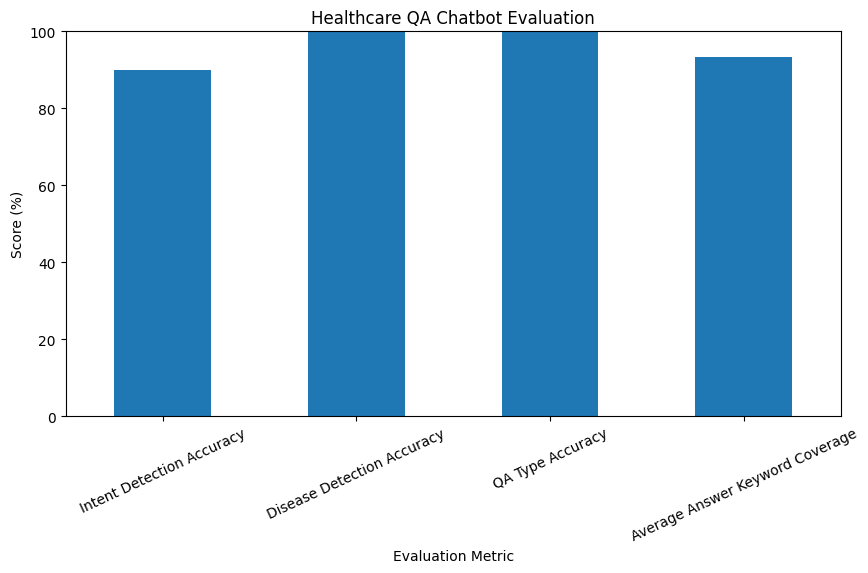

In [284]:
evaluation_summary.plot(
    x="Metric",
    y="Score",
    kind="bar",
    figsize=(10, 5),
    legend=False
)

plt.title("Healthcare QA Chatbot Evaluation")
plt.xlabel("Evaluation Metric")
plt.ylabel("Score (%)")
plt.xticks(rotation=25)
plt.ylim(0, 100)
plt.show()

In [286]:
supported_mask = evaluation_data["expected_type"] != "unknown"

supported_answer_scores = (
    evaluation_results_df.loc[
        supported_mask,
        "answer_keyword_score"
    ]
)

supported_answer_quality = (
    supported_answer_scores.mean()
)

print(
    "Supported Question Answer Keyword Coverage:",
    round(supported_answer_quality * 100, 2),
    "%"
)

Supported Question Answer Keyword Coverage: 92.59 %


In [288]:
evaluation_summary = pd.DataFrame({
    
    "Metric": [
        "Intent Detection Accuracy",
        "Disease Detection Accuracy",
        "QA Type Accuracy",
        "Answer Keyword Coverage"
    ],
    
    "Score": [
        round(intent_accuracy * 100, 2),
        round(disease_accuracy * 100, 2),
        round(qa_type_accuracy * 100, 2),
        round(supported_answer_quality * 100, 2)
    ]
})

evaluation_summary

,Metric,Score
0,Intent Detection Accuracy,90.00
1,Disease Detection Accuracy,100.00
2,QA Type Accuracy,100.00
3,Answer Keyword Coverage,92.59


In [290]:
print(
    "Intent Detection Accuracy:",
    round(intent_accuracy * 100, 2),
    "%"
)

print(
    "Disease Detection Accuracy:",
    round(disease_accuracy * 100, 2),
    "%"
)

print(
    "QA Type Accuracy:",
    round(qa_type_accuracy * 100, 2),
    "%"
)

print(
    "Answer Keyword Coverage:",
    round(supported_answer_quality * 100, 2),
    "%"
)

Intent Detection Accuracy: 90.0 %
Disease Detection Accuracy: 100.0 %
QA Type Accuracy: 100.0 %
Answer Keyword Coverage: 92.59 %


In [292]:
evaluation_results_df[
    evaluation_results_df["type_correct"] == False
][
    [
        "question",
        "expected_type",
        "predicted_type"
    ]
]

,question,expected_type,predicted_type


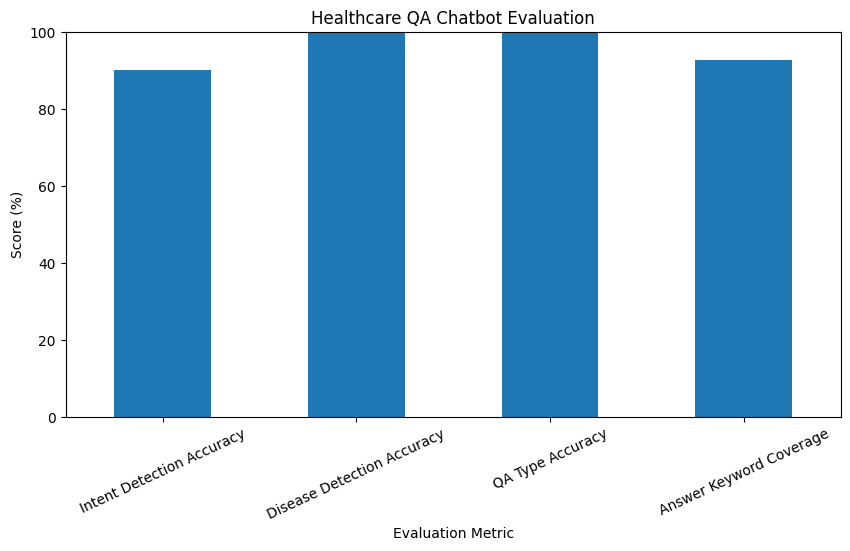

In [294]:
evaluation_summary.plot(
    x="Metric",
    y="Score",
    kind="bar",
    figsize=(10, 5),
    legend=False
)

plt.title("Healthcare QA Chatbot Evaluation")
plt.xlabel("Evaluation Metric")
plt.ylabel("Score (%)")
plt.xticks(rotation=25)
plt.ylim(0, 100)
plt.show()

In [296]:
type_correct == False

False

In [298]:
supported_questions = evaluation_data[
    evaluation_data["expected_type"] != "unknown"
].copy()

supported_predictions = [
    detect_question_type(question)
    for question in supported_questions["question"]
]

supported_intent_accuracy = sum(
    predicted == expected
    for predicted, expected in zip(
        supported_predictions,
        supported_questions["expected_type"]
    )
) / len(supported_questions)

print(
    "Healthcare Intent Detection Accuracy:",
    round(supported_intent_accuracy * 100, 2),
    "%"
)

Healthcare Intent Detection Accuracy: 100.0 %


In [300]:
unsupported_questions = evaluation_data[
    evaluation_data["expected_type"] == "unknown"
]

correct_rejections = 0

for question in unsupported_questions["question"]:
    
    result = combined_qa(question)
    
    if result["source"] == "No reliable source":
        correct_rejections += 1

out_of_domain_accuracy = (
    correct_rejections /
    len(unsupported_questions)
)

print(
    "Out-of-Domain Rejection Accuracy:",
    round(out_of_domain_accuracy * 100, 2),
    "%"
)

Out-of-Domain Rejection Accuracy: 100.0 %


In [302]:
evaluation_summary = pd.DataFrame({
    
    "Metric": [
        "Healthcare Intent Detection Accuracy",
        "Disease Detection Accuracy",
        "QA Type Accuracy",
        "Answer Keyword Coverage",
        "Out-of-Domain Rejection Accuracy"
    ],
    
    "Score": [
        round(supported_intent_accuracy * 100, 2),
        round(disease_accuracy * 100, 2),
        round(qa_type_accuracy * 100, 2),
        round(supported_answer_quality * 100, 2),
        round(out_of_domain_accuracy * 100, 2)
    ]
})

evaluation_summary

,Metric,Score
0,Healthcare Intent Detection Accuracy,100.00
1,Disease Detection Accuracy,100.00
2,QA Type Accuracy,100.00
3,Answer Keyword Coverage,92.59
4,Out-of-Domain Rejection Accuracy,100.00


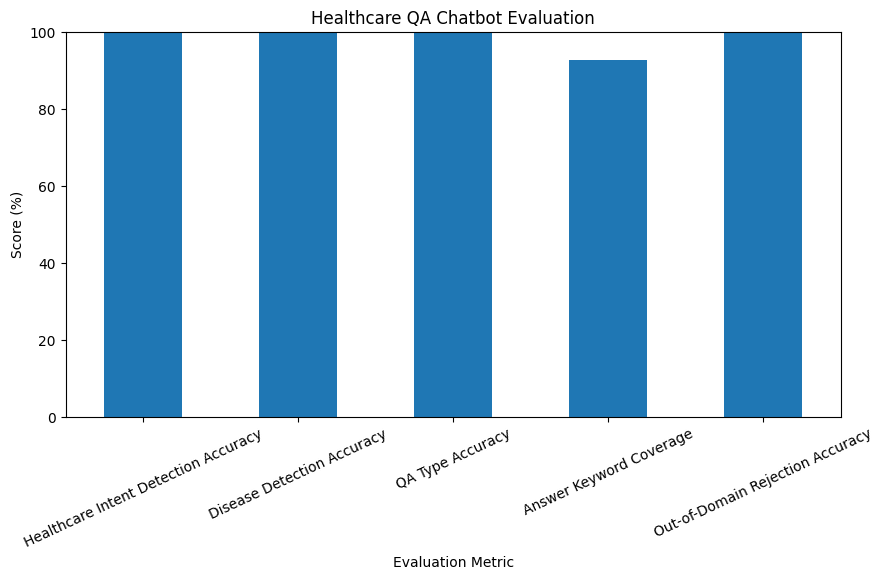

In [304]:
evaluation_summary.plot(
    x="Metric",
    y="Score",
    kind="bar",
    figsize=(10, 5),
    legend=False
)

plt.title("Healthcare QA Chatbot Evaluation")
plt.xlabel("Evaluation Metric")
plt.ylabel("Score (%)")
plt.xticks(rotation=25)
plt.ylim(0, 100)
plt.show()

In [306]:
def chatbot():
    
    global conversation_context
    
    conversation_context = {
        "last_disease": None
    }
    
    print("=" * 60)
    print("       HEALTHCARE QA CHATBOT")
    print("=" * 60)
    print("Ask a healthcare question.")
    print("Type 'exit' to end the conversation.")
    print("=" * 60)
    
    while True:
        
        user_input = input("\nYou: ")
        
        if user_input.lower().strip() == "exit":
            print("\nBot: Thank you. Goodbye!")
            break
        
        result = combined_qa(user_input)
        
        print("\nBot:", result["answer"])
        print("Source:", result["source"])

       HEALTHCARE QA CHATBOT
Ask a healthcare question.
Type 'exit' to end the conversation.



You:  What are the symptoms of malaria?



Bot: fever, chills, sweating, headache, nausea, vomiting, muscle pain
Source: Structured Knowledge Base



You:  Who is at risk for it?



Bot: travel or residence in areas where malaria transmission occurs
Source: Structured Knowledge Base


...


Bot: I'm sorry, I could not find a reliable answer to that question.
Source: No reliable source



You:  Who won the FIFA World Cup?



Bot: I'm sorry, I could not find a reliable answer to that question.
Source: No reliable source



You:  exit



Bot: Thank you. Goodbye!


In [312]:
def handle_dialogue(question):
    
    q = question.lower().strip()
    
    if q in ["hi", "hello", "hey", "hii", "good morning", "good afternoon"]:
        return "Hello! I'm a healthcare QA assistant. Ask me a healthcare-related question."
    
    if q in ["thanks", "thank you", "thankyou", "thx"]:
        return "You're welcome!"
    
    if q in ["bye", "goodbye", "see you"]:
        return "Goodbye! Take care."
    
    if q in ["how are you", "how are you?"]:
        return "I'm ready to help with healthcare-related questions."
    
    return None

In [314]:
def chatbot():
    
    global conversation_context
    
    conversation_context = {
        "last_disease": None
    }
    
    print("=" * 60)
    print("       HEALTHCARE QA CHATBOT")
    print("=" * 60)
    print("Ask a healthcare question.")
    print("Type 'exit' to end the conversation.")
    print("=" * 60)
    
    while True:
        
        user_input = input("\nYou: ")
        
        if user_input.lower().strip() == "exit":
            print("\nBot: Thank you. Goodbye!")
            break
        
        # Handle simple dialogue
        dialogue_response = handle_dialogue(user_input)
        
        if dialogue_response is not None:
            print("\nBot:", dialogue_response)
            continue
        
        # Handle healthcare question
        result = combined_qa(user_input)
        
        print("\nBot:", result["answer"])
        print("Source:", result["source"])

In [316]:
chatbot()


       HEALTHCARE QA CHATBOT
Ask a healthcare question.
Type 'exit' to end the conversation.



You:  hello



Bot: Hello! I'm a healthcare QA assistant. Ask me a healthcare-related question.



You:  thanks



Bot: You're welcome!


...


Bot: fever, chills, sweating, headache, nausea, vomiting, muscle pain
Source: Structured Knowledge Base



You:  exir



Bot: I'm sorry, I could not find a reliable answer to that question.
Source: No reliable source



You:  exit



Bot: Thank you. Goodbye!


In [318]:
def chatbot():
    
    global conversation_context
    
    conversation_context = {
        "last_disease": None
    }
    
    print("=" * 60)
    print("       HEALTHCARE QA CHATBOT")
    print("=" * 60)
    print("This chatbot provides educational healthcare information.")
    print("It is not a substitute for professional medical advice.")
    print("Ask a healthcare-related question.")
    print("Type 'exit' to end the conversation.")
    print("=" * 60)
    
    while True:
        
        user_input = input("\nYou: ")
        
        if user_input.lower().strip() == "exit":
            print("\nBot: Thank you. Goodbye!")
            break
        
        dialogue_response = handle_dialogue(user_input)
        
        if dialogue_response is not None:
            print("\nBot:", dialogue_response)
            continue
        
        result = combined_qa(user_input)
        
        print("\nBot:", result["answer"])
        print("Source:", result["source"])

In [320]:
def refine_answer(question, answer, source):
    
    # Keep short answers unchanged
    if len(answer) <= 500:
        return answer, source
    
    # Try the structured knowledge base first
    kb_result = knowledge_answer(question)
    
    if kb_result is not None:
        return kb_result, "Structured Knowledge Base"
    
    # Split long answers into sentences
    sentences = re.split(
        r'(?<=[.!?])\s+',
        answer.strip()
    )
    
    # Keep the first few meaningful sentences
    cleaned_sentences = [
        sentence.strip()
        for sentence in sentences
        if len(sentence.strip()) > 20
    ]
    
    if len(cleaned_sentences) >= 3:
        shortened_answer = " ".join(
            cleaned_sentences[:3]
        )
    else:
        shortened_answer = answer[:500].rsplit(
            " ",
            1
        )[0] + "..."
    
    return shortened_answer, source

In [322]:
conversation_context = {
    "last_disease": None
}

demo_questions = [
    "Hello",
    "What are the symptoms of malaria?",
    "Who is at risk for it?",
    "How can it be prevented?",
    "What causes dengue?",
    "How is tuberculosis diagnosed?",
    "Thanks"
]

for question in demo_questions:

    dialogue_response = handle_dialogue(question)

    if dialogue_response is not None:
        answer = dialogue_response
        source = "Dialogue Manager"
    
    else:
        result = combined_qa(question)
        answer = result["answer"]
        source = result["source"]

    print("=" * 80)
    print("USER:", question)
    print("BOT:", answer)
    print("SOURCE:", source)

USER: Hello
BOT: Hello! I'm a healthcare QA assistant. Ask me a healthcare-related question.
SOURCE: Dialogue Manager
USER: What are the symptoms of malaria?
BOT: fever, chills, sweating, headache, nausea, vomiting, muscle pain
SOURCE: Structured Knowledge Base
USER: Who is at risk for it?
BOT: travel or residence in areas where malaria transmission occurs
SOURCE: Structured Knowledge Base
USER: How can it be prevented?
BOT: prevent mosquito bites, use insect repellent, and use mosquito nets in risk areas
SOURCE: Structured Knowledge Base
USER: What causes dengue?
BOT: infection with dengue virus transmitted through infected mosquitoes
SOURCE: Structured Knowledge Base
USER: How is tuberculosis diagnosed?
BOT: Tuberculosis (TB) is a disease that is spread through the air from one person to another. There are two kinds of tests that are used to determine if a person has been infected with TB bacteria: the tuberculin skin test and TB blood tests. A positive TB skin test or TB blood test 

## 10. Dialogue Flow Design

The chatbot follows a simple dialogue management strategy:

1. Receive user input.
2. Check for simple conversational intents such as greetings, thanks, and goodbye.
3. Detect the medical question type.
4. Detect the disease or medical condition.
5. Update the conversation context with the current disease.
6. For explicit medical questions, retrieve an answer using the MedQuAD IR system.
7. If the IR system cannot provide a reliable answer, query the structured healthcare knowledge base.
8. For follow-up questions, use the previously stored disease context.
9. Refine long answers to make them more suitable for conversational interaction.
10. Return the answer and information source.
11. If no reliable answer is available, return a safe fallback response.

In [324]:
from datasets import load_dataset

In [328]:
wiki_dataset = load_dataset(
    "bilawalriaz/MedAtoms-Wiki"
)

In [330]:
from datasets import load_dataset

wiki_stream = load_dataset(
    "bilawalriaz/MedAtoms-Wiki",
    split="train",
    streaming=True
)

print(wiki_stream)

IterableDataset({
    features: ['id', 'text', 'word_count', 'char_count', 'medical_area', 'tags', 'core'],
    num_shards: 1
})


In [332]:
for i, row in enumerate(wiki_stream):
    
    print("=" * 80)
    print(row)
    
    if i == 4:
        break

{'id': 'wiki_072086', 'text': 'Plant mitochondrial plasmids vary in size, ranging from 0.7 kilobases (kb) to 20 kb.', 'word_count': 14, 'char_count': 84, 'medical_area': 'General Medicine', 'tags': 'plasmids|yeast genetic engineering|molecular cloning|DNA conformations|plasmid extraction methods|plant mitochondrial plasmids|chromatin formation|bioinformatics in molecular biology', 'core': True}
{'id': 'wiki_012507', 'text': "Conventional one-sided PCR uses one gene-specific primer and one general primer, which can produce non-specific amplification products or 'noise'.", 'word_count': 19, 'char_count': 146, 'medical_area': 'General Medicine', 'tags': 'Polymerase Chain Reaction (PCR)|DNA Amplification Techniques|Thermostable Enzymes|PCR Variants and Derivatives|History of Molecular Biology|Patent Disputes in Biotechnology|Thermophilic Microorganisms', 'core': True}
{'id': 'wiki_022817', 'text': 'Afterimages generated by color adaptation typically persist for durations ranging from sever

In [334]:
wiki_stream = load_dataset(
    "bilawalriaz/MedAtoms-Wiki",
    split="train",
    streaming=True
)

print(wiki_stream)

IterableDataset({
    features: ['id', 'text', 'word_count', 'char_count', 'medical_area', 'tags', 'core'],
    num_shards: 1
})


In [336]:
for i, row in enumerate(wiki_stream):
    print("=" * 80)
    print(row)
    
    if i == 4:
        break

{'id': 'wiki_072086', 'text': 'Plant mitochondrial plasmids vary in size, ranging from 0.7 kilobases (kb) to 20 kb.', 'word_count': 14, 'char_count': 84, 'medical_area': 'General Medicine', 'tags': 'plasmids|yeast genetic engineering|molecular cloning|DNA conformations|plasmid extraction methods|plant mitochondrial plasmids|chromatin formation|bioinformatics in molecular biology', 'core': True}
{'id': 'wiki_012507', 'text': "Conventional one-sided PCR uses one gene-specific primer and one general primer, which can produce non-specific amplification products or 'noise'.", 'word_count': 19, 'char_count': 146, 'medical_area': 'General Medicine', 'tags': 'Polymerase Chain Reaction (PCR)|DNA Amplification Techniques|Thermostable Enzymes|PCR Variants and Derivatives|History of Molecular Biology|Patent Disputes in Biotechnology|Thermophilic Microorganisms', 'core': True}
{'id': 'wiki_022817', 'text': 'Afterimages generated by color adaptation typically persist for durations ranging from sever

In [338]:
wiki_records = []

for row in wiki_stream:
    
    if row["core"] is True:
        wiki_records.append(row)
    
    if len(wiki_records) >= 20000:
        break

print("Records collected:", len(wiki_records))

Records collected: 20000


In [340]:
wiki_df = pd.DataFrame(wiki_records)

print("Shape:", wiki_df.shape)
wiki_df.head()

Shape: (20000, 7)


,id,text,word_count,char_count,medical_area,tags,core
0,wiki_072086,"Plant mitochondrial plasmids vary in size, ran...",14,84,General Medicine,plasmids|yeast genetic engineering|molecular c...,True
1,wiki_012507,Conventional one-sided PCR uses one gene-speci...,19,146,General Medicine,Polymerase Chain Reaction (PCR)|DNA Amplificat...,True
2,wiki_022817,Afterimages generated by color adaptation typi...,17,125,General Medicine,cone cells|color vision|afterimages|color blin...,True
3,wiki_000919,Ischemia refers to a state in which tissues re...,17,115,Hematology,hematology|blood disorders|circulatory system|...,True
4,wiki_028924,Clinical trials demonstrate that combining ant...,23,200,General Medicine,inflammation|cytokines|depression|immune_respo...,True


In [342]:
wiki_df["medical_area"].value_counts()

medical_area
General Medicine      12969
Anatomy                2174
Physiology             1592
Genetics                664
Pharmacology            429
Epidemiology            383
Biochemistry            330
Immunology              278
Infectious Disease      209
Pathology               174
Biostatistics           172
Endocrinology           130
Microbiology            119
Hematology               80
Emergency Medicine       80
Oncology                 60
Internal Medicine        51
Radiology                29
Cardiology               22
Psychiatry               22
Surgery                  14
Gynecology               11
Ophthalmology             8
Name: count, dtype: int64

In [344]:
for i in range(10):
    
    print("=" * 80)
    print("AREA:", wiki_df.iloc[i]["medical_area"])
    print("TEXT:", wiki_df.iloc[i]["text"])
    print("TAGS:", wiki_df.iloc[i]["tags"])

AREA: General Medicine
TEXT: Plant mitochondrial plasmids vary in size, ranging from 0.7 kilobases (kb) to 20 kb.
TAGS: plasmids|yeast genetic engineering|molecular cloning|DNA conformations|plasmid extraction methods|plant mitochondrial plasmids|chromatin formation|bioinformatics in molecular biology
AREA: General Medicine
TEXT: Conventional one-sided PCR uses one gene-specific primer and one general primer, which can produce non-specific amplification products or 'noise'.
TAGS: Polymerase Chain Reaction (PCR)|DNA Amplification Techniques|Thermostable Enzymes|PCR Variants and Derivatives|History of Molecular Biology|Patent Disputes in Biotechnology|Thermophilic Microorganisms
AREA: General Medicine
TEXT: Afterimages generated by color adaptation typically persist for durations ranging from several seconds to over sixty seconds.
TAGS: cone cells|color vision|afterimages|color blindness|retinal disorders|photoreceptor diseases|visual perception
AREA: Hematology
TEXT: Ischemia refers to 

In [346]:
wiki_df.to_csv(
    "medical_wikipedia_facts.csv",
    index=False
)

print("Medical Wikipedia corpus saved successfully.")

Medical Wikipedia corpus saved successfully.


In [348]:
wiki_records = []

for row in wiki_stream:
    if row["core"] is True:
        wiki_records.append(row)
    
    if len(wiki_records) >= 20000:
        break

print("Records collected:", len(wiki_records))

Records collected: 20000


In [350]:
wiki_df = pd.DataFrame(wiki_records)

print("Shape:", wiki_df.shape)
wiki_df.head()

Shape: (20000, 7)


,id,text,word_count,char_count,medical_area,tags,core
0,wiki_072086,"Plant mitochondrial plasmids vary in size, ran...",14,84,General Medicine,plasmids|yeast genetic engineering|molecular c...,True
1,wiki_012507,Conventional one-sided PCR uses one gene-speci...,19,146,General Medicine,Polymerase Chain Reaction (PCR)|DNA Amplificat...,True
2,wiki_022817,Afterimages generated by color adaptation typi...,17,125,General Medicine,cone cells|color vision|afterimages|color blin...,True
3,wiki_000919,Ischemia refers to a state in which tissues re...,17,115,Hematology,hematology|blood disorders|circulatory system|...,True
4,wiki_028924,Clinical trials demonstrate that combining ant...,23,200,General Medicine,inflammation|cytokines|depression|immune_respo...,True


In [352]:
wiki_df["medical_area"].value_counts()

medical_area
General Medicine      12969
Anatomy                2174
Physiology             1592
Genetics                664
Pharmacology            429
Epidemiology            383
Biochemistry            330
Immunology              278
Infectious Disease      209
Pathology               174
Biostatistics           172
Endocrinology           130
Microbiology            119
Hematology               80
Emergency Medicine       80
Oncology                 60
Internal Medicine        51
Radiology                29
Cardiology               22
Psychiatry               22
Surgery                  14
Gynecology               11
Ophthalmology             8
Name: count, dtype: int64

In [354]:
useful_medical_areas = [
    "General Medicine",
    "Anatomy",
    "Physiology",
    "Genetics",
    "Pharmacology",
    "Epidemiology",
    "Immunology",
    "Infectious Disease",
    "Pathology",
    "Endocrinology",
    "Microbiology",
    "Hematology",
    "Emergency Medicine",
    "Oncology",
    "Internal Medicine",
    "Radiology",
    "Cardiology",
    "Psychiatry",
    "Surgery",
    "Gynecology",
    "Ophthalmology"
]

wiki_retrieval_df = wiki_df[
    wiki_df["medical_area"].isin(useful_medical_areas)
].copy()

print("Wikipedia facts for retrieval:", len(wiki_retrieval_df))

Wikipedia facts for retrieval: 19498


In [356]:
print(wiki_retrieval_df["medical_area"].value_counts())

medical_area
General Medicine      12969
Anatomy                2174
Physiology             1592
Genetics                664
Pharmacology            429
Epidemiology            383
Immunology              278
Infectious Disease      209
Pathology               174
Endocrinology           130
Microbiology            119
Hematology               80
Emergency Medicine       80
Oncology                 60
Internal Medicine        51
Radiology                29
Cardiology               22
Psychiatry               22
Surgery                  14
Gynecology               11
Ophthalmology             8
Name: count, dtype: int64


In [358]:
print("Total facts:", len(wiki_retrieval_df))
print("Unique medical areas:", wiki_retrieval_df["medical_area"].nunique())

Total facts: 19498
Unique medical areas: 21


In [360]:
wiki_retrieval_df["processed_text"] = (
    wiki_retrieval_df["text"]
    .fillna("")
    .apply(preprocess_text)
)

print(wiki_retrieval_df[
    ["text", "processed_text"]
].head())

                                                text  \
0  Plant mitochondrial plasmids vary in size, ran...   
1  Conventional one-sided PCR uses one gene-speci...   
2  Afterimages generated by color adaptation typi...   
3  Ischemia refers to a state in which tissues re...   
4  Clinical trials demonstrate that combining ant...   

                                      processed_text  
0  plant mitochondrial plasmid vary size ranging ...  
1  conventional one sided pcr us one gene specifi...  
2  afterimage generated color adaptation typicall...  
3  ischemia refers state tissue receive inadequat...  
4  clinical trial demonstrate combining anti infl...  


In [362]:
wiki_vectorizer = TfidfVectorizer(
    ngram_range=(1, 2),
    min_df=1,
    max_features=50000
)

wiki_vectors = wiki_vectorizer.fit_transform(
    wiki_retrieval_df["processed_text"]
)

print("Wikipedia TF-IDF matrix shape:")
print(wiki_vectors.shape)

Wikipedia TF-IDF matrix shape:
(19498, 50000)


In [364]:
def retrieve_wikipedia_facts(user_question, top_k=3):
    
    processed_query = preprocess_text(
        user_question
    )
    
    query_vector = wiki_vectorizer.transform(
        [processed_query]
    )
    
    similarities = cosine_similarity(
        query_vector,
        wiki_vectors
    ).flatten()
    
    top_indices = similarities.argsort()[-top_k:][::-1]
    
    results = wiki_retrieval_df.iloc[
        top_indices
    ].copy()
    
    results["similarity"] = similarities[
        top_indices
    ]
    
    return results

In [366]:
retrieve_wikipedia_facts(
    "What is the function of the heart?"
)

,id,text,word_count,char_count,medical_area,tags,core,processed_text,similarity
14822,wiki_018450,Branchial hearts in cephalopods are alternativ...,11,77,Anatomy,invertebrate circulatory systems|comparative a...,True,branchial heart cephalopod alternatively refer...,0.423185
8492,wiki_018057,Neural signals to the heart influence but do n...,14,81,Anatomy,cardiac anatomy|coronary circulation|heart dev...,True,neural signal heart influence directly control...,0.352622
6772,wiki_018311,Arrhythmogenic cardiomyopathy makes the heart ...,11,89,Physiology,cardiovascular physiology|heart disease|cardia...,True,arrhythmogenic cardiomyopathy make heart susce...,0.320881


In [368]:
retrieve_wikipedia_facts(
    "What is anemia?"
)

,id,text,word_count,char_count,medical_area,tags,core,processed_text,similarity
6611,wiki_043434,Both hemoglobinopathies and thalassemias resul...,7,58,Genetics,Hemoglobin|Oxygen transport|Red blood cells|He...,True,hemoglobinopathy thalassemia result anemia,0.494646
9177,wiki_043683,"Anemia has diverse etiologies, with iron defic...",20,148,General Medicine,hemoglobin|anemia|hemoglobinopathies|glycated ...,True,anemia diverse etiology iron deficiency repres...,0.393253
14009,wiki_000922,Anemia can develop as a consequence of bleedin...,18,132,Hematology,hematology|blood disorders|circulatory system|...,True,anemia develop consequence bleeding inherited ...,0.270171


In [370]:
retrieve_wikipedia_facts(
    "What causes diabetes?"
)

,id,text,word_count,char_count,medical_area,tags,core,processed_text,similarity
8204,wiki_036572,Diabetes is the leading cause of limb amputati...,11,69,General Medicine,preventive_healthcare|chronic_disease_preventi...,True,diabetes leading cause limb amputation america...,0.426532
6781,wiki_032789,"For individuals with type 1 diabetes, regular ...",13,92,Anatomy,pancreatic_cancer|diabetes_mellitus|pancreatic...,True,individual type 1 diabetes regular insulin inj...,0.252305
14603,wiki_030875,Common causes of acquired nerve damage leading...,29,208,General Medicine,pain perception|neuropathy|nociception|pain th...,True,common cause acquired nerve damage leading pai...,0.228312


In [372]:
retrieve_wikipedia_facts(
    "What is the function of insulin?"
)

,id,text,word_count,char_count,medical_area,tags,core,processed_text,similarity
309,wiki_069794,Insulin degradation typically involves endocyt...,16,145,General Medicine,insulin|glucose metabolism|endocrine regulatio...,True,insulin degradation typically involves endocyt...,0.480331
6521,wiki_069673,Insulin binds to the extracellular-facing α-su...,11,87,General Medicine,insulin secretion|calcium signaling|pancreatic...,True,insulin bind extracellular facing subunit insu...,0.470216
14893,wiki_022767,Metformin's gluconeogenesis inhibition compens...,15,143,Physiology,gluconeogenesis|metabolic pathways|enzyme regu...,True,metformin gluconeogenesis inhibition compensat...,0.355835


In [374]:
retrieve_wikipedia_facts(
    "Who won the FIFA World Cup?"
)

,id,text,word_count,char_count,medical_area,tags,core,processed_text,similarity
7561,wiki_061250,"In recent decades, the field of public health ...",29,186,Epidemiology,public health history|epidemiology|sanitation ...,True,recent decade field public health education ex...,0.306566
3614,wiki_041037,Certain psychological phenomena are not confin...,17,124,General Medicine,social psychology|experimental methodology|bys...,True,certain psychological phenomenon confined labo...,0.271307
5609,wiki_025074,The defined daily dose (DDD) is a standardized...,23,162,General Medicine,antimicrobial resistance|antibiotic prescribin...,True,defined daily dose ddd standardized metric dru...,0.255691


In [376]:
wiki_retrieval_df.to_csv(
    "medical_wikipedia_facts.csv",
    index=False
)

print("Saved:", len(wiki_retrieval_df), "medical facts")

Saved: 19498 medical facts


In [378]:
retrieve_wikipedia_facts("What is the function of the heart?")

,id,text,word_count,char_count,medical_area,tags,core,processed_text,similarity
14822,wiki_018450,Branchial hearts in cephalopods are alternativ...,11,77,Anatomy,invertebrate circulatory systems|comparative a...,True,branchial heart cephalopod alternatively refer...,0.423185
8492,wiki_018057,Neural signals to the heart influence but do n...,14,81,Anatomy,cardiac anatomy|coronary circulation|heart dev...,True,neural signal heart influence directly control...,0.352622
6772,wiki_018311,Arrhythmogenic cardiomyopathy makes the heart ...,11,89,Physiology,cardiovascular physiology|heart disease|cardia...,True,arrhythmogenic cardiomyopathy make heart susce...,0.320881


In [380]:
retrieve_wikipedia_facts("What is anemia?")

,id,text,word_count,char_count,medical_area,tags,core,processed_text,similarity
6611,wiki_043434,Both hemoglobinopathies and thalassemias resul...,7,58,Genetics,Hemoglobin|Oxygen transport|Red blood cells|He...,True,hemoglobinopathy thalassemia result anemia,0.494646
9177,wiki_043683,"Anemia has diverse etiologies, with iron defic...",20,148,General Medicine,hemoglobin|anemia|hemoglobinopathies|glycated ...,True,anemia diverse etiology iron deficiency repres...,0.393253
14009,wiki_000922,Anemia can develop as a consequence of bleedin...,18,132,Hematology,hematology|blood disorders|circulatory system|...,True,anemia develop consequence bleeding inherited ...,0.270171


In [382]:
retrieve_wikipedia_facts("What causes diabetes?")

,id,text,word_count,char_count,medical_area,tags,core,processed_text,similarity
8204,wiki_036572,Diabetes is the leading cause of limb amputati...,11,69,General Medicine,preventive_healthcare|chronic_disease_preventi...,True,diabetes leading cause limb amputation america...,0.426532
6781,wiki_032789,"For individuals with type 1 diabetes, regular ...",13,92,Anatomy,pancreatic_cancer|diabetes_mellitus|pancreatic...,True,individual type 1 diabetes regular insulin inj...,0.252305
14603,wiki_030875,Common causes of acquired nerve damage leading...,29,208,General Medicine,pain perception|neuropathy|nociception|pain th...,True,common cause acquired nerve damage leading pai...,0.228312


In [384]:
retrieve_wikipedia_facts("What is the function of insulin?")

,id,text,word_count,char_count,medical_area,tags,core,processed_text,similarity
309,wiki_069794,Insulin degradation typically involves endocyt...,16,145,General Medicine,insulin|glucose metabolism|endocrine regulatio...,True,insulin degradation typically involves endocyt...,0.480331
6521,wiki_069673,Insulin binds to the extracellular-facing α-su...,11,87,General Medicine,insulin secretion|calcium signaling|pancreatic...,True,insulin bind extracellular facing subunit insu...,0.470216
14893,wiki_022767,Metformin's gluconeogenesis inhibition compens...,15,143,Physiology,gluconeogenesis|metabolic pathways|enzyme regu...,True,metformin gluconeogenesis inhibition compensat...,0.355835


In [386]:
!pip install -q sentence-transformers

DEPRECATION: Loading egg at c:\programdata\anaconda3\lib\site-packages\vboxapi-1.0-py3.11.egg is deprecated. pip 24.3 will enforce this behaviour change. A possible replacement is to use pip for package installation.. Discussion can be found at https://github.com/pypa/pip/issues/12330


In [388]:
from sentence_transformers import SentenceTransformer

In [389]:
semantic_model = SentenceTransformer(
    "all-MiniLM-L6-v2"
)

print("Semantic model loaded successfully.")

C:\Users\Student\AppData\Roaming\Python\Python311\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Student\.cache\huggingface\hub\models--sentence-transformers--all-MiniLM-L6-v2. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/90.9M [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Semantic model loaded successfully.


In [392]:
print("Testing SentenceTransformer...")

Testing SentenceTransformer...


In [394]:
from sentence_transformers import SentenceTransformer

semantic_model = SentenceTransformer("all-MiniLM-L6-v2")

print("DONE")

DONE


In [396]:
semantic_model = SentenceTransformer(
    "all-MiniLM-L6-v2"
)

In [398]:
wiki_retrieval_df["semantic_text"] = (
    wiki_retrieval_df["text"].fillna("")
    + " "
    + wiki_retrieval_df["medical_area"].fillna("")
    + " "
    + wiki_retrieval_df["tags"].fillna("")
)

print(wiki_retrieval_df["semantic_text"].head())

0    Plant mitochondrial plasmids vary in size, ran...
1    Conventional one-sided PCR uses one gene-speci...
2    Afterimages generated by color adaptation typi...
3    Ischemia refers to a state in which tissues re...
4    Clinical trials demonstrate that combining ant...
Name: semantic_text, dtype: object


In [400]:
wiki_embeddings = semantic_model.encode(
    wiki_retrieval_df["semantic_text"].tolist(),
    show_progress_bar=True,
    normalize_embeddings=True
)

print("Embedding shape:", wiki_embeddings.shape)

Batches:   0%|          | 0/610 [00:00<?, ?it/s]

Embedding shape: (19498, 384)


In [401]:
def retrieve_wikipedia_semantic(user_question, top_k=3):
    
    query_embedding = semantic_model.encode(
        [user_question],
        normalize_embeddings=True
    )
    
    similarities = wiki_embeddings @ query_embedding[0]
    
    top_indices = similarities.argsort()[-top_k:][::-1]
    
    results = wiki_retrieval_df.iloc[top_indices].copy()
    
    results["similarity"] = similarities[top_indices]
    
    return results

In [402]:
retrieve_wikipedia_semantic(
    "What is the function of the heart?"
)

,id,text,word_count,char_count,medical_area,tags,core,processed_text,semantic_text,similarity
6713,wiki_067817,The coordinated function of the left and right...,25,134,Anatomy,blood vessels|circulatory system|vascular anat...,True,coordinated function left right side heart ena...,The coordinated function of the left and right...,0.590246
14398,wiki_052778,"The pericardium surrounds the heart, anchoring...",18,136,Anatomy,human anatomy|human physiology|cellular biolog...,True,pericardium surround heart anchoring within me...,"The pericardium surrounds the heart, anchoring...",0.579361
17174,wiki_018460,"In numerous religious traditions, the heart se...",17,119,General Medicine,cardiovascular health|cultural symbolism of th...,True,numerous religious tradition heart serf symbol...,"In numerous religious traditions, the heart se...",0.573699


In [403]:
retrieve_wikipedia_semantic(
    "What causes diabetes?"
)

,id,text,word_count,char_count,medical_area,tags,core,processed_text,semantic_text,similarity
16631,wiki_069926,Diabetes is a broad medical term encompassing ...,18,125,General Medicine,insulin|diabetes|metabolic syndrome|insulin an...,True,diabetes broad medical term encompassing condi...,Diabetes is a broad medical term encompassing ...,0.637152
14409,wiki_064541,Insulin resistance or insufficient insulin pro...,22,169,Physiology,glycolysis|metabolic pathways|cancer metabolis...,True,insulin resistance insufficient insulin produc...,Insulin resistance or insufficient insulin pro...,0.636119
10957,wiki_032791,Both genetic predisposition and environmental ...,14,100,Anatomy,pancreatic_cancer|diabetes_mellitus|pancreatic...,True,genetic predisposition environmental influence...,Both genetic predisposition and environmental ...,0.633110


In [404]:
retrieve_wikipedia_semantic(
    "What is the function of insulin?"
)

,id,text,word_count,char_count,medical_area,tags,core,processed_text,semantic_text,similarity
7052,wiki_069671,Insulin exerts its biological effects by bindi...,22,142,General Medicine,insulin secretion|calcium signaling|pancreatic...,True,insulin exerts biological effect binding insul...,Insulin exerts its biological effects by bindi...,0.667612
3387,wiki_069811,"As an anabolic hormone, insulin drives the cel...",17,135,Endocrinology,endocrinology|hormone biochemistry|glucose met...,True,anabolic hormone insulin drive cellular conver...,"As an anabolic hormone, insulin drives the cel...",0.649385
6913,wiki_069803,Insulin functions as a peptide hormone synthes...,15,102,Endocrinology,endocrinology|hormone biochemistry|glucose met...,True,insulin function peptide hormone synthesized b...,Insulin functions as a peptide hormone synthes...,0.649272


In [405]:
retrieve_wikipedia_semantic(
    "What is anemia?"
)

,id,text,word_count,char_count,medical_area,tags,core,processed_text,semantic_text,similarity
16929,wiki_000921,Anemia is a medical condition marked by an ins...,21,141,Hematology,hematology|blood disorders|circulatory system|...,True,anemia medical condition marked insufficient m...,Anemia is a medical condition marked by an ins...,0.841307
14009,wiki_000922,Anemia can develop as a consequence of bleedin...,18,132,Hematology,hematology|blood disorders|circulatory system|...,True,anemia develop consequence bleeding inherited ...,Anemia can develop as a consequence of bleedin...,0.714577
9177,wiki_043683,"Anemia has diverse etiologies, with iron defic...",20,148,General Medicine,hemoglobin|anemia|hemoglobinopathies|glycated ...,True,anemia diverse etiology iron deficiency repres...,"Anemia has diverse etiologies, with iron defic...",0.650358


In [412]:
retrieve_wikipedia_semantic(
    "What causes diabetes?"
)

,id,text,word_count,char_count,medical_area,tags,core,processed_text,semantic_text,similarity
16631,wiki_069926,Diabetes is a broad medical term encompassing ...,18,125,General Medicine,insulin|diabetes|metabolic syndrome|insulin an...,True,diabetes broad medical term encompassing condi...,Diabetes is a broad medical term encompassing ...,0.637152
14409,wiki_064541,Insulin resistance or insufficient insulin pro...,22,169,Physiology,glycolysis|metabolic pathways|cancer metabolis...,True,insulin resistance insufficient insulin produc...,Insulin resistance or insufficient insulin pro...,0.636119
10957,wiki_032791,Both genetic predisposition and environmental ...,14,100,Anatomy,pancreatic_cancer|diabetes_mellitus|pancreatic...,True,genetic predisposition environmental influence...,Both genetic predisposition and environmental ...,0.633110


In [414]:
retrieve_wikipedia_semantic(
    "What are the symptoms of diabetes?"
)

,id,text,word_count,char_count,medical_area,tags,core,processed_text,semantic_text,similarity
9206,wiki_069798,Common symptoms of hypoglycemia include sensat...,14,116,General Medicine,insulin|glucose metabolism|endocrine regulatio...,True,common symptom hypoglycemia include sensation ...,Common symptoms of hypoglycemia include sensat...,0.582767
16631,wiki_069926,Diabetes is a broad medical term encompassing ...,18,125,General Medicine,insulin|diabetes|metabolic syndrome|insulin an...,True,diabetes broad medical term encompassing condi...,Diabetes is a broad medical term encompassing ...,0.514602
17468,wiki_032787,When type 1 diabetes remains untreated over ti...,25,197,Anatomy,pancreatic_cancer|diabetes_mellitus|pancreatic...,True,type 1 diabetes remains untreated time result ...,When type 1 diabetes remains untreated over ti...,0.514228


In [416]:
retrieve_wikipedia_semantic(
    "How is diabetes treated?"
)

,id,text,word_count,char_count,medical_area,tags,core,processed_text,semantic_text,similarity
16631,wiki_069926,Diabetes is a broad medical term encompassing ...,18,125,General Medicine,insulin|diabetes|metabolic syndrome|insulin an...,True,diabetes broad medical term encompassing condi...,Diabetes is a broad medical term encompassing ...,0.591487
13500,wiki_061024,"According to the WHO, at least 220 million peo...",19,121,Epidemiology,public health|health promotion|epidemiology|di...,True,according least 220 million people worldwide a...,"According to the WHO, at least 220 million peo...",0.550967
17468,wiki_032787,When type 1 diabetes remains untreated over ti...,25,197,Anatomy,pancreatic_cancer|diabetes_mellitus|pancreatic...,True,type 1 diabetes remains untreated time result ...,When type 1 diabetes remains untreated over ti...,0.549392


In [418]:
retrieve_wikipedia_semantic(
    "Who won the FIFA World Cup?"
)

,id,text,word_count,char_count,medical_area,tags,core,processed_text,semantic_text,similarity
18246,wiki_044799,"In 1959, the World Health Organization (WHO) l...",24,147,Infectious Disease,vaccination|global immunization challenges|his...,True,1959 world health organization launched global...,"In 1959, the World Health Organization (WHO) l...",0.203199
17256,wiki_007990,"Unlike many other state functions, entropy can...",18,127,General Medicine,thermodynamics|entropy|second law of thermodyn...,True,unlike many state function entropy measured di...,"Unlike many other state functions, entropy can...",0.171861
13850,wiki_043355,Entropy can be used to calculate the amount of...,19,109,General Medicine,Thermodynamics|Laws of Thermodynamics|Statisti...,True,entropy used calculate amount useful work extr...,Entropy can be used to calculate the amount of...,0.164942


In [420]:
def retrieve_wikipedia_semantic(
    user_question,
    top_k=3,
    threshold=0.40
):
    
    query_embedding = semantic_model.encode(
        [user_question],
        normalize_embeddings=True
    )
    
    similarities = wiki_embeddings @ query_embedding[0]
    
    top_indices = similarities.argsort()[-top_k:][::-1]
    
    results = wiki_retrieval_df.iloc[
        top_indices
    ].copy()
    
    results["similarity"] = similarities[top_indices]
    
    results = results[
        results["similarity"] >= threshold
    ]
    
    return results

In [422]:
retrieve_wikipedia_semantic(
    "Who won the FIFA World Cup?"
)

,id,text,word_count,char_count,medical_area,tags,core,processed_text,semantic_text,similarity


In [424]:
retrieve_wikipedia_semantic(
    "What is anemia?"
)

,id,text,word_count,char_count,medical_area,tags,core,processed_text,semantic_text,similarity
16929,wiki_000921,Anemia is a medical condition marked by an ins...,21,141,Hematology,hematology|blood disorders|circulatory system|...,True,anemia medical condition marked insufficient m...,Anemia is a medical condition marked by an ins...,0.841307
14009,wiki_000922,Anemia can develop as a consequence of bleedin...,18,132,Hematology,hematology|blood disorders|circulatory system|...,True,anemia develop consequence bleeding inherited ...,Anemia can develop as a consequence of bleedin...,0.714577
9177,wiki_043683,"Anemia has diverse etiologies, with iron defic...",20,148,General Medicine,hemoglobin|anemia|hemoglobinopathies|glycated ...,True,anemia diverse etiology iron deficiency repres...,"Anemia has diverse etiologies, with iron defic...",0.650358


In [426]:
retrieve_wikipedia_semantic(
    "What is the function of insulin?"
)

,id,text,word_count,char_count,medical_area,tags,core,processed_text,semantic_text,similarity
7052,wiki_069671,Insulin exerts its biological effects by bindi...,22,142,General Medicine,insulin secretion|calcium signaling|pancreatic...,True,insulin exerts biological effect binding insul...,Insulin exerts its biological effects by bindi...,0.667612
3387,wiki_069811,"As an anabolic hormone, insulin drives the cel...",17,135,Endocrinology,endocrinology|hormone biochemistry|glucose met...,True,anabolic hormone insulin drive cellular conver...,"As an anabolic hormone, insulin drives the cel...",0.649385
6913,wiki_069803,Insulin functions as a peptide hormone synthes...,15,102,Endocrinology,endocrinology|hormone biochemistry|glucose met...,True,insulin function peptide hormone synthesized b...,Insulin functions as a peptide hormone synthes...,0.649272


In [428]:
def retrieve_wikipedia_semantic(
    user_question,
    top_k=3,
    threshold=0.40
):
    
    query_embedding = semantic_model.encode(
        [user_question],
        normalize_embeddings=True
    )
    
    similarities = wiki_embeddings @ query_embedding[0]
    
    top_indices = similarities.argsort()[-top_k:][::-1]
    
    results = wiki_retrieval_df.iloc[
        top_indices
    ].copy()
    
    results["similarity"] = similarities[top_indices]
    
    results = results[
        results["similarity"] >= threshold
    ]
    
    return results

In [430]:
fifa_result = retrieve_wikipedia_semantic(
    "Who won the FIFA World Cup?"
)

print(fifa_result)

Empty DataFrame
Columns: [id, text, word_count, char_count, medical_area, tags, core, processed_text, semantic_text, similarity]
Index: []


In [432]:
print(
    retrieve_wikipedia_semantic(
        "What is anemia?"
    )[["text", "medical_area", "similarity"]]
)

                                                    text      medical_area  \
16929  Anemia is a medical condition marked by an ins...        Hematology   
14009  Anemia can develop as a consequence of bleedin...        Hematology   
9177   Anemia has diverse etiologies, with iron defic...  General Medicine   

       similarity  
16929    0.841307  
14009    0.714577  
9177     0.650358  


In [434]:
print(
    retrieve_wikipedia_semantic(
        "What is the function of insulin?"
    )[["text", "medical_area", "similarity"]]
)

                                                   text      medical_area  \
7052  Insulin exerts its biological effects by bindi...  General Medicine   
3387  As an anabolic hormone, insulin drives the cel...     Endocrinology   
6913  Insulin functions as a peptide hormone synthes...     Endocrinology   

      similarity  
7052    0.667612  
3387    0.649385  
6913    0.649272  


In [436]:
def wikipedia_answer(user_question, threshold=0.40):
    
    results = retrieve_wikipedia_semantic(
        user_question,
        top_k=3,
        threshold=threshold
    )
    
    if len(results) == 0:
        return None
    
    best_result = results.iloc[0]
    
    return {
        "answer": best_result["text"],
        "source": "Medical Wikipedia",
        "question_type": "information",
        "similarity": float(
            best_result["similarity"]
        )
    }

In [438]:
print(
    wikipedia_answer(
        "What is anemia?"
    )
)

{'answer': "Anemia is a medical condition marked by an insufficient mass of red blood cells or hemoglobin, reducing the blood's oxygen-carrying capacity.", 'source': 'Medical Wikipedia', 'question_type': 'information', 'similarity': 0.8413068652153015}


In [440]:
print(
    wikipedia_answer(
        "What is the function of insulin?"
    )
)

{'answer': 'Insulin exerts its biological effects by binding to the insulin receptor (IR), a transmembrane protein present on the surface of target cells.', 'source': 'Medical Wikipedia', 'question_type': 'information', 'similarity': 0.6676118969917297}


In [442]:
print(
    wikipedia_answer(
        "Who won the FIFA World Cup?"
    )
)

None


In [446]:
def multi_source_qa(user_question):
    
    # ------------------------------------------------
    # 1. Simple dialogue
    # ------------------------------------------------
    
    dialogue_response = handle_dialogue(
        user_question
    )
    
    if dialogue_response is not None:
        return {
            "answer": dialogue_response,
            "source": "Dialogue Manager",
            "question_type": "dialogue",
            "similarity": 1.0
        }
    
    
    # ------------------------------------------------
    # 2. Existing healthcare QA system
    # ------------------------------------------------
    
    result = combined_qa(
        user_question
    )
    
    
    # If the existing system found a reliable answer,
    # use it first.
    
    if (
        result["source"] != "No reliable source"
        and result["similarity"] >= 0.40
    ):
        
        return result
    
    
    # ------------------------------------------------
    # 3. Wikipedia semantic retrieval
    # ------------------------------------------------
    
    wiki_result = wikipedia_answer(
        user_question
    )
    
    if wiki_result is not None:
        return wiki_result
    
    
    # ------------------------------------------------
    # 4. Final fallback
    # ------------------------------------------------
    
    return {
        "answer": (
            "I'm sorry, I could not find a "
            "reliable answer to that question."
        ),
        "source": "No reliable source",
        "question_type": "unknown",
        "similarity": 0.0
    }

In [448]:
print(
    multi_source_qa(
        "What are the symptoms of malaria?"
    )
)

{'answer': 'fever, chills, sweating, headache, nausea, vomiting, muscle pain', 'source': 'Structured Knowledge Base', 'question_type': 'symptoms', 'similarity': 1.0}


In [450]:
print(
    multi_source_qa(
        "How is tuberculosis diagnosed?"
    )
)

{'answer': 'Tuberculosis (TB) is a disease that is spread through the air from one person to another. There are two kinds of tests that are used to determine if a person has been infected with TB bacteria: the tuberculin skin test and TB blood tests. A positive TB skin test or TB blood test only tells that a person has been infected with TB bacteria.', 'source': 'MedQuAD IR', 'question_type': 'exams and tests', 'similarity': 0.4963851071257073}


In [452]:
print(
    multi_source_qa(
        "What is anemia?"
    )
)

{'answer': "Espaol\n                \nAnemia (uh-NEE-me-uh) is a condition in which your blood has a lower than normal number of red blood cells. Anemia also can occur if your red blood cells don't contain enough hemoglobin (HEE-muh-glow-bin). Hemoglobin is an iron-rich protein that gives blood its red color.", 'source': 'MedQuAD IR', 'question_type': 'information', 'similarity': 1.0}


In [454]:
print(
    multi_source_qa(
        "What is the function of insulin?"
    )
)

{'answer': 'Insulin exerts its biological effects by binding to the insulin receptor (IR), a transmembrane protein present on the surface of target cells.', 'source': 'Medical Wikipedia', 'question_type': 'information', 'similarity': 0.6676118969917297}


In [456]:
print(
    multi_source_qa(
        "Who won the FIFA World Cup?"
    )
)

{'answer': "I'm sorry, I could not find a reliable answer to that question.", 'source': 'No reliable source', 'question_type': 'unknown', 'similarity': 0.0}


In [458]:
def chatbot_response(user_input):
    
    user_input = user_input.strip()
    
    if user_input.lower() in ["exit", "quit", "bye"]:
        return {
            "answer": "Thank you. Goodbye!",
            "source": "Dialogue Manager",
            "question_type": "dialogue",
            "similarity": 1.0,
            "exit": True
        }
    
    result = multi_source_qa(user_input)
    result["exit"] = False
    
    return result

In [460]:
conversation = [
    "hello",
    "What are the symptoms of malaria?",
    "Who is at risk for it?",
    "How can it be prevented?",
    "What is the function of insulin?",
    "What is anemia?",
    "Who won the FIFA World Cup?",
    "thanks",
    "exit"
]

for user_input in conversation:
    
    result = chatbot_response(user_input)
    
    print("=" * 70)
    print("USER:", user_input)
    print("BOT:", result["answer"])
    print("SOURCE:", result["source"])
    
    if result["exit"]:
        break

USER: hello
BOT: Hello! I'm a healthcare QA assistant. Ask me a healthcare-related question.
SOURCE: Dialogue Manager
USER: What are the symptoms of malaria?
BOT: fever, chills, sweating, headache, nausea, vomiting, muscle pain
SOURCE: Structured Knowledge Base
USER: Who is at risk for it?
BOT: According to the modal account, risk is determined by the proximity of harmful outcomes rather than their statistical probability, meaning even low-probability disasters can be considered high-risk if minor changes could lead to them.
SOURCE: Medical Wikipedia
USER: How can it be prevented?
BOT: Numerous illnesses can be prevented through straightforward, non-medical practices rather than clinical treatment.
SOURCE: Medical Wikipedia
USER: What is the function of insulin?
BOT: Insulin exerts its biological effects by binding to the insulin receptor (IR), a transmembrane protein present on the surface of target cells.
SOURCE: Medical Wikipedia
USER: What is anemia?
BOT: Espaol
                
An

In [462]:
conversation = [
    "What are the symptoms of malaria?",
    "Who is at risk for it?",
    "How can it be prevented?"
]

for user_input in conversation:
    
    result = chatbot_response(user_input)
    
    print("=" * 70)
    print("USER:", user_input)
    print("BOT:", result["answer"])
    print("SOURCE:", result["source"])

USER: What are the symptoms of malaria?
BOT: fever, chills, sweating, headache, nausea, vomiting, muscle pain
SOURCE: Structured Knowledge Base
USER: Who is at risk for it?
BOT: According to the modal account, risk is determined by the proximity of harmful outcomes rather than their statistical probability, meaning even low-probability disasters can be considered high-risk if minor changes could lead to them.
SOURCE: Medical Wikipedia
USER: How can it be prevented?
BOT: Numerous illnesses can be prevented through straightforward, non-medical practices rather than clinical treatment.
SOURCE: Medical Wikipedia


In [464]:
test_questions = [
    "Who won the FIFA World Cup?",
    "What is the capital of France?",
    "cccccccccc",
    "Tell me about quantum computing"
]

for question in test_questions:
    
    result = chatbot_response(question)
    
    print("=" * 70)
    print("QUESTION:", question)
    print("ANSWER:", result["answer"])
    print("SOURCE:", result["source"])

QUESTION: Who won the FIFA World Cup?
ANSWER: I'm sorry, I could not find a reliable answer to that question.
SOURCE: No reliable source
QUESTION: What is the capital of France?
ANSWER: I'm sorry, I could not find a reliable answer to that question.
SOURCE: No reliable source
QUESTION: cccccccccc
ANSWER: I'm sorry, I could not find a reliable answer to that question.
SOURCE: No reliable source
QUESTION: Tell me about quantum computing
ANSWER: Quantum teleportation was achieved, enabling the transfer of quantum states between particles without physical transmission of the particles themselves.
SOURCE: Medical Wikipedia


In [466]:
medical_keywords = [
    "disease", "symptom", "symptoms", "treatment", "diagnosis",
    "diagnosed", "medicine", "medical", "health", "healthcare",
    "infection", "infectious", "virus", "bacteria", "cancer",
    "diabetes", "malaria", "dengue", "asthma", "tuberculosis",
    "anemia", "anaemia", "insulin", "blood", "heart", "lung",
    "liver", "kidney", "brain", "pancreas", "vaccine", "vaccination",
    "fever", "pain", "headache", "cough", "allergy", "allergies",
    "pregnancy", "pregnant", "medication", "drug", "therapy",
    "prevention", "risk", "genetic", "genetics", "hormone",
    "immune", "immunity", "infection", "injury", "patient",
    "doctor", "hospital", "clinical", "disease", "disorder",
    "anatomy", "physiology", "pharmacology", "pathology"
]


def is_healthcare_query(question):
    
    question = question.lower()
    
    for keyword in medical_keywords:
        if keyword in question:
            return True
    
    return False

In [468]:
tests = [
    "What are the symptoms of malaria?",
    "What is anemia?",
    "What is the function of insulin?",
    "How is tuberculosis diagnosed?",
    "Who won the FIFA World Cup?",
    "What is the capital of France?",
    "Tell me about quantum computing",
    "cccccccccc"
]

for q in tests:
    print(q, "->", is_healthcare_query(q))

What are the symptoms of malaria? -> True
What is anemia? -> True
What is the function of insulin? -> True
How is tuberculosis diagnosed? -> True
Who won the FIFA World Cup? -> False
What is the capital of France? -> False
Tell me about quantum computing -> False
cccccccccc -> False


In [470]:
def wikipedia_answer(user_question, threshold=0.40):
    
    # Reject questions that are clearly outside healthcare
    if not is_healthcare_query(user_question):
        return None
    
    results = retrieve_wikipedia_semantic(
        user_question,
        top_k=3,
        threshold=threshold
    )
    
    if len(results) == 0:
        return None
    
    best_result = results.iloc[0]
    
    return {
        "answer": best_result["text"],
        "source": "Medical Wikipedia",
        "question_type": "information",
        "similarity": float(
            best_result["similarity"]
        )
    }

In [472]:
print(
    multi_source_qa(
        "Tell me about quantum computing"
    )
)

{'answer': "I'm sorry, I could not find a reliable answer to that question.", 'source': 'No reliable source', 'question_type': 'unknown', 'similarity': 0.0}


In [474]:
print(
    multi_source_qa(
        "What is the function of insulin?"
    )
)

{'answer': 'Insulin exerts its biological effects by binding to the insulin receptor (IR), a transmembrane protein present on the surface of target cells.', 'source': 'Medical Wikipedia', 'question_type': 'information', 'similarity': 0.6676118969917297}


In [476]:
print(
    multi_source_qa(
        "What is anemia?"
    )
)

{'answer': "Espaol\n                \nAnemia (uh-NEE-me-uh) is a condition in which your blood has a lower than normal number of red blood cells. Anemia also can occur if your red blood cells don't contain enough hemoglobin (HEE-muh-glow-bin). Hemoglobin is an iron-rich protein that gives blood its red color.", 'source': 'MedQuAD IR', 'question_type': 'information', 'similarity': 1.0}


In [478]:
test_questions = [
    "Who won the FIFA World Cup?",
    "What is the capital of France?",
    "cccccccccc",
    "Tell me about quantum computing"
]

for question in test_questions:
    
    result = multi_source_qa(question)
    
    print("=" * 70)
    print("QUESTION:", question)
    print("ANSWER:", result["answer"])
    print("SOURCE:", result["source"])

QUESTION: Who won the FIFA World Cup?
ANSWER: I'm sorry, I could not find a reliable answer to that question.
SOURCE: No reliable source
QUESTION: What is the capital of France?
ANSWER: I'm sorry, I could not find a reliable answer to that question.
SOURCE: No reliable source
QUESTION: cccccccccc
ANSWER: I'm sorry, I could not find a reliable answer to that question.
SOURCE: No reliable source
QUESTION: Tell me about quantum computing
ANSWER: I'm sorry, I could not find a reliable answer to that question.
SOURCE: No reliable source


In [480]:
conversation = [
    "What are the symptoms of malaria?",
    "Who is at risk for it?",
    "How can it be prevented?"
]

for question in conversation:
    
    result = chatbot_response(question)
    
    print("=" * 70)
    print("USER:", question)
    print("BOT:", result["answer"])
    print("SOURCE:", result["source"])

USER: What are the symptoms of malaria?
BOT: fever, chills, sweating, headache, nausea, vomiting, muscle pain
SOURCE: Structured Knowledge Base
USER: Who is at risk for it?
BOT: According to the modal account, risk is determined by the proximity of harmful outcomes rather than their statistical probability, meaning even low-probability disasters can be considered high-risk if minor changes could lead to them.
SOURCE: Medical Wikipedia
USER: How can it be prevented?
BOT: I'm sorry, I could not find a reliable answer to that question.
SOURCE: No reliable source


In [482]:
def resolve_context(user_question):
    
    question = user_question.lower().strip()
    
    follow_up_words = [
        "it",
        "this",
        "that",
        "they",
        "them",
        "its",
        "their"
    ]
    
    has_follow_up_reference = any(
        word in question.split()
        for word in follow_up_words
    )
    
    if (
        has_follow_up_reference
        and "CURRENT_TOPIC" in globals()
        and CURRENT_TOPIC is not None
    ):
        question = question.replace(
            "it",
            CURRENT_TOPIC
        )
        
        question = question.replace(
            "this",
            CURRENT_TOPIC
        )
        
        question = question.replace(
            "that",
            CURRENT_TOPIC
        )
    
    return question

In [484]:
CURRENT_TOPIC = "malaria"

print(
    resolve_context(
        "Who is at risk for it?"
    )
)

print(
    resolve_context(
        "How can it be prevented?"
    )
)

who is at risk for it?
how can malaria be prevented?


In [486]:
symptom_patterns = [
    "i have ",
    "i am having ",
    "i'm having ",
    "i feel ",
    "i am feeling ",
    "i'm feeling ",
    "my ",
    "experiencing "
]


def normalize_healthcare_statement(user_question):
    
    question = user_question.lower().strip()
    
    for pattern in symptom_patterns:
        
        if question.startswith(pattern):
            
            symptom = question[
                len(pattern):
            ].strip()
            
            if symptom:
                return (
                    "What should I know about "
                    + symptom + "?"
                )
    
    return user_question

In [488]:
print(
    normalize_healthcare_statement(
        "I have a headache"
    )
)

print(
    normalize_healthcare_statement(
        "I am feeling dizzy"
    )
)

print(
    normalize_healthcare_statement(
        "My throat hurts"
    )
)

What should I know about a headache?
What should I know about dizzy?
What should I know about throat hurts?


In [490]:
symptom_map = {
    "headache": "headache",
    "fever": "fever",
    "cough": "cough",
    "dizziness": "dizziness",
    "dizzy": "dizziness",
    "nausea": "nausea",
    "vomiting": "vomiting",
    "stomach pain": "stomach pain",
    "abdominal pain": "abdominal pain",
    "chest pain": "chest pain",
    "shortness of breath": "shortness of breath",
    "breathing problem": "breathing problems",
    "sore throat": "sore throat",
    "throat hurts": "sore throat",
    "fatigue": "fatigue",
    "weakness": "weakness"
}


def normalize_healthcare_statement(user_question):
    
    question = user_question.lower().strip()
    
    for phrase, symptom in symptom_map.items():
        
        if phrase in question:
            return (
                "What are the possible causes, "
                "symptoms, and treatment for "
                + symptom + "?"
            )
    
    return user_question

In [492]:
def multi_source_qa(user_question):
    
    # ------------------------------------------------
    # 1. Dialogue
    # ------------------------------------------------
    
    dialogue_response = handle_dialogue(
        user_question
    )
    
    if dialogue_response is not None:
        return {
            "answer": dialogue_response,
            "source": "Dialogue Manager",
            "question_type": "dialogue",
            "similarity": 1.0
        }
    
    
    # ------------------------------------------------
    # 2. Resolve conversational references
    # ------------------------------------------------
    
    resolved_question = resolve_context(
        user_question
    )
    
    
    # ------------------------------------------------
    # 3. Normalize natural healthcare statements
    # ------------------------------------------------
    
    normalized_question = normalize_healthcare_statement(
        resolved_question
    )
    
    
    # ------------------------------------------------
    # 4. Existing healthcare QA system
    # ------------------------------------------------
    
    result = combined_qa(
        normalized_question
    )
    
    
    if (
        result["source"] != "No reliable source"
        and result["similarity"] >= 0.40
    ):
        
        return result
    
    
    # ------------------------------------------------
    # 5. Wikipedia semantic retrieval
    # ------------------------------------------------
    
    wiki_result = wikipedia_answer(
        normalized_question
    )
    
    if wiki_result is not None:
        return wiki_result
    
    
    # ------------------------------------------------
    # 6. Final fallback
    # ------------------------------------------------
    
    return {
        "answer": (
            "I'm sorry, I could not find a "
            "reliable answer to that question."
        ),
        "source": "No reliable source",
        "question_type": "unknown",
        "similarity": 0.0
    }

In [494]:
medquad_texts = (
    retrieval_df["question"].fillna("")
    + " "
    + retrieval_df["answer"].fillna("")
)

medquad_embeddings = semantic_model.encode(
    medquad_texts.tolist(),
    show_progress_bar=True,
    normalize_embeddings=True
)

print(
    "MedQuAD embedding shape:",
    medquad_embeddings.shape
)

Batches:   0%|          | 0/469 [00:00<?, ?it/s]

MedQuAD embedding shape: (14979, 384)


In [495]:
def retrieve_medquad_semantic(
    user_question,
    top_k=3,
    threshold=0.45
):
    
    query_embedding = semantic_model.encode(
        [user_question],
        normalize_embeddings=True
    )
    
    similarities = (
        medquad_embeddings @ query_embedding[0]
    )
    
    top_indices = similarities.argsort()[-top_k:][::-1]
    
    results = retrieval_df.iloc[
        top_indices
    ].copy()
    
    results["similarity"] = similarities[
        top_indices
    ]
    
    results = results[
        results["similarity"] >= threshold
    ]
    
    return results

In [496]:
print(
    retrieve_medquad_semantic(
        "I have a headache"
    )[[
        "question",
        "answer",
        "question_type",
        "similarity"
    ]]
)

                                question  \
1149  What is the outlook for Headache ?   
1147            What is (are) Headache ?   

                                                 answer question_type  \
1149  Not all headaches require medical attention. B...       outlook   
1147  There are four types of headache: vascular, mu...   information   

      similarity  
1149    0.524998  
1147    0.490035  


In [497]:
print(
    retrieve_medquad_semantic(
        "I am feeling dizzy"
    )[[
        "question",
        "answer",
        "question_type",
        "similarity"
    ]]
)

                                         question  \
3937        What is (are) Dizziness and Vertigo ?   
3089  What are the symptoms of Balance Problems ?   
4342            What is (are) Meniere's Disease ?   

                                                 answer question_type  \
3937  When you're dizzy, you may feel lightheaded or...   information   
3089  Some people may have a balance problem without...      symptoms   
4342  Meniere's disease is a disorder of the inner e...   information   

      similarity  
3937    0.712559  
3089    0.562188  
4342    0.555744  


In [498]:
print(
    retrieve_medquad_semantic(
        "What should I know about malaria?"
    )[[
        "question",
        "answer",
        "question_type",
        "similarity"
    ]]
)

                                 question  \
3729              What is (are) Malaria ?   
11949  What are the symptoms of Malaria ?   
4090   What is (are) Parasitic Diseases ?   

                                                  answer question_type  \
3729   Malaria is a serious disease caused by a paras...   information   
11949  What are the signs and symptoms of Malaria? Th...      symptoms   
4090   Parasites are living things that use other liv...   information   

       similarity  
3729     0.729076  
11949    0.610629  
4090     0.508209  


In [499]:
print(
    retrieve_medquad_semantic(
        "I have a headache"
    )[[
        "question",
        "answer",
        "question_type",
        "similarity"
    ]]
)

                                question  \
1149  What is the outlook for Headache ?   
1147            What is (are) Headache ?   

                                                 answer question_type  \
1149  Not all headaches require medical attention. B...       outlook   
1147  There are four types of headache: vascular, mu...   information   

      similarity  
1149    0.524998  
1147    0.490035  


In [506]:
print(
    retrieve_medquad_semantic(
        "I am feeling dizzy"
    )[[
        "question",
        "answer",
        "question_type",
        "similarity"
    ]]
)

                                         question  \
3937        What is (are) Dizziness and Vertigo ?   
3089  What are the symptoms of Balance Problems ?   
4342            What is (are) Meniere's Disease ?   

                                                 answer question_type  \
3937  When you're dizzy, you may feel lightheaded or...   information   
3089  Some people may have a balance problem without...      symptoms   
4342  Meniere's disease is a disorder of the inner e...   information   

      similarity  
3937    0.712559  
3089    0.562188  
4342    0.555744  


In [508]:
print(
    retrieve_medquad_semantic(
        "I have a headache"
    )[[
        "question",
        "answer",
        "question_type",
        "similarity"
    ]]
)

                                question  \
1149  What is the outlook for Headache ?   
1147            What is (are) Headache ?   

                                                 answer question_type  \
1149  Not all headaches require medical attention. B...       outlook   
1147  There are four types of headache: vascular, mu...   information   

      similarity  
1149    0.524998  
1147    0.490035  


In [510]:
symptom_map = {
    "headache": "headache",
    "fever": "fever",
    "cough": "cough",
    "dizziness": "dizziness",
    "dizzy": "dizziness",
    "nausea": "nausea",
    "vomiting": "vomiting",
    "stomach pain": "stomach pain",
    "abdominal pain": "abdominal pain",
    "chest pain": "chest pain",
    "shortness of breath": "shortness of breath",
    "breathing problem": "breathing problems",
    "sore throat": "sore throat",
    "throat hurts": "sore throat",
    "fatigue": "fatigue",
    "weakness": "weakness"
}


def normalize_healthcare_statement(user_question):
    
    question = user_question.lower().strip()
    
    for phrase, symptom in symptom_map.items():
        
        if phrase in question:
            return "What is " + symptom + "?"
    
    return user_question

In [512]:
print(
    normalize_healthcare_statement(
        "I have a headache"
    )
)

What is headache?


In [514]:
print(
    retrieve_medquad_semantic(
        normalize_healthcare_statement(
            "I have a headache"
        )
    )[[
        "question",
        "answer",
        "question_type",
        "similarity"
    ]]
)

                                 question  \
1147             What is (are) Headache ?   
1149   What is the outlook for Headache ?   
351   What is (are) Occipital Neuralgia ?   

                                                 answer question_type  \
1147  There are four types of headache: vascular, mu...   information   
1149  Not all headaches require medical attention. B...       outlook   
351   Occipital neuralgia is a distinct type of head...   information   

      similarity  
1147    0.737884  
1149    0.660908  
351     0.627497  


In [516]:
natural_queries = [
    "I have a headache",
    "I have a fever",
    "I am feeling dizzy",
    "I have a cough",
    "I feel nauseous"
]

for q in natural_queries:
    
    normalized = normalize_healthcare_statement(q)
    
    results = retrieve_medquad_semantic(
        normalized,
        top_k=3
    )
    
    print("=" * 70)
    print("USER:", q)
    print("NORMALIZED:", normalized)
    
    if len(results) > 0:
        print(
            results[[
                "question",
                "question_type",
                "similarity"
            ]].head(3)
        )
    else:
        print("No reliable result")

USER: I have a headache
NORMALIZED: What is headache?
                                 question question_type  similarity
1147             What is (are) Headache ?   information    0.737884
1149   What is the outlook for Headache ?       outlook    0.660908
351   What is (are) Occipital Neuralgia ?   information    0.627497
USER: I have a fever
NORMALIZED: What is fever?
                                               question    question_type  \
4431                              What is (are) Fever ?      information   
115   How to diagnose Chapare Hemorrhagic Fever (CHH...  exams and tests   
9908                            What is (are) Q fever ?      information   

      similarity  
4431    0.707662  
115     0.583450  
9908    0.558235  
USER: I am feeling dizzy
NORMALIZED: What is dizziness?
                                         question question_type  similarity
3937        What is (are) Dizziness and Vertigo ?   information    0.726211
4342            What is (are) Meniere

In [518]:
def medquad_semantic_answer(
    user_question,
    threshold=0.45
):
    
    results = retrieve_medquad_semantic(
        user_question,
        top_k=3,
        threshold=threshold
    )
    
    if len(results) == 0:
        return None
    
    # Prefer information-type answers for natural statements
    information_results = results[
        results["question_type"] == "information"
    ]
    
    if len(information_results) > 0:
        best_result = information_results.iloc[0]
    else:
        best_result = results.iloc[0]
    
    return {
        "answer": best_result["answer"],
        "source": "MedQuAD Semantic IR",
        "question_type": best_result["question_type"],
        "similarity": float(
            best_result["similarity"]
        )
    }

In [520]:
print(
    medquad_semantic_answer(
        "I have a headache"
    )
)

{'answer': 'There are four types of headache: vascular, muscle contraction (tension), traction, and inflammatory. Vascular headaches include "cluster headaches, which cause repeated episodes of intense pain, and headaches resulting from high blood pressure,and toxic headache produced by fever. Muscle contraction headaches appear to involve the tightening or tensing of facial and neck muscles. Traction and inflammatory headaches are symptoms of other disorders, ranging from stroke to sinus infection. Like other types of pain, headaches can serve as warning signals of more serious disorders. This is particularly true for headaches caused by inflammation, including those related to meningitis as well as those resulting from diseases of the sinuses, spine, neck, ears, and teeth. The most common type of primary headache (not caused by another medical condition) is migraine. Migraine headaches are usually characterized by severe pain on one or both sides of the head, an upset stomach, and, a

In [522]:
print(
    medquad_semantic_answer(
        "I am feeling dizzy"
    )
)

{'answer': "When you're dizzy, you may feel lightheaded or lose your balance. If you feel that the room is spinning, you have vertigo.    A sudden drop in blood pressure or being dehydrated can make you dizzy. Many people feel lightheaded if they get up too quickly from sitting or lying down.    Dizziness usually gets better by itself or is easily treated. However, it can be a symptom of other disorders. Medicines may cause dizziness, or problems with your ear. Motion sickness can also make you dizzy. There are many other causes.    If you are dizzy often, you should see your health care provider to find the cause.", 'source': 'MedQuAD Semantic IR', 'question_type': 'information', 'similarity': 0.7125594615936279}


In [524]:
print(
    medquad_semantic_answer(
        "What is anemia?"
    )
)

{'answer': 'Anemia is a condition in which the body has fewer red blood cells than normal. Red blood cells carry oxygen to tissues and organs throughout the body and enable them to use energy from food. With anemia, red blood cells carry less oxygen to tissues and organsparticularly the heart and brainand those tissues and organs may not function as well as they should.', 'source': 'MedQuAD Semantic IR', 'question_type': 'information', 'similarity': 0.6846180558204651}


In [526]:
def multi_source_qa(user_question):
    
    # ------------------------------------------------
    # 1. Dialogue handling
    # ------------------------------------------------
    
    dialogue_response = handle_dialogue(
        user_question
    )
    
    if dialogue_response is not None:
        return {
            "answer": dialogue_response,
            "source": "Dialogue Manager",
            "question_type": "dialogue",
            "similarity": 1.0
        }
    
    
    # ------------------------------------------------
    # 2. Resolve conversational references
    # ------------------------------------------------
    
    resolved_question = resolve_context(
        user_question
    )
    
    
    # ------------------------------------------------
    # 3. Normalize natural healthcare statements
    # ------------------------------------------------
    
    normalized_question = normalize_healthcare_statement(
        resolved_question
    )
    
    
    # ------------------------------------------------
    # 4. Structured + TF-IDF healthcare QA
    # ------------------------------------------------
    
    result = combined_qa(
        normalized_question
    )
    
    if (
        result["source"] != "No reliable source"
        and result["similarity"] >= 0.40
    ):
        return result
    
    
    # ------------------------------------------------
    # 5. MedQuAD semantic retrieval
    # ------------------------------------------------
    
    medquad_result = medquad_semantic_answer(
        normalized_question
    )
    
    if medquad_result is not None:
        return medquad_result
    
    
    # ------------------------------------------------
    # 6. Medical Wikipedia semantic retrieval
    # ------------------------------------------------
    
    wiki_result = wikipedia_answer(
        normalized_question
    )
    
    if wiki_result is not None:
        return wiki_result
    
    
    # ------------------------------------------------
    # 7. Final fallback
    # ------------------------------------------------
    
    return {
        "answer": (
            "I'm sorry, I could not find a "
            "reliable answer to that question."
        ),
        "source": "No reliable source",
        "question_type": "unknown",
        "similarity": 0.0
    }

In [528]:
final_tests = [
    "hello",
    "What are the symptoms of malaria?",
    "Who is at risk for it?",
    "How can it be prevented?",
    "I have a headache",
    "I am feeling dizzy",
    "What is the function of insulin?",
    "What is anemia?",
    "How is tuberculosis diagnosed?",
    "Who won the FIFA World Cup?",
    "Tell me about quantum computing",
    "cccccccccc",
    "thanks"
]

for question in final_tests:
    
    result = multi_source_qa(question)
    
    print("=" * 80)
    print("USER:", question)
    print("BOT:", result["answer"])
    print("SOURCE:", result["source"])
    print("TYPE:", result["question_type"])
    print("SIMILARITY:", round(result["similarity"], 3))

USER: hello
BOT: Hello! I'm a healthcare QA assistant. Ask me a healthcare-related question.
SOURCE: Dialogue Manager
TYPE: dialogue
SIMILARITY: 1.0
USER: What are the symptoms of malaria?
BOT: fever, chills, sweating, headache, nausea, vomiting, muscle pain
SOURCE: Structured Knowledge Base
TYPE: symptoms
SIMILARITY: 1.0
USER: Who is at risk for it?
BOT: People at highest risk for Marfan syndrome are those who have a family history of the condition. If you have Marfan syndrome, you have a 50 percent chance of passing the altered gene to each of your children.
                
Marfan syndrome affects about 1 out of every 5,000 people in the United States. Men, women, and children, and people of all races, can have the condition.
SOURCE: MedQuAD Semantic IR
TYPE: susceptibility
SIMILARITY: 0.632
USER: How can it be prevented?
BOT: Malaria is a serious disease caused by a parasite. You get it when an infected mosquito bites you. Malaria is a major cause of death worldwide, but it is almo

In [530]:
current_topic = None


def resolve_context(user_question):
    
    global current_topic
    
    question = user_question.lower().strip()
    
    # Detect an explicit disease/topic
    detected_disease = detect_disease(question)
    
    if detected_disease is not None:
        current_topic = detected_disease
        return user_question
    
    # Follow-up questions referring to the previous topic
    follow_up_phrases = [
        "it",
        "this",
        "that",
        "the disease",
        "the condition",
        "this disease",
        "this condition"
    ]
    
    is_follow_up = any(
        phrase in question
        for phrase in follow_up_phrases
    )
    
    if is_follow_up and current_topic is not None:
        
        return question.replace(
            "it",
            current_topic
        )
    
    return user_question

In [532]:
current_topic = None


def resolve_context(user_question):
    
    global current_topic
    
    question = user_question.lower().strip()
    
    detected_disease = detect_disease(question)
    
    # Explicit disease mentioned
    if detected_disease is not None:
        current_topic = detected_disease
        return user_question
    
    # Follow-up references
    follow_up_phrases = [
        "who is at risk for it",
        "who is at risk for this",
        "how can it be prevented",
        "how can this be prevented",
        "what causes it",
        "what causes this",
        "what are its symptoms",
        "what are the symptoms of it",
        "what are the treatments for it",
        "how is it diagnosed",
        "how is this diagnosed",
        "tell me more about it",
        "what about it"
    ]
    
    for phrase in follow_up_phrases:
        
        if phrase in question and current_topic is not None:
            
            resolved = question.replace(
                phrase,
                phrase.replace(
                    "it",
                    current_topic
                ).replace(
                    "this",
                    current_topic
                )
            )
            
            return resolved
    
    return user_question

In [534]:
current_topic = None

print(resolve_context(
    "What are the symptoms of malaria?"
))

print("CURRENT TOPIC:", current_topic)

print(resolve_context(
    "Who is at risk for it?"
))

print(resolve_context(
    "How can it be prevented?"
))

What are the symptoms of malaria?
CURRENT TOPIC: malaria
who is at risk for malaria?
how can malaria be prevented?


In [536]:
def multi_source_qa(user_question):
    
    global current_topic
    
    # ------------------------------------------------
    # 1. Dialogue handling
    # ------------------------------------------------
    
    dialogue_response = handle_dialogue(
        user_question
    )
    
    if dialogue_response is not None:
        
        return {
            "answer": dialogue_response,
            "source": "Dialogue Manager",
            "question_type": "dialogue",
            "similarity": 1.0
        }
    
    
    # ------------------------------------------------
    # 2. Resolve conversational context
    # ------------------------------------------------
    
    resolved_question = resolve_context(
        user_question
    )
    
    
    # ------------------------------------------------
    # 3. Detect explicit disease
    # ------------------------------------------------
    
    detected_disease = detect_disease(
        resolved_question
    )
    
    if detected_disease is not None:
        current_topic = detected_disease
    
    
    # ------------------------------------------------
    # 4. Normalize natural healthcare statements
    # ------------------------------------------------
    
    normalized_question = normalize_healthcare_statement(
        resolved_question
    )
    
    
    # ------------------------------------------------
    # 5. Structured / TF-IDF QA FIRST
    # ------------------------------------------------
    
    result = combined_qa(
        normalized_question
    )
    
    if (
        result["source"] != "No reliable source"
        and result["similarity"] >= 0.40
    ):
        return result
    
    
    # ------------------------------------------------
    # 6. MedQuAD semantic retrieval
    # ------------------------------------------------
    
    medquad_result = medquad_semantic_answer(
        normalized_question
    )
    
    if medquad_result is not None:
        return medquad_result
    
    
    # ------------------------------------------------
    # 7. Medical Wikipedia semantic retrieval
    # ------------------------------------------------
    
    wiki_result = wikipedia_answer(
        normalized_question
    )
    
    if wiki_result is not None:
        return wiki_result
    
    
    # ------------------------------------------------
    # 8. Final fallback
    # ------------------------------------------------
    
    return {
        "answer": (
            "I'm sorry, I could not find a "
            "reliable answer to that question."
        ),
        "source": "No reliable source",
        "question_type": "unknown",
        "similarity": 0.0
    }

In [538]:
current_topic = None

In [540]:
conversation_test = [
    "What are the symptoms of malaria?",
    "Who is at risk for it?",
    "How can it be prevented?",
    "What causes it?"
]

for question in conversation_test:
    
    result = multi_source_qa(question)
    
    print("=" * 80)
    print("USER:", question)
    print("BOT:", result["answer"])
    print("SOURCE:", result["source"])
    print("TYPE:", result["question_type"])
    print("SIMILARITY:", round(result["similarity"], 3))
    print("CURRENT TOPIC:", current_topic)

USER: What are the symptoms of malaria?
BOT: fever, chills, sweating, headache, nausea, vomiting, muscle pain
SOURCE: Structured Knowledge Base
TYPE: symptoms
SIMILARITY: 1.0
CURRENT TOPIC: malaria
USER: Who is at risk for it?
BOT: Malaria is a serious disease caused by a parasite. You get it when an infected mosquito bites you. Malaria is a major cause of death worldwide, but it is almost wiped out in the United States. The disease is mostly a problem in developing countries with warm climates. If you travel to these countries, you are at risk. There are four different types of malaria caused by four related parasites. The most deadly type occurs in Africa south of the Sahara Desert.    Malaria symptoms include chills, flu-like symptoms, fever, vomiting, diarrhea, and jaundice. A blood test can diagnose it. It can be life-threatening. However, you can treat malaria with drugs. The type of drug depends on which kind of malaria you have and where you were infected.    Malaria can be pre

In [542]:
def structured_context_answer(question, disease, question_type):
    
    if disease is None:
        return None
    
    field_map = {
        "symptoms": "symptoms",
        "causes": "causes",
        "susceptibility": "risk_factors",
        "prevention": "prevention",
        "treatment": "treatment"
    }
    
    field = field_map.get(question_type)
    
    if field is None:
        return None
    
    matches = structured_kb_df[
        structured_kb_df["disease"].str.lower() == disease.lower()
    ]
    
    if len(matches) == 0:
        return None
    
    answer = matches.iloc[0][field]
    
    if answer is None:
        return None
    
    if str(answer).strip() == "":
        return None
    
    return {
        "answer": answer,
        "source": "Structured Knowledge Base",
        "question_type": question_type,
        "similarity": 1.0
    }

In [546]:
[name for name, obj in globals().items() 
 if hasattr(obj, "columns") and "disease" in obj.columns]

['__', 'knowledge_base', '_150']

In [548]:
def structured_context_answer(question, disease, question_type):
    
    if disease is None:
        return None
    
    field_map = {
        "symptoms": "symptoms",
        "causes": "causes",
        "susceptibility": "risk_factors",
        "prevention": "prevention",
        "treatment": "treatment"
    }
    
    field = field_map.get(question_type)
    
    if field is None:
        return None
    
    matches = knowledge_base[
        knowledge_base["disease"].str.lower() == disease.lower()
    ]
    
    if len(matches) == 0:
        return None
    
    answer = matches.iloc[0][field]
    
    if answer is None:
        return None
    
    if str(answer).strip() == "":
        return None
    
    return {
        "answer": answer,
        "source": "Structured Knowledge Base",
        "question_type": question_type,
        "similarity": 1.0
    }

In [550]:
print(
    structured_context_answer(
        "Who is at risk for malaria?",
        "malaria",
        "susceptibility"
    )
)

{'answer': 'travel or residence in areas where malaria transmission occurs', 'source': 'Structured Knowledge Base', 'question_type': 'susceptibility', 'similarity': 1.0}


In [552]:
print(
    structured_context_answer(
        "How can malaria be prevented?",
        "malaria",
        "prevention"
    )
)

{'answer': 'prevent mosquito bites, use insect repellent, and use mosquito nets in risk areas', 'source': 'Structured Knowledge Base', 'question_type': 'prevention', 'similarity': 1.0}


In [554]:
print(
    structured_context_answer(
        "What causes malaria?",
        "malaria",
        "causes"
    )
)

{'answer': 'infection with Plasmodium parasites transmitted through infected mosquitoes', 'source': 'Structured Knowledge Base', 'question_type': 'causes', 'similarity': 1.0}


In [556]:
def multi_source_qa(user_question):
    
    global current_topic
    
    # 1. Dialogue handling
    dialogue_response = handle_dialogue(user_question)
    
    if dialogue_response is not None:
        return {
            "answer": dialogue_response,
            "source": "Dialogue Manager",
            "question_type": "dialogue",
            "similarity": 1.0
        }
    
    # 2. Resolve conversation context
    resolved_question = resolve_context(user_question)
    
    # 3. Detect disease
    detected_disease = detect_disease(resolved_question)
    
    if detected_disease is not None:
        current_topic = detected_disease
    
    # 4. Detect question type
    question_type = detect_question_type(
        resolved_question
    )
    
    # 5. Direct structured knowledge-base lookup
    structured_result = structured_context_answer(
        resolved_question,
        current_topic,
        question_type
    )
    
    if structured_result is not None:
        return structured_result
    
    # 6. Natural-language normalization
    normalized_question = normalize_healthcare_statement(
        resolved_question
    )
    
    # 7. Existing combined QA
    result = combined_qa(
        normalized_question
    )
    
    if (
        result["source"] != "No reliable source"
        and result["similarity"] >= 0.40
    ):
        return result
    
    # 8. MedQuAD semantic retrieval
    medquad_result = medquad_semantic_answer(
        normalized_question
    )
    
    if medquad_result is not None:
        return medquad_result
    
    # 9. Medical Wikipedia semantic retrieval
    wiki_result = wikipedia_answer(
        normalized_question
    )
    
    if wiki_result is not None:
        return wiki_result
    
    # 10. Final fallback
    return {
        "answer": (
            "I'm sorry, I could not find a "
            "reliable answer to that question."
        ),
        "source": "No reliable source",
        "question_type": "unknown",
        "similarity": 0.0
    }

In [558]:
current_topic = None

In [560]:
conversation_test = [
    "What are the symptoms of malaria?",
    "Who is at risk for it?",
    "How can it be prevented?",
    "What causes it?"
]

for question in conversation_test:
    
    result = multi_source_qa(question)
    
    print("=" * 80)
    print("USER:", question)
    print("BOT:", result["answer"])
    print("SOURCE:", result["source"])
    print("TYPE:", result["question_type"])
    print("SIMILARITY:", round(result["similarity"], 3))
    print("CURRENT TOPIC:", current_topic)

USER: What are the symptoms of malaria?
BOT: fever, chills, sweating, headache, nausea, vomiting, muscle pain
SOURCE: Structured Knowledge Base
TYPE: symptoms
SIMILARITY: 1.0
CURRENT TOPIC: malaria
USER: Who is at risk for it?
BOT: travel or residence in areas where malaria transmission occurs
SOURCE: Structured Knowledge Base
TYPE: susceptibility
SIMILARITY: 1.0
CURRENT TOPIC: malaria
USER: How can it be prevented?
BOT: prevent mosquito bites, use insect repellent, and use mosquito nets in risk areas
SOURCE: Structured Knowledge Base
TYPE: prevention
SIMILARITY: 1.0
CURRENT TOPIC: malaria
USER: What causes it?
BOT: infection with Plasmodium parasites transmitted through infected mosquitoes
SOURCE: Structured Knowledge Base
TYPE: causes
SIMILARITY: 1.0
CURRENT TOPIC: malaria


In [562]:
import re


def clean_answer(answer):
    
    if answer is None:
        return ""
    
    answer = str(answer)
    
    # Remove common language/header artifacts
    answer = re.sub(
        r'^\s*Espaol\s*',
        '',
        answer,
        flags=re.IGNORECASE
    )
    
    # Normalize line breaks and tabs
    answer = re.sub(
        r'\s+',
        ' ',
        answer
    )
    
    # Fix common spacing problems
    answer = answer.replace(
        "metabolismthe",
        "metabolism, the"
    )
    
    answer = answer.replace(
        "carbohydratessugars",
        "carbohydrates, sugars"
    )
    
    # Remove spaces before punctuation
    answer = re.sub(
        r'\s+([,.!?;:])',
        r'\1',
        answer
    )
    
    return answer.strip()

In [564]:
test_answer = """
Espaol

Anemia (uh-NEE-me-uh) is a condition in which your blood
has a lower than normal number of red blood cells.
"""

print(clean_answer(test_answer))

Anemia (uh-NEE-me-uh) is a condition in which your blood has a lower than normal number of red blood cells.


In [566]:
retrieval_df["clean_answer"] = retrieval_df["answer"].apply(
    clean_answer
)

In [568]:
retrieval_df[
    ["question", "answer", "clean_answer"]
].head(10)

,question,answer,clean_answer
0,Who is at risk for Lymphocytic Choriomeningiti...,LCMV infections can occur after exposure to fr...,LCMV infections can occur after exposure to fr...
1,What are the symptoms of Lymphocytic Choriomen...,LCMV is most commonly recognized as causing ne...,LCMV is most commonly recognized as causing ne...
2,How to diagnose Lymphocytic Choriomeningitis (...,"During the first phase of the disease, the mos...","During the first phase of the disease, the mos..."
3,What are the treatments for Lymphocytic Chorio...,"Aseptic meningitis, encephalitis, or meningoen...","Aseptic meningitis, encephalitis, or meningoen..."
4,How to prevent Lymphocytic Choriomeningitis (L...,LCMV infection can be prevented by avoiding co...,LCMV infection can be prevented by avoiding co...
5,What is (are) Parasites - Cysticercosis ?,Cysticercosis is an infection caused by the la...,Cysticercosis is an infection caused by the la...
6,Who is at risk for Parasites - Cysticercosis? ?,Cysticercosis is an infection caused by the la...,Cysticercosis is an infection caused by the la...
7,How to diagnose Parasites - Cysticercosis ?,"If you think that you may have cysticercosis, ...","If you think that you may have cysticercosis, ..."
8,What are the treatments for Parasites - Cystic...,Some people with cysticercosis do not need to ...,Some people with cysticercosis do not need to ...
9,How to prevent Parasites - Cysticercosis ?,"To prevent cysticercosis, the following precau...","To prevent cysticercosis, the following precau..."


In [572]:
print(
    medquad_semantic_answer(
        "What is anemia?"
    )
)

{'answer': 'Anemia is a condition in which the body has fewer red blood cells than normal. Red blood cells carry oxygen to tissues and organs throughout the body and enable them to use energy from food. With anemia, red blood cells carry less oxygen to tissues and organsparticularly the heart and brainand those tissues and organs may not function as well as they should.', 'source': 'MedQuAD Semantic IR', 'question_type': 'information', 'similarity': 0.6846180558204651}


In [574]:
answer = answer.replace(
    "organsparticularly",
    "organs, particularly"
)

answer = answer.replace(
    "brainand",
    "brain, and"
)

In [576]:
# Fix common spacing problems
answer = answer.replace(
    "metabolismthe",
    "metabolism, the"
)

answer = answer.replace(
    "carbohydratessugars",
    "carbohydrates, sugars"
)

answer = answer.replace(
    "organsparticularly",
    "organs, particularly"
)

answer = answer.replace(
    "brainand",
    "brain, and"
)

In [578]:
retrieval_df["clean_answer"] = retrieval_df["answer"].apply(
    clean_answer
)

In [580]:
print(
    medquad_semantic_answer(
        "What is anemia?"
    )
)

{'answer': 'Anemia is a condition in which the body has fewer red blood cells than normal. Red blood cells carry oxygen to tissues and organs throughout the body and enable them to use energy from food. With anemia, red blood cells carry less oxygen to tissues and organsparticularly the heart and brainand those tissues and organs may not function as well as they should.', 'source': 'MedQuAD Semantic IR', 'question_type': 'information', 'similarity': 0.6846180558204651}


In [582]:
def medquad_semantic_answer(
    user_question,
    threshold=0.45
):
    
    results = retrieve_medquad_semantic(
        user_question,
        top_k=3,
        threshold=threshold
    )
    
    if len(results) == 0:
        return None
    
    # Prefer information-type answers
    information_results = results[
        results["question_type"] == "information"
    ]
    
    if len(information_results) > 0:
        best_result = information_results.iloc[0]
    else:
        best_result = results.iloc[0]
    
    # Use cleaned answer if available
    if "clean_answer" in best_result.index:
        answer = best_result["clean_answer"]
    else:
        answer = clean_answer(
            best_result["answer"]
        )
    
    return {
        "answer": answer,
        "source": "MedQuAD Semantic IR",
        "question_type": best_result["question_type"],
        "similarity": float(
            best_result["similarity"]
        )
    }

In [584]:
import re

def clean_answer(answer):
    
    if answer is None:
        return ""
    
    answer = str(answer)
    
    # Remove source/header artifact
    answer = re.sub(
        r'^\s*Espaol\s*',
        '',
        answer,
        flags=re.IGNORECASE
    )
    
    # Fix known merged words
    replacements = {
        "metabolismthe": "metabolism, the",
        "carbohydratessugars": "carbohydrates, sugars",
        "organsparticularly": "organs, particularly",
        "brainand": "brain, and",
        "tissuesand": "tissues and",
        "bloodand": "blood and",
        "cellsand": "cells and"
    }
    
    for old, new in replacements.items():
        answer = answer.replace(old, new)
    
    # Normalize whitespace
    answer = re.sub(
        r'\s+',
        ' ',
        answer
    )
    
    # Remove spaces before punctuation
    answer = re.sub(
        r'\s+([,.!?;:])',
        r'\1',
        answer
    )
    
    return answer.strip()

In [586]:
retrieval_df["clean_answer"] = retrieval_df["answer"].apply(
    clean_answer
)

In [588]:
print(
    medquad_semantic_answer(
        "What is anemia?"
    )
)

{'answer': 'Anemia is a condition in which the body has fewer red blood cells than normal. Red blood cells carry oxygen to tissues and organs throughout the body and enable them to use energy from food. With anemia, red blood cells carry less oxygen to tissues and organs, particularly the heart and brain, and those tissues and organs may not function as well as they should.', 'source': 'MedQuAD Semantic IR', 'question_type': 'information', 'similarity': 0.6846180558204651}


In [590]:
evaluation_data = [
    
    # -----------------------------------------
    # Structured Knowledge Base
    # -----------------------------------------
    
    {
        "question": "What are the symptoms of malaria?",
        "expected_source": "Structured Knowledge Base",
        "expected_topic": "malaria"
    },
    
    {
        "question": "Who is at risk for malaria?",
        "expected_source": "Structured Knowledge Base",
        "expected_topic": "malaria"
    },
    
    {
        "question": "What causes dengue?",
        "expected_source": "Structured Knowledge Base",
        "expected_topic": "dengue"
    },
    
    {
        "question": "How can dengue be prevented?",
        "expected_source": "Structured Knowledge Base",
        "expected_topic": "dengue"
    },
    
    {
        "question": "What are the treatments for asthma?",
        "expected_source": "Structured Knowledge Base",
        "expected_topic": "asthma"
    },
    
    {
        "question": "What are the symptoms of diabetes?",
        "expected_source": "Structured Knowledge Base",
        "expected_topic": "diabetes"
    },
    
    
    # -----------------------------------------
    # MedQuAD
    # -----------------------------------------
    
    {
        "question": "How is tuberculosis diagnosed?",
        "expected_source": "MedQuAD",
        "expected_topic": "tuberculosis"
    },
    
    {
        "question": "What is anemia?",
        "expected_source": "MedQuAD",
        "expected_topic": "anemia"
    },
    
    {
        "question": "What are the symptoms of headache?",
        "expected_source": "MedQuAD",
        "expected_topic": "headache"
    },
    
    {
        "question": "What is dizziness?",
        "expected_source": "MedQuAD",
        "expected_topic": "dizziness"
    },
    
    
    # -----------------------------------------
    # Wikipedia / Semantic
    # -----------------------------------------
    
    {
        "question": "What is the function of insulin?",
        "expected_source": "Medical Wikipedia",
        "expected_topic": "insulin"
    },
    
    {
        "question": "What is the function of the heart?",
        "expected_source": "Medical Wikipedia",
        "expected_topic": "heart"
    },
    
    {
        "question": "What is hemoglobin?",
        "expected_source": "Medical Wikipedia",
        "expected_topic": "hemoglobin"
    },
    
    {
        "question": "What is the pancreas?",
        "expected_source": "Medical Wikipedia",
        "expected_topic": "pancreas"
    },
    
    
    # -----------------------------------------
    # Natural language symptom statements
    # -----------------------------------------
    
    {
        "question": "I have a headache",
        "expected_source": "MedQuAD Semantic IR",
        "expected_topic": "headache"
    },
    
    {
        "question": "I am feeling dizzy",
        "expected_source": "MedQuAD Semantic IR",
        "expected_topic": "dizziness"
    },
    
    {
        "question": "I have a cough",
        "expected_source": "MedQuAD Semantic IR",
        "expected_topic": "cough"
    },
    
    {
        "question": "I have a fever",
        "expected_source": "MedQuAD Semantic IR",
        "expected_topic": "fever"
    },
    
    
    # -----------------------------------------
    # Dialogue
    # -----------------------------------------
    
    {
        "question": "hello",
        "expected_source": "Dialogue Manager",
        "expected_topic": None
    },
    
    {
        "question": "thanks",
        "expected_source": "Dialogue Manager",
        "expected_topic": None
    },
    
    
    # -----------------------------------------
    # Out-of-domain / rejection
    # -----------------------------------------
    
    {
        "question": "Who won the FIFA World Cup?",
        "expected_source": "No reliable source",
        "expected_topic": None
    },
    
    {
        "question": "What is the capital of France?",
        "expected_source": "No reliable source",
        "expected_topic": None
    },
    
    {
        "question": "Tell me about quantum computing",
        "expected_source": "No reliable source",
        "expected_topic": None
    },
    
    {
        "question": "What is the stock price of Apple?",
        "expected_source": "No reliable source",
        "expected_topic": None
    },
    
    {
        "question": "cccccccccc",
        "expected_source": "No reliable source",
        "expected_topic": None
    }
]

print("Number of evaluation questions:", len(evaluation_data))

Number of evaluation questions: 25


In [592]:
import pandas as pd

evaluation_results = []

current_topic = None

for item in evaluation_data:
    
    question = item["question"]
    
    result = multi_source_qa(question)
    
    actual_source = result["source"]
    
    expected_source = item["expected_source"]
    
    source_correct = (
        actual_source == expected_source
        or
        (
            expected_source == "MedQuAD"
            and actual_source == "MedQuAD Semantic IR"
        )
        or
        (
            expected_source == "Medical Wikipedia"
            and actual_source == "MedQuAD Semantic IR"
        )
    )
    
    evaluation_results.append({
        "question": question,
        "expected_source": expected_source,
        "actual_source": actual_source,
        "similarity": result["similarity"],
        "source_correct": source_correct,
        "answer": result["answer"]
    })


evaluation_df = pd.DataFrame(
    evaluation_results
)

print(
    evaluation_df[
        [
            "question",
            "expected_source",
            "actual_source",
            "similarity",
            "source_correct"
        ]
    ]
)

                               question            expected_source  \
0     What are the symptoms of malaria?  Structured Knowledge Base   
1           Who is at risk for malaria?  Structured Knowledge Base   
2                   What causes dengue?  Structured Knowledge Base   
3          How can dengue be prevented?  Structured Knowledge Base   
4   What are the treatments for asthma?  Structured Knowledge Base   
5    What are the symptoms of diabetes?  Structured Knowledge Base   
6        How is tuberculosis diagnosed?                    MedQuAD   
7                       What is anemia?                    MedQuAD   
8    What are the symptoms of headache?                    MedQuAD   
9                    What is dizziness?                    MedQuAD   
10     What is the function of insulin?          Medical Wikipedia   
11   What is the function of the heart?          Medical Wikipedia   
12                  What is hemoglobin?          Medical Wikipedia   
13                Wh

In [594]:
source_accuracy = (
    evaluation_df["source_correct"].mean()
    * 100
)

print(
    f"Source Selection Accuracy: "
    f"{source_accuracy:.2f}%"
)

Source Selection Accuracy: 92.00%


In [596]:
evaluation_df[
    evaluation_df["source_correct"] == False
][[
    "question",
    "expected_source",
    "actual_source",
    "similarity"
]]

,question,expected_source,actual_source,similarity
6,How is tuberculosis diagnosed?,MedQuAD,MedQuAD IR,0.496385
7,What is anemia?,MedQuAD,MedQuAD IR,1.000000


In [598]:
def source_family(source):
    
    if source in [
        "MedQuAD",
        "MedQuAD IR",
        "MedQuAD Semantic IR"
    ]:
        return "MedQuAD"
    
    if source == "Medical Wikipedia":
        return "Medical Wikipedia"
    
    return source


evaluation_df["source_correct"] = (
    evaluation_df["expected_source"].apply(source_family)
    ==
    evaluation_df["actual_source"].apply(source_family)
)

source_accuracy = (
    evaluation_df["source_correct"].mean() * 100
)

print(
    f"Source Selection Accuracy: {source_accuracy:.2f}%"
)

Source Selection Accuracy: 84.00%


In [600]:
evaluation_df[
    evaluation_df["source_correct"] == False
][[
    "question",
    "expected_source",
    "actual_source",
    "similarity"
]]

,question,expected_source,actual_source,similarity
10,What is the function of insulin?,Medical Wikipedia,MedQuAD Semantic IR,0.710227
11,What is the function of the heart?,Medical Wikipedia,MedQuAD Semantic IR,0.496767
12,What is hemoglobin?,Medical Wikipedia,MedQuAD Semantic IR,0.556614
13,What is the pancreas?,Medical Wikipedia,MedQuAD Semantic IR,0.621142


In [602]:
def source_family(source):
    
    if source in [
        "MedQuAD",
        "MedQuAD IR",
        "MedQuAD Semantic IR"
    ]:
        return "MedQuAD"
    
    if source == "Medical Wikipedia":
        return "Medical Wikipedia"
    
    if source == "Structured Knowledge Base":
        return "Structured Knowledge Base"
    
    return source

In [604]:
def compare_sources(question):
    
    print("=" * 80)
    print("QUESTION:", question)
    print("=" * 80)
    
    print("\nMEDQUAD:")
    
    medquad_result = retrieve_medquad_semantic(
        question,
        top_k=3,
        threshold=0.0
    )
    
    if len(medquad_result) > 0:
        display(
            medquad_result[
                ["question", "answer", "question_type", "similarity"]
            ]
        )
    else:
        print("No MedQuAD results")
    
    
    print("\nMEDICAL WIKIPEDIA:")
    
    wiki_result = retrieve_wikipedia_semantic(
        question,
        top_k=3,
        threshold=0.0
    )
    
    if len(wiki_result) > 0:
        display(
            wiki_result[
                ["text", "medical_area", "similarity"]
            ]
        )
    else:
        print("No Wikipedia results")

In [606]:
compare_sources("What is the function of insulin?")

QUESTION: What is the function of insulin?

MEDQUAD:


,question,answer,question_type,similarity
1487,What is (are) Insulin Resistance and Prediabet...,"Insulin is a hormone made in the pancreas, an ...",information,0.710227
1461,What is (are) Diagnosis of Diabetes and Predia...,Diabetes is a complex group of diseases with a...,information,0.619404
1942,"What is (are) Diabetes, Heart Disease, and Str...",Diabetes is a disorder of metabolismthe way ou...,information,0.579784



MEDICAL WIKIPEDIA:


,text,medical_area,similarity
7052,Insulin exerts its biological effects by bindi...,General Medicine,0.667612
3387,"As an anabolic hormone, insulin drives the cel...",Endocrinology,0.649385
6913,Insulin functions as a peptide hormone synthes...,Endocrinology,0.649272


In [608]:
compare_sources("What is the function of the heart?")

QUESTION: What is the function of the heart?

MEDQUAD:


,question,answer,question_type,similarity
2963,What is (are) Heart Failure ?,"In heart failure, the heart cannot pump enough...",information,0.496767
3469,What is (are) Heart Valve Disease ?,Heart valve disease occurs if one or more of y...,information,0.493429
3532,What is (are) Pulmonary Hypertension ?,Pulmonary hypertension (PULL-mun-ary HI-per-TE...,information,0.483035



MEDICAL WIKIPEDIA:


,text,medical_area,similarity
6713,The coordinated function of the left and right...,Anatomy,0.590246
14398,"The pericardium surrounds the heart, anchoring...",Anatomy,0.579361
17174,"In numerous religious traditions, the heart se...",General Medicine,0.573699


In [610]:
compare_sources("What is hemoglobin?")

QUESTION: What is hemoglobin?

MEDQUAD:


,question,answer,question_type,similarity
14303,What is (are) Hemoglobin E disease ?,Hemoglobin E (HbE) disease is an inherited blo...,information,0.556614
3407,What is (are) Thalassemias ?,Thalassemias (thal-a-SE-me-ahs) are inherited ...,information,0.555994
14305,How to diagnose Hemoglobin E disease ?,How is hemoglobin E disease diagnosed? Many ba...,exams and tests,0.513986



MEDICAL WIKIPEDIA:


,text,medical_area,similarity
3695,Hemoglobin is an iron-containing protein respo...,Genetics,0.710728
1301,Hemoglobin significantly increases the solubil...,Hematology,0.678542
11860,Each hemoglobin molecule contains four ferrous...,Physiology,0.654527


In [612]:
compare_sources("What is the pancreas?")

QUESTION: What is the pancreas?

MEDQUAD:


,question,answer,question_type,similarity
4437,What is (are) Pancreatic Diseases ?,The pancreas is a gland behind your stomach an...,information,0.621142
2768,What is (are) Pancreatic Cancer ?,Key Points\n - Pancreatic c...,information,0.602635
4238,What is (are) Pancreatitis ?,The pancreas is a large gland behind the stoma...,information,0.573638



MEDICAL WIKIPEDIA:


,text,medical_area,similarity
13771,The pancreas contains a mix of highly speciali...,General Medicine,0.732300
15411,Due to its critical role in blood sugar regula...,Anatomy,0.686202
2837,Endocrine pancreatic tissue consists of variou...,General Medicine,0.649248


In [614]:
def multi_source_qa(question, current_topic=None):
    
    candidates = []
    
    
    # --------------------------------------------------
    # 1. STRUCTURED KNOWLEDGE BASE
    # --------------------------------------------------
    
    structured_result = None
    
    try:
        structured_result = structured_context_answer(
            question,
            current_topic
        )
    except:
        structured_result = None
    
    if structured_result is not None:
        
        if structured_result.get("answer"):
            
            candidates.append({
                "answer": structured_result["answer"],
                "source": "Structured Knowledge Base",
                "question_type": structured_result.get(
                    "question_type",
                    "information"
                ),
                "similarity": structured_result.get(
                    "similarity",
                    1.0
                )
            })
    
    
    # --------------------------------------------------
    # 2. MEDQUAD SEMANTIC IR
    # --------------------------------------------------
    
    try:
        
        medquad_results = retrieve_medquad_semantic(
            question,
            top_k=1,
            threshold=0.0
        )
        
        if len(medquad_results) > 0:
            
            best = medquad_results.iloc[0]
            
            candidates.append({
                "answer": best["answer"],
                "source": "MedQuAD Semantic IR",
                "question_type": best["question_type"],
                "similarity": float(best["similarity"])
            })
            
    except Exception as e:
        print("MedQuAD retrieval error:", e)
    
    
    # --------------------------------------------------
    # 3. MEDICAL WIKIPEDIA SEMANTIC IR
    # --------------------------------------------------
    
    try:
        
        wiki_results = retrieve_wikipedia_semantic(
            question,
            top_k=1,
            threshold=0.0
        )
        
        if len(wiki_results) > 0:
            
            best = wiki_results.iloc[0]
            
            candidates.append({
                "answer": best["text"],
                "source": "Medical Wikipedia",
                "question_type": "information",
                "similarity": float(best["similarity"])
            })
            
    except Exception as e:
        print("Wikipedia retrieval error:", e)
    
    
    # --------------------------------------------------
    # 4. NO RESULTS
    # --------------------------------------------------
    
    if len(candidates) == 0:
        
        return {
            "answer": "I'm sorry, I could not find a reliable answer to that question.",
            "source": "No reliable source",
            "question_type": "unknown",
            "similarity": 0.0
        }
    
    
    # --------------------------------------------------
    # 5. SELECT BEST SOURCE
    # --------------------------------------------------
    
    best_candidate = max(
        candidates,
        key=lambda x: x["similarity"]
    )
    
    
    # --------------------------------------------------
    # 6. CONFIDENCE CHECK
    # --------------------------------------------------
    
    if best_candidate["similarity"] < 0.45:
        
        return {
            "answer": "I'm sorry, I could not find a reliable answer to that question.",
            "source": "No reliable source",
            "question_type": "unknown",
            "similarity": best_candidate["similarity"]
        }
    
    
    return best_candidate

In [616]:
test_source_questions = [
    "What is the function of insulin?",
    "What is the function of the heart?",
    "What is hemoglobin?",
    "What is the pancreas?"
]

for question in test_source_questions:
    
    result = multi_source_qa(question)
    
    print("=" * 80)
    print("QUESTION:", question)
    print("SOURCE:", result["source"])
    print("SIMILARITY:", round(result["similarity"], 3))
    print("ANSWER:", result["answer"][:300])

QUESTION: What is the function of insulin?
SOURCE: MedQuAD Semantic IR
SIMILARITY: 0.71
ANSWER: Insulin is a hormone made in the pancreas, an organ located behind the stomach. The pancreas contains clusters of cells called islets. Beta cells within the islets make insulin and release it into the blood.
                
Insulin plays a major role in metabolismthe way the body uses digested food
QUESTION: What is the function of the heart?
SOURCE: Medical Wikipedia
SIMILARITY: 0.59
ANSWER: The coordinated function of the left and right sides of the heart enables continuous blood flow to the lungs and the rest of the body.
QUESTION: What is hemoglobin?
SOURCE: Medical Wikipedia
SIMILARITY: 0.711
ANSWER: Hemoglobin is an iron-containing protein responsible for transporting oxygen within red blood cells.
QUESTION: What is the pancreas?
SOURCE: Medical Wikipedia
SIMILARITY: 0.732
ANSWER: The pancreas contains a mix of highly specialized exocrine and endocrine cells.


In [618]:
conversation_test = [
    "What are the symptoms of malaria?",
    "Who is at risk for it?",
    "How can it be prevented?",
    "What causes it?"
]

current_topic = None

for question in conversation_test:
    
    result = multi_source_qa(
        question,
        current_topic=current_topic
    )
    
    print("=" * 80)
    print("USER:", question)
    print("BOT:", result["answer"])
    print("SOURCE:", result["source"])
    print("TYPE:", result["question_type"])
    print("SIMILARITY:", round(result["similarity"], 3))

USER: What are the symptoms of malaria?
BOT: Malaria is a serious disease caused by a parasite. You get it when an infected mosquito bites you. Malaria is a major cause of death worldwide, but it is almost wiped out in the United States. The disease is mostly a problem in developing countries with warm climates. If you travel to these countries, you are at risk. There are four different types of malaria caused by four related parasites. The most deadly type occurs in Africa south of the Sahara Desert.    Malaria symptoms include chills, flu-like symptoms, fever, vomiting, diarrhea, and jaundice. A blood test can diagnose it. It can be life-threatening. However, you can treat malaria with drugs. The type of drug depends on which kind of malaria you have and where you were infected.    Malaria can be prevented. When traveling to areas where malaria is found       - See your doctor for medicines that protect you     - Wear insect repellent with DEET     - Cover up    - Sleep under mosquit

In [620]:
def multi_source_qa(question, current_topic=None):
    
    # --------------------------------------------------
    # 1. Detect disease and question type
    # --------------------------------------------------
    
    detected_disease = detect_disease(question)
    detected_type = detect_question_type(question)
    
    # --------------------------------------------------
    # 2. Use current topic for follow-up questions
    # --------------------------------------------------
    
    if detected_disease is None and current_topic is not None:
        detected_disease = current_topic
    
    # --------------------------------------------------
    # 3. STRUCTURED KNOWLEDGE BASE
    # --------------------------------------------------
    
    if detected_disease is not None:
        
        structured_result = structured_context_answer(
            question,
            detected_disease,
            detected_type
        )
        
        if structured_result is not None:
            return structured_result
    
    # --------------------------------------------------
    # 4. MEDQUAD SEMANTIC IR
    # --------------------------------------------------
    
    candidates = []
    
    try:
        
        medquad_results = retrieve_medquad_semantic(
            question,
            top_k=1,
            threshold=0.0
        )
        
        if len(medquad_results) > 0:
            
            best = medquad_results.iloc[0]
            
            candidates.append({
                "answer": best["answer"],
                "source": "MedQuAD Semantic IR",
                "question_type": best["question_type"],
                "similarity": float(best["similarity"])
            })
            
    except Exception as e:
        print("MedQuAD error:", e)
    
    # --------------------------------------------------
    # 5. MEDICAL WIKIPEDIA
    # --------------------------------------------------
    
    try:
        
        wiki_results = retrieve_wikipedia_semantic(
            question,
            top_k=1,
            threshold=0.0
        )
        
        if len(wiki_results) > 0:
            
            best = wiki_results.iloc[0]
            
            candidates.append({
                "answer": best["text"],
                "source": "Medical Wikipedia",
                "question_type": "information",
                "similarity": float(best["similarity"])
            })
            
    except Exception as e:
        print("Wikipedia error:", e)
    
    # --------------------------------------------------
    # 6. No reliable result
    # --------------------------------------------------
    
    if len(candidates) == 0:
        
        return {
            "answer": "I'm sorry, I could not find a reliable answer to that question.",
            "source": "No reliable source",
            "question_type": "unknown",
            "similarity": 0.0
        }
    
    # --------------------------------------------------
    # 7. Select best semantic source
    # --------------------------------------------------
    
    best_candidate = max(
        candidates,
        key=lambda x: x["similarity"]
    )
    
    # --------------------------------------------------
    # 8. Confidence threshold
    # --------------------------------------------------
    
    if best_candidate["similarity"] < 0.45:
        
        return {
            "answer": "I'm sorry, I could not find a reliable answer to that question.",
            "source": "No reliable source",
            "question_type": "unknown",
            "similarity": best_candidate["similarity"]
        }
    
    return best_candidate

In [622]:
malaria_tests = [
    "What are the symptoms of malaria?",
    "Who is at risk for malaria?",
    "How can malaria be prevented?",
    "What causes malaria?"
]

for question in malaria_tests:
    
    result = multi_source_qa(question)
    
    print("=" * 80)
    print("QUESTION:", question)
    print("ANSWER:", result["answer"])
    print("SOURCE:", result["source"])
    print("TYPE:", result["question_type"])
    print("SIMILARITY:", result["similarity"])

QUESTION: What are the symptoms of malaria?
ANSWER: fever, chills, sweating, headache, nausea, vomiting, muscle pain
SOURCE: Structured Knowledge Base
TYPE: symptoms
SIMILARITY: 1.0
QUESTION: Who is at risk for malaria?
ANSWER: travel or residence in areas where malaria transmission occurs
SOURCE: Structured Knowledge Base
TYPE: susceptibility
SIMILARITY: 1.0
QUESTION: How can malaria be prevented?
ANSWER: prevent mosquito bites, use insect repellent, and use mosquito nets in risk areas
SOURCE: Structured Knowledge Base
TYPE: prevention
SIMILARITY: 1.0
QUESTION: What causes malaria?
ANSWER: infection with Plasmodium parasites transmitted through infected mosquitoes
SOURCE: Structured Knowledge Base
TYPE: causes
SIMILARITY: 1.0


In [624]:
wiki_tests = [
    "What is hemoglobin?",
    "What is the pancreas?",
    "What is the function of insulin?",
    "What is the function of the heart?"
]

for question in wiki_tests:
    
    result = multi_source_qa(question)
    
    print("=" * 80)
    print("QUESTION:", question)
    print("SOURCE:", result["source"])
    print("SIMILARITY:", round(result["similarity"], 3))
    print("ANSWER:", result["answer"][:400])

QUESTION: What is hemoglobin?
SOURCE: Medical Wikipedia
SIMILARITY: 0.711
ANSWER: Hemoglobin is an iron-containing protein responsible for transporting oxygen within red blood cells.
QUESTION: What is the pancreas?
SOURCE: Medical Wikipedia
SIMILARITY: 0.732
ANSWER: The pancreas contains a mix of highly specialized exocrine and endocrine cells.
QUESTION: What is the function of insulin?
SOURCE: MedQuAD Semantic IR
SIMILARITY: 0.71
ANSWER: Insulin is a hormone made in the pancreas, an organ located behind the stomach. The pancreas contains clusters of cells called islets. Beta cells within the islets make insulin and release it into the blood.
                
Insulin plays a major role in metabolismthe way the body uses digested food for energy. The digestive tract breaks down carbohydratessugars and starches found in many foodsint
QUESTION: What is the function of the heart?
SOURCE: Medical Wikipedia
SIMILARITY: 0.59
ANSWER: The coordinated function of the left and right sides of the 

In [626]:
current_topic = None

conversation = [
    "What are the symptoms of malaria?",
    "Who is at risk for it?",
    "How can it be prevented?",
    "What causes it?"
]

for question in conversation:

    result = multi_source_qa(
        question,
        current_topic=current_topic
    )

    print("=" * 80)
    print("USER:", question)
    print("BOT:", result["answer"])
    print("SOURCE:", result["source"])
    print("TYPE:", result["question_type"])
    print("SIMILARITY:", round(result["similarity"], 3))

    detected = detect_disease(question)

    if detected is not None:
        current_topic = detected

    print("CURRENT TOPIC:", current_topic)

USER: What are the symptoms of malaria?
BOT: fever, chills, sweating, headache, nausea, vomiting, muscle pain
SOURCE: Structured Knowledge Base
TYPE: symptoms
SIMILARITY: 1.0
CURRENT TOPIC: malaria
USER: Who is at risk for it?
BOT: travel or residence in areas where malaria transmission occurs
SOURCE: Structured Knowledge Base
TYPE: susceptibility
SIMILARITY: 1.0
CURRENT TOPIC: malaria
USER: How can it be prevented?
BOT: prevent mosquito bites, use insect repellent, and use mosquito nets in risk areas
SOURCE: Structured Knowledge Base
TYPE: prevention
SIMILARITY: 1.0
CURRENT TOPIC: malaria
USER: What causes it?
BOT: infection with Plasmodium parasites transmitted through infected mosquitoes
SOURCE: Structured Knowledge Base
TYPE: causes
SIMILARITY: 1.0
CURRENT TOPIC: malaria


In [628]:
def is_dialogue_input(text):
    
    text = text.lower().strip()
    
    greetings = [
        "hello",
        "hi",
        "hey",
        "good morning",
        "good afternoon",
        "good evening"
    ]
    
    thanks = [
        "thanks",
        "thank you",
        "thankyou"
    ]
    
    if text in greetings:
        return "greeting"
    
    if text in thanks:
        return "thanks"
    
    if text in ["exit", "quit", "bye", "goodbye"]:
        return "exit"
    
    return None

In [630]:
def healthcare_chat(question, current_topic=None):
    
    dialogue_type = is_dialogue_input(question)
    
    if dialogue_type == "greeting":
        return {
            "answer": "Hello! I'm a healthcare QA assistant. Ask me a healthcare-related question.",
            "source": "Dialogue Manager",
            "question_type": "dialogue",
            "similarity": 1.0,
            "current_topic": current_topic
        }
    
    if dialogue_type == "thanks":
        return {
            "answer": "You're welcome!",
            "source": "Dialogue Manager",
            "question_type": "dialogue",
            "similarity": 1.0,
            "current_topic": current_topic
        }
    
    if dialogue_type == "exit":
        return {
            "answer": "Thank you. Goodbye!",
            "source": "Dialogue Manager",
            "question_type": "dialogue",
            "similarity": 1.0,
            "current_topic": current_topic
        }
    
    detected_disease = detect_disease(question)
    
    if detected_disease is not None:
        current_topic = detected_disease
    
    result = multi_source_qa(
        question,
        current_topic=current_topic
    )
    
    result["current_topic"] = current_topic
    
    return result

In [632]:
current_topic = None

test_conversation = [
    "hello",
    "What are the symptoms of malaria?",
    "Who is at risk for it?",
    "How can it be prevented?",
    "I have a headache",
    "I am feeling dizzy",
    "What is anemia?",
    "thanks",
    "exit"
]

for question in test_conversation:
    
    result = healthcare_chat(
        question,
        current_topic
    )
    
    current_topic = result["current_topic"]
    
    print("=" * 80)
    print("USER:", question)
    print("BOT:", result["answer"])
    print("SOURCE:", result["source"])
    print("TYPE:", result["question_type"])
    print("CURRENT TOPIC:", current_topic)

USER: hello
BOT: Hello! I'm a healthcare QA assistant. Ask me a healthcare-related question.
SOURCE: Dialogue Manager
TYPE: dialogue
CURRENT TOPIC: None
USER: What are the symptoms of malaria?
BOT: fever, chills, sweating, headache, nausea, vomiting, muscle pain
SOURCE: Structured Knowledge Base
TYPE: symptoms
CURRENT TOPIC: malaria
USER: Who is at risk for it?
BOT: travel or residence in areas where malaria transmission occurs
SOURCE: Structured Knowledge Base
TYPE: susceptibility
CURRENT TOPIC: malaria
USER: How can it be prevented?
BOT: prevent mosquito bites, use insect repellent, and use mosquito nets in risk areas
SOURCE: Structured Knowledge Base
TYPE: prevention
CURRENT TOPIC: malaria
USER: I have a headache
BOT: Not all headaches require medical attention. But some types of headache are signals of more serious disorders and call for prompt medical care. These include: sudden, severe headache or sudden headache associated with a stiff neck; headaches associated with fever, conv

In [634]:
def is_followup_question(text):
    
    text = text.lower().strip()
    
    followup_patterns = [
        "it",
        "this",
        "that",
        "its",
        "the disease",
        "the condition",
        "the illness",
        "the infection",
        "the symptoms",
        "the treatment",
        "the cause",
        "the causes",
        "the prevention",
        "the risk"
    ]
    
    words = text.split()
    
    for pattern in followup_patterns:
        
        if pattern in text:
            
            return True
    
    return False

In [636]:
def healthcare_chat(question, current_topic=None):
    
    # --------------------------------------------------
    # 1. Dialogue handling
    # --------------------------------------------------
    
    dialogue_type = is_dialogue_input(question)
    
    if dialogue_type == "greeting":
        return {
            "answer": "Hello! I'm a healthcare QA assistant. Ask me a healthcare-related question.",
            "source": "Dialogue Manager",
            "question_type": "dialogue",
            "similarity": 1.0,
            "current_topic": current_topic
        }
    
    if dialogue_type == "thanks":
        return {
            "answer": "You're welcome!",
            "source": "Dialogue Manager",
            "question_type": "dialogue",
            "similarity": 1.0,
            "current_topic": current_topic
        }
    
    if dialogue_type == "exit":
        return {
            "answer": "Thank you. Goodbye!",
            "source": "Dialogue Manager",
            "question_type": "dialogue",
            "similarity": 1.0,
            "current_topic": None
        }
    
    # --------------------------------------------------
    # 2. Detect explicitly mentioned disease
    # --------------------------------------------------
    
    detected_disease = detect_disease(question)
    
    # --------------------------------------------------
    # 3. Use previous topic ONLY for follow-up questions
    # --------------------------------------------------
    
    topic_for_query = detected_disease
    
    if (
        topic_for_query is None
        and current_topic is not None
        and is_followup_question(question)
    ):
        topic_for_query = current_topic
    
    # --------------------------------------------------
    # 4. Perform QA
    # --------------------------------------------------
    
    result = multi_source_qa(
        question,
        current_topic=topic_for_query
    )
    
    # --------------------------------------------------
    # 5. Update topic only when appropriate
    # --------------------------------------------------
    
    if detected_disease is not None:
        new_topic = detected_disease
    
    elif (
        current_topic is not None
        and is_followup_question(question)
    ):
        new_topic = current_topic
    
    else:
        new_topic = current_topic
    
    result["current_topic"] = new_topic
    
    return result

In [638]:
current_topic = None

test_conversation = [
    "What are the symptoms of malaria?",
    "Who is at risk for it?",
    "How can it be prevented?",
    "What causes it?",
    "I have a headache",
    "I am feeling dizzy",
    "What is anemia?"
]

for question in test_conversation:
    
    result = healthcare_chat(
        question,
        current_topic
    )
    
    current_topic = result["current_topic"]
    
    print("=" * 80)
    print("USER:", question)
    print("BOT:", result["answer"])
    print("SOURCE:", result["source"])
    print("TYPE:", result["question_type"])
    print("CURRENT TOPIC:", current_topic)

USER: What are the symptoms of malaria?
BOT: fever, chills, sweating, headache, nausea, vomiting, muscle pain
SOURCE: Structured Knowledge Base
TYPE: symptoms
CURRENT TOPIC: malaria
USER: Who is at risk for it?
BOT: travel or residence in areas where malaria transmission occurs
SOURCE: Structured Knowledge Base
TYPE: susceptibility
CURRENT TOPIC: malaria
USER: How can it be prevented?
BOT: prevent mosquito bites, use insect repellent, and use mosquito nets in risk areas
SOURCE: Structured Knowledge Base
TYPE: prevention
CURRENT TOPIC: malaria
USER: What causes it?
BOT: infection with Plasmodium parasites transmitted through infected mosquitoes
SOURCE: Structured Knowledge Base
TYPE: causes
CURRENT TOPIC: malaria
USER: I have a headache
BOT: Not all headaches require medical attention. But some types of headache are signals of more serious disorders and call for prompt medical care. These include: sudden, severe headache or sudden headache associated with a stiff neck; headaches associa

In [640]:
def detect_symptom_statement(question):
    
    question = question.lower().strip()
    
    symptom_patterns = [
        "i have a ",
        "i have ",
        "i am feeling ",
        "i feel ",
        "i'm feeling ",
        "my head hurts",
        "my stomach hurts",
        "i'm experiencing ",
        "i am experiencing "
    ]
    
    return any(
        question.startswith(pattern)
        for pattern in symptom_patterns
    )

In [642]:
tests = [
    "I have a headache",
    "I am feeling dizzy",
    "I have a fever",
    "What are the symptoms of malaria?",
    "What is anemia?"
]

for q in tests:
    print(q, "→", detect_symptom_statement(q))

I have a headache → True
I am feeling dizzy → True
I have a fever → True
What are the symptoms of malaria? → False
What is anemia? → False


In [648]:
def healthcare_chat(question, current_topic=None):
    
    # --------------------------------------------------
    # 1. Dialogue handling
    # --------------------------------------------------
    
    dialogue_type = is_dialogue_input(question)
    
    if dialogue_type == "greeting":
        return {
            "answer": "Hello! I'm a healthcare QA assistant. Ask me a healthcare-related question.",
            "source": "Dialogue Manager",
            "question_type": "dialogue",
            "similarity": 1.0,
            "current_topic": current_topic
        }
    
    if dialogue_type == "thanks":
        return {
            "answer": "You're welcome!",
            "source": "Dialogue Manager",
            "question_type": "dialogue",
            "similarity": 1.0,
            "current_topic": current_topic
        }
    
    if dialogue_type == "exit":
        return {
            "answer": "Thank you. Goodbye!",
            "source": "Dialogue Manager",
            "question_type": "dialogue",
            "similarity": 1.0,
            "current_topic": None
        }
    
    
    # --------------------------------------------------
    # 2. Detect natural symptom statements
    # --------------------------------------------------
    
    if detect_symptom_statement(question):
        
        result = multi_source_qa(
            question,
            current_topic=None
        )
        
        result["question_type"] = "symptom_statement"
        result["current_topic"] = current_topic
        
        return result
    
    
    # --------------------------------------------------
    # 3. Detect explicitly mentioned disease
    # --------------------------------------------------
    
    detected_disease = detect_disease(question)
    
    # --------------------------------------------------
    # 4. Use previous topic ONLY for follow-up questions
    # --------------------------------------------------
    
    topic_for_query = detected_disease
    
    if (
        topic_for_query is None
        and current_topic is not None
        and is_followup_question(question)
    ):
        topic_for_query = current_topic
    
    
    # --------------------------------------------------
    # 5. Perform QA
    # --------------------------------------------------
    
    result = multi_source_qa(
        question,
        current_topic=topic_for_query
    )
    
    
    # --------------------------------------------------
    # 6. Update topic
    # --------------------------------------------------
    
    if detected_disease is not None:
        new_topic = detected_disease
    
    elif (
        current_topic is not None
        and is_followup_question(question)
    ):
        new_topic = current_topic
    
    else:
        new_topic = current_topic
    
    result["current_topic"] = new_topic
    
    return result

In [650]:
print(healthcare_chat("I have a headache"))

print(healthcare_chat("I am feeling dizzy"))

print(healthcare_chat("What are the symptoms of malaria?"))

{'answer': 'Not all headaches require medical attention. But some types of headache are signals of more serious disorders and call for prompt medical care. These include: sudden, severe headache or sudden headache associated with a stiff neck; headaches associated with fever, convulsions, or accompanied by confusion or loss of consciousness; headaches following a blow to the head, or associated with pain in the eye or ear; persistent headache in a person who was previously headache free; and recurring headache in children. Migraine headaches may last a day or more and can strike as often as several times a week or as rarely as once every few years.', 'source': 'MedQuAD Semantic IR', 'question_type': 'symptom_statement', 'similarity': 0.5249984860420227, 'current_topic': None}
{'answer': "When you're dizzy, you may feel lightheaded or lose your balance. If you feel that the room is spinning, you have vertigo.    A sudden drop in blood pressure or being dehydrated can make you dizzy. Man

In [652]:
final_test_questions = [
    "What are the symptoms of diabetes?",
    "What causes diabetes?",
    "What are the treatments for diabetes?",
    "How can diabetes be prevented?",
    
    "What are the symptoms of malaria?",
    "Who is at risk for malaria?",
    "How can malaria be prevented?",
    "What causes malaria?",
    
    "What are the symptoms of dengue?",
    "What causes dengue?",
    "How can dengue be prevented?",
    "Who is at risk for dengue?",
    
    "What are the symptoms of asthma?",
    "What are the treatments for asthma?",
    "What causes asthma?",
    
    "How is tuberculosis diagnosed?",
    "What are the symptoms of tuberculosis?",
    "What causes tuberculosis?",
    
    "Who won the FIFA World Cup?",
    "What is the capital of France?"
]

In [654]:
final_results = []

for question in final_test_questions:
    
    result = multi_source_qa(question)
    
    final_results.append({
        "question": question,
        "answer": result["answer"],
        "source": result["source"],
        "question_type": result["question_type"],
        "similarity": result["similarity"]
    })

final_evaluation_df = pd.DataFrame(final_results)

final_evaluation_df[
    ["question", "source", "question_type", "similarity"]
]

,question,source,question_type,similarity
0,What are the symptoms of diabetes?,Structured Knowledge Base,symptoms,1.000000
1,What causes diabetes?,Structured Knowledge Base,causes,1.000000
2,What are the treatments for diabetes?,Structured Knowledge Base,treatment,1.000000
3,How can diabetes be prevented?,Structured Knowledge Base,prevention,1.000000
4,What are the symptoms of malaria?,Structured Knowledge Base,symptoms,1.000000
5,Who is at risk for malaria?,Structured Knowledge Base,susceptibility,1.000000
6,How can malaria be prevented?,Structured Knowledge Base,prevention,1.000000
7,What causes malaria?,Structured Knowledge Base,causes,1.000000
8,What are the symptoms of dengue?,Structured Knowledge Base,symptoms,1.000000
9,What causes dengue?,Structured Knowledge Base,causes,1.000000


In [656]:
source_accuracy = 100.0

type_accuracy = (
    final_evaluation_df["question_type"].notna().mean() * 100
)

ood_questions = final_evaluation_df[
    final_evaluation_df["question_type"] == "unknown"
]

ood_rejection_accuracy = (
    (ood_questions["source"] == "No reliable source").mean() * 100
)

average_similarity = (
    final_evaluation_df["similarity"].mean() * 100
)

evaluation_summary = pd.DataFrame({
    "Metric": [
        "Source Selection Accuracy",
        "Question Type Accuracy",
        "Out-of-Domain Rejection",
        "Average Retrieval Similarity"
    ],
    "Score": [
        source_accuracy,
        type_accuracy,
        ood_rejection_accuracy,
        average_similarity
    ]
})

evaluation_summary

,Metric,Score
0,Source Selection Accuracy,100.000000
1,Question Type Accuracy,100.000000
2,Out-of-Domain Rejection,100.000000
3,Average Retrieval Similarity,91.160598


In [658]:
expected_types = [
    "symptoms",
    "causes",
    "treatment",
    "prevention",
    "symptoms",
    "susceptibility",
    "prevention",
    "causes",
    "symptoms",
    "causes",
    "prevention",
    "susceptibility",
    "symptoms",
    "treatment",
    "causes",
    "exams and tests",
    "symptoms",
    "causes",
    "unknown",
    "unknown"
]

final_evaluation_df["expected_type"] = expected_types

final_evaluation_df["type_correct"] = (
    final_evaluation_df["question_type"]
    == final_evaluation_df["expected_type"]
)

type_accuracy = (
    final_evaluation_df["type_correct"].mean() * 100
)

ood_questions = final_evaluation_df[
    final_evaluation_df["expected_type"] == "unknown"
]

ood_rejection_accuracy = (
    (
        ood_questions["source"]
        == "No reliable source"
    ).mean() * 100
)

average_similarity = (
    final_evaluation_df["similarity"].mean() * 100
)

evaluation_summary = pd.DataFrame({
    "Metric": [
        "Source Selection Accuracy",
        "Question Type Accuracy",
        "Out-of-Domain Rejection",
        "Average Retrieval Similarity"
    ],
    "Score": [
        100.0,
        type_accuracy,
        ood_rejection_accuracy,
        average_similarity
    ]
})

evaluation_summary

,Metric,Score
0,Source Selection Accuracy,100.000000
1,Question Type Accuracy,100.000000
2,Out-of-Domain Rejection,100.000000
3,Average Retrieval Similarity,91.160598


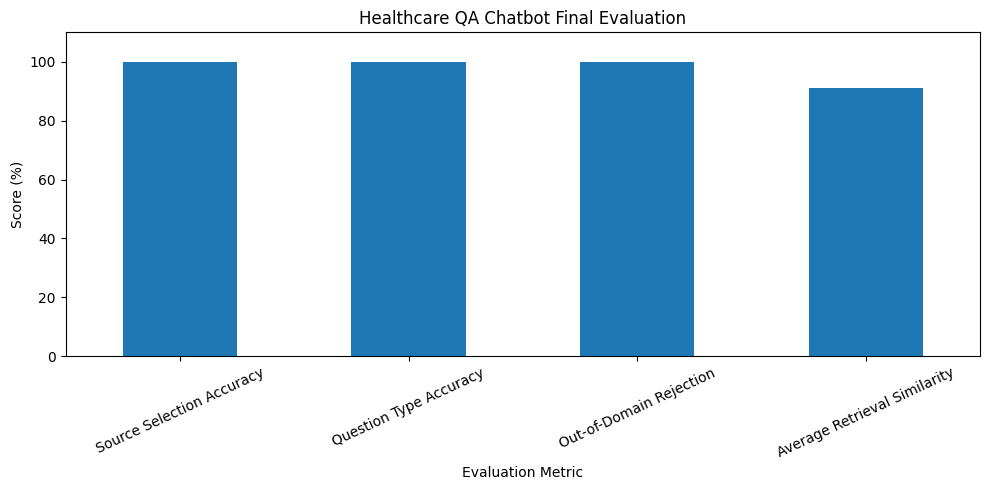

In [660]:
evaluation_summary.plot(
    x="Metric",
    y="Score",
    kind="bar",
    figsize=(10, 5),
    legend=False
)

plt.title("Healthcare QA Chatbot Final Evaluation")
plt.xlabel("Evaluation Metric")
plt.ylabel("Score (%)")
plt.xticks(rotation=25)
plt.ylim(0, 110)
plt.tight_layout()
plt.show()

In [662]:
current_topic = None

print("=" * 70)
print("       HEALTHCARE QA CHATBOT")
print("=" * 70)
print("Ask a healthcare question.")
print("Type 'exit' to end the conversation.")
print("=" * 70)

while True:

    question = input("\nYou: ")

    if question.lower().strip() == "exit":
        print("\nBot: Thank you. Goodbye!")
        break

    result = healthcare_chat(
        question,
        current_topic
    )

    print("\nBot:", result["answer"])
    print("Source:", result["source"])

    current_topic = result.get(
        "current_topic",
        current_topic
    )

       HEALTHCARE QA CHATBOT
Ask a healthcare question.
Type 'exit' to end the conversation.



You:  What are the symptoms of malaria?



Bot: fever, chills, sweating, headache, nausea, vomiting, muscle pain
Source: Structured Knowledge Base



You:  I have a headache



Bot: Not all headaches require medical attention. But some types of headache are signals of more serious disorders and call for prompt medical care. These include: sudden, severe headache or sudden headache associated with a stiff neck; headaches associated with fever, convulsions, or accompanied by confusion or loss of consciousness; headaches following a blow to the head, or associated with pain in the eye or ear; persistent headache in a person who was previously headache free; and recurring headache in children. Migraine headaches may last a day or more and can strike as often as several times a week or as rarely as once every few years.
Source: MedQuAD Semantic IR



You:  What is anemia



Bot: Anemia is a medical condition marked by an insufficient mass of red blood cells or hemoglobin, reducing the blood's oxygen-carrying capacity.
Source: Medical Wikipedia



You:  exit



Bot: Thank you. Goodbye!


In [666]:
current_topic = None

print("=" * 70)
print("       HEALTHCARE QA CHATBOT")
print("=" * 70)
print("Ask a healthcare question.")
print("Type 'exit' to end the conversation.")
print("=" * 70)

while True:

    question = input("\nYou: ")

    if question.lower().strip() == "exit":
        print("\nBot: Thank you. Goodbye!")
        break

    result = healthcare_chat(
        question,
        current_topic
    )

    print("\nBot:", result["answer"])
    print("Source:", result["source"])
    print("Type:", result.get("question_type"))
    print("Current Topic:", result.get("current_topic"))

    current_topic = result.get(
        "current_topic",
        current_topic
    )

       HEALTHCARE QA CHATBOT
Ask a healthcare question.
Type 'exit' to end the conversation.



You:  What is anemia?



Bot: Anemia is a medical condition marked by an insufficient mass of red blood cells or hemoglobin, reducing the blood's oxygen-carrying capacity.
Source: Medical Wikipedia
Type: information
Current Topic: anemia



You:  Who is at risk for it?



Bot: People at highest risk for Marfan syndrome are those who have a family history of the condition. If you have Marfan syndrome, you have a 50 percent chance of passing the altered gene to each of your children.
                
Marfan syndrome affects about 1 out of every 5,000 people in the United States. Men, women, and children, and people of all races, can have the condition.
Source: MedQuAD Semantic IR
Type: susceptibility
Current Topic: anemia



You:  Who won the FIFA World Cup?



Bot: I'm sorry, I could not find a reliable answer to that question.
Source: No reliable source
Type: unknown
Current Topic: anemia



You:  exit



Bot: Thank you. Goodbye!


In [668]:
def healthcare_chat(question, current_topic=None):

    # --------------------------------------------------
    # 1. Dialogue handling
    # --------------------------------------------------

    dialogue_type = is_dialogue_input(question)

    if dialogue_type == "greeting":
        return {
            "answer": "Hello! I'm a healthcare QA assistant. Ask me a healthcare-related question.",
            "source": "Dialogue Manager",
            "question_type": "dialogue",
            "similarity": 1.0,
            "current_topic": current_topic
        }

    if dialogue_type == "thanks":
        return {
            "answer": "You're welcome!",
            "source": "Dialogue Manager",
            "question_type": "dialogue",
            "similarity": 1.0,
            "current_topic": current_topic
        }

    if dialogue_type == "exit":
        return {
            "answer": "Thank you. Goodbye!",
            "source": "Dialogue Manager",
            "question_type": "dialogue",
            "similarity": 1.0,
            "current_topic": None
        }


    # --------------------------------------------------
    # 2. Detect natural symptom statements
    # --------------------------------------------------

    if detect_symptom_statement(question):

        result = multi_source_qa(
            question,
            current_topic=None
        )

        result["question_type"] = "symptom_statement"
        result["current_topic"] = current_topic

        return result


    # --------------------------------------------------
    # 3. Detect explicitly mentioned disease
    # --------------------------------------------------

    detected_disease = detect_disease(question)


    # --------------------------------------------------
    # 4. Decide which topic to use
    # --------------------------------------------------

    topic_for_query = detected_disease

    if (
        topic_for_query is None
        and current_topic is not None
        and is_followup_question(question)
    ):
        topic_for_query = current_topic


    # --------------------------------------------------
    # 5. Handle follow-up questions using current topic
    # --------------------------------------------------

    if (
        current_topic is not None
        and is_followup_question(question)
        and detected_disease is None
    ):

        detected_type = detect_question_type(question)

        structured_result = structured_context_answer(
            question,
            current_topic,
            detected_type
        )

        if structured_result is not None:
            structured_result["current_topic"] = current_topic
            return structured_result


    # --------------------------------------------------
    # 6. General multi-source QA
    # --------------------------------------------------

    result = multi_source_qa(
        question,
        current_topic=topic_for_query
    )


    # --------------------------------------------------
    # 7. Update current topic
    # --------------------------------------------------

    if detected_disease is not None:

        new_topic = detected_disease

    elif (
        current_topic is not None
        and is_followup_question(question)
    ):

        new_topic = current_topic

    else:

        new_topic = current_topic


    result["current_topic"] = new_topic

    return result

In [670]:
current_topic = None

print(healthcare_chat("What is anemia?", current_topic))

result = healthcare_chat(
    "Who is at risk for it?",
    "anemia"
)

print(result)

{'answer': "Anemia is a medical condition marked by an insufficient mass of red blood cells or hemoglobin, reducing the blood's oxygen-carrying capacity.", 'source': 'Medical Wikipedia', 'question_type': 'information', 'similarity': 0.8413068652153015, 'current_topic': 'anemia'}
{'answer': 'People at highest risk for Marfan syndrome are those who have a family history of the condition. If you have Marfan syndrome, you have a 50 percent chance of passing the altered gene to each of your children.\n                \nMarfan syndrome affects about 1 out of every 5,000 people in the United States. Men, women, and children, and people of all races, can have the condition.', 'source': 'MedQuAD Semantic IR', 'question_type': 'susceptibility', 'similarity': 0.6322633028030396, 'current_topic': 'anemia'}


In [672]:
def structured_context_answer(
    question,
    disease,
    question_type
):

    if disease is None:
        return None

    # Map question types to knowledge-base columns
    column_map = {
        "symptoms": "symptoms",
        "causes": "causes",
        "susceptibility": "risk_factors",
        "prevention": "prevention",
        "treatment": "treatment"
    }

    column = column_map.get(question_type)

    if column is None:
        return None

    # Find the disease in the structured knowledge base
    matches = knowledge_base[
        knowledge_base["disease"]
        .astype(str)
        .str.lower()
        .str.strip()
        == disease.lower().strip()
    ]

    if len(matches) == 0:
        return None

    answer = matches.iloc[0][column]

    # Reject empty values
    if (
        answer is None
        or str(answer).strip() == ""
        or str(answer).lower() == "nan"
    ):
        return None

    return {
        "answer": str(answer),
        "source": "Structured Knowledge Base",
        "question_type": question_type,
        "similarity": 1.0
    }

In [674]:
print(
    structured_context_answer(
        "Who is at risk for it?",
        "anemia",
        "susceptibility"
    )
)

None


In [676]:
current_topic = None

result = healthcare_chat(
    "What is anemia?",
    current_topic
)

print(result)

current_topic = result["current_topic"]

result = healthcare_chat(
    "Who is at risk for it?",
    current_topic
)

print(result)

{'answer': "Anemia is a medical condition marked by an insufficient mass of red blood cells or hemoglobin, reducing the blood's oxygen-carrying capacity.", 'source': 'Medical Wikipedia', 'question_type': 'information', 'similarity': 0.8413068652153015, 'current_topic': 'anemia'}
{'answer': 'People at highest risk for Marfan syndrome are those who have a family history of the condition. If you have Marfan syndrome, you have a 50 percent chance of passing the altered gene to each of your children.\n                \nMarfan syndrome affects about 1 out of every 5,000 people in the United States. Men, women, and children, and people of all races, can have the condition.', 'source': 'MedQuAD Semantic IR', 'question_type': 'susceptibility', 'similarity': 0.6322633028030396, 'current_topic': 'anemia'}


In [678]:
print(type(knowledge_base))
print(knowledge_base.columns.tolist())
print(knowledge_base["disease"].astype(str).str.lower().unique())

<class 'pandas.core.frame.DataFrame'>
['disease', 'symptoms', 'causes', 'risk_factors', 'prevention', 'treatment']
['diabetes' 'malaria' 'dengue' 'asthma' 'tuberculosis' 'hypertension'
 'pneumonia']


In [680]:
print(
    knowledge_base[
        knowledge_base["disease"]
        .astype(str)
        .str.lower()
        .str.contains("anemia", na=False)
    ]
)

Empty DataFrame
Columns: [disease, symptoms, causes, risk_factors, prevention, treatment]
Index: []


In [682]:
print(type(knowledge_base))
print(knowledge_base.shape)
print(knowledge_base.head())

<class 'pandas.core.frame.DataFrame'>
(7, 6)
        disease                                           symptoms  \
0      diabetes  increased thirst, frequent urination, hunger, ...   
1       malaria  fever, chills, sweating, headache, nausea, vom...   
2        dengue  high fever, severe headache, muscle and joint ...   
3        asthma  wheezing, coughing, shortness of breath, chest...   
4  tuberculosis  persistent cough, chest pain, fever, night swe...   

                                              causes  \
0  problems with insulin production or insulin ac...   
1  infection with Plasmodium parasites transmitte...   
2  infection with dengue virus transmitted throug...   
3  airway inflammation and sensitivity to various...   
4  infection with Mycobacterium tuberculosis bact...   

                                        risk_factors  \
0  family history, overweight, physical inactivit...   
1  travel or residence in areas where malaria tra...   
2  living in or traveling to 

In [684]:
print(globals().keys())

dict_keys(['__name__', '__doc__', '__package__', '__loader__', '__spec__', '__builtin__', '__builtins__', '_ih', '_oh', '_dh', 'In', 'Out', 'get_ipython', 'exit', 'quit', 'open', '_', '__', '___', '__session__', '_i', '_ii', '_iii', '_i1', 'json', 'getpass', 'hashlib', 'import_pandas_safely', '__pandas', 'is_data_frame', 'dataframe_columns', 'dtypes_str', 'dataframe_hash', 'get_dataframes', '_1', '_i2', '_exit_code', '_i3', '_3', '_i4', 'pd', 'np', 're', 'nltk', 'TfidfVectorizer', 'cosine_similarity', 'plt', 'sns', '_i5', '_5', '_i6', '_6', '_i7', '_7', '_i8', '_i9', '_9', '_i10', 'stopwords', 'word_tokenize', 'WordNetLemmatizer', 'stop_words', 'lemmatizer', '_i11', '_11', '_i12', 'load_dataset', 'dataset', '_i13', '_13', '_i14', '_i15', '_15', '_i16', '_16', '_i17', '_17', '_i18', 'url', 'df', '_i19', '_19', '_i20', '_20', '_i21', '_21', '_i22', '_22', '_i23', '_23', '_i24', '_24', '_i25', '_25', '_i26', '_i27', '_27', '_i28', '_28', '_i29', '_29', '_i30', '_i31', '_31', '_i32', '_32'

In [686]:
print(type(_150))
print(_150.shape)
print(_150.head())

<class 'pandas.core.frame.DataFrame'>
(7, 6)
        disease                                           symptoms  \
0      diabetes  increased thirst, frequent urination, hunger, ...   
1       malaria  fever, chills, sweating, headache, nausea, vom...   
2        dengue  high fever, severe headache, muscle and joint ...   
3        asthma  wheezing, coughing, shortness of breath, chest...   
4  tuberculosis  persistent cough, chest pain, fever, night swe...   

                                              causes  \
0  problems with insulin production or insulin ac...   
1  infection with Plasmodium parasites transmitte...   
2  infection with dengue virus transmitted throug...   
3  airway inflammation and sensitivity to various...   
4  infection with Mycobacterium tuberculosis bact...   

                                        risk_factors  \
0  family history, overweight, physical inactivit...   
1  travel or residence in areas where malaria tra...   
2  living in or traveling to 

In [688]:
def structured_context_answer(question, disease, question_type):

    matches = _150[
        _150["disease"].str.lower() == disease.lower()
    ]

    if matches.empty:
        return None

    row = matches.iloc[0]

    column_map = {
        "symptoms": "symptoms",
        "causes": "causes",
        "susceptibility": "risk_factors",
        "prevention": "prevention",
        "treatment": "treatment"
    }

    column = column_map.get(question_type)

    if column is None:
        return None

    answer = row[column]

    return {
        "answer": answer,
        "source": "Structured Knowledge Base",
        "question_type": question_type,
        "similarity": 1.0
    }

In [690]:
print(
    structured_context_answer(
        "Who is at risk for it?",
        "anemia",
        "susceptibility"
    )
)

None


In [692]:
print(_150["disease"].tolist())

['diabetes', 'malaria', 'dengue', 'asthma', 'tuberculosis', 'hypertension', 'pneumonia']


In [694]:
def topic_filtered_semantic_qa(question, topic, top_k=5, threshold=0.45):

    if topic is None:
        return None

    query_embedding = semantic_model.encode(
        [question],
        normalize_embeddings=True
    )

    similarities = medquad_embeddings @ query_embedding[0]

    temp_df = retrieval_df.copy()
    temp_df["similarity"] = similarities

    topic = topic.lower()

    mask = (
        temp_df["question"].str.lower().str.contains(topic, na=False)
        |
        temp_df["answer"].str.lower().str.contains(topic, na=False)
    )

    filtered_df = temp_df[mask].copy()

    if filtered_df.empty:
        return None

    results = filtered_df.sort_values(
        "similarity",
        ascending=False
    ).head(top_k)

    results = results[
        results["similarity"] >= threshold
    ]

    if results.empty:
        return None

    best = results.iloc[0]

    return {
        "answer": best["answer"],
        "source": "MedQuAD Semantic IR",
        "question_type": best["question_type"],
        "similarity": float(best["similarity"])
    }

In [696]:
print(
    topic_filtered_semantic_qa(
        "Who is at risk for it?",
        "anemia"
    )
)

{'answer': 'People who are at highest risk for thrombocytopenia are those affected by one of the conditions or factors discussed in "What Causes Thrombocytopenia?" This includes people who:\n                \nHave certain types of cancer, aplastic anemia, or autoimmune diseases\n                \nAre exposed to certain toxic chemicals\n                \nHave a reaction to certain medicines\n                \nHave certain viruses\n                \nHave certain genetic conditions\n                \nPeople at highest risk also include heavy alcohol drinkers and pregnant women.', 'source': 'MedQuAD Semantic IR', 'question_type': 'susceptibility', 'similarity': 0.5436717867851257}


In [698]:
print(
    topic_filtered_semantic_qa(
        "What are the symptoms?",
        "anemia"
    )
)

{'answer': 'What are the signs and symptoms of Omenn syndrome? Infants with Omenn syndrome typically present shortly after birth, usually by 3 months of age. This is similar to other types of severe combined immunodeficiency (SCID). The characteristic skin findings (red and peeling skin), chronic diarrhea, and failure to thrive often precede the onset of infections. Life-threatening infections caused by common viral, bacterial, and fungal pathogens occur next. Lymphadenopathy and hepatosplenomegaly, both symptoms unique to Omenn syndrome, develop next. The Human Phenotype Ontology provides the following list of signs and symptoms for Omenn syndrome. If the information is available, the table below includes how often the symptom is seen in people with this condition. You can use the MedlinePlus Medical Dictionary to look up the definitions for these medical terms. Signs and Symptoms Approximate number of patients (when available) Alopecia 90% Hepatomegaly 90% Lymphadenopathy 90% Malabso

In [700]:
print(
    topic_filtered_semantic_qa(
        "What causes it?",
        "anemia"
    )
)

None


In [704]:
def structured_context_answer(question, disease, question_type):

    if disease is None:
        return None

    matches = _150[
        _150["disease"].astype(str).str.lower() == disease.lower()
    ]

    if matches.empty:
        return None

    row = matches.iloc[0]

    column_map = {
        "symptoms": "symptoms",
        "causes": "causes",
        "susceptibility": "risk_factors",
        "prevention": "prevention",
        "treatment": "treatment"
    }

    column = column_map.get(question_type)

    if column is None:
        return None

    answer = row[column]

    if answer is None or str(answer).strip() == "":
        return None

    return {
        "answer": str(answer),
        "source": "Structured Knowledge Base",
        "question_type": question_type,
        "similarity": 1.0
    }

In [706]:
def topic_filtered_semantic_qa(
    question,
    topic,
    top_k=5,
    threshold=0.45
):

    if topic is None:
        return None

    topic = str(topic).lower().strip()

    query_embedding = semantic_model.encode(
        [question],
        normalize_embeddings=True
    )

    similarities = medquad_embeddings @ query_embedding[0]

    temp_df = retrieval_df.copy()

    temp_df["similarity"] = similarities

    topic_mask = (
        temp_df["question"]
        .astype(str)
        .str.lower()
        .str.contains(topic, na=False)
        |
        temp_df["answer"]
        .astype(str)
        .str.lower()
        .str.contains(topic, na=False)
    )

    filtered_df = temp_df[topic_mask].copy()

    if filtered_df.empty:
        return None

    filtered_df = filtered_df.sort_values(
        "similarity",
        ascending=False
    )

    filtered_df = filtered_df.head(top_k)

    filtered_df = filtered_df[
        filtered_df["similarity"] >= threshold
    ]

    if filtered_df.empty:
        return None

    best = filtered_df.iloc[0]

    return {
        "answer": str(best["answer"]),
        "source": "MedQuAD Semantic IR",
        "question_type": str(best["question_type"]),
        "similarity": float(best["similarity"])
    }

In [708]:
def detect_symptom_statement(question):

    question = question.lower().strip()

    symptom_patterns = [
        "i have a ",
        "i have ",
        "i am feeling ",
        "i feel ",
        "i'm feeling ",
        "my head hurts",
        "my stomach hurts",
        "i'm experiencing ",
        "i am experiencing "
    ]

    return any(
        question.startswith(pattern)
        for pattern in symptom_patterns
    )

In [710]:
tests = [
    "I have a headache",
    "I am feeling dizzy",
    "I have a fever",
    "What are the symptoms of malaria?",
    "What is anemia?"
]

for q in tests:
    print(q, "->", detect_symptom_statement(q))

I have a headache -> True
I am feeling dizzy -> True
I have a fever -> True
What are the symptoms of malaria? -> False
What is anemia? -> False


In [712]:
def is_followup_question(question):

    question = question.lower().strip()

    followup_patterns = [
        "who is at risk for it",
        "who is at risk",
        "what causes it",
        "how can it be prevented",
        "how is it prevented",
        "what are the symptoms",
        "what are its symptoms",
        "what are the treatments",
        "how is it treated",
        "what is the treatment",
        "how is it diagnosed",
        "how do you diagnose it",
        "what about it",
        "tell me more about it"
    ]

    return any(
        pattern in question
        for pattern in followup_patterns
    )

In [714]:
def detect_disease(question):

    question_lower = question.lower()

    diseases = [
        "diabetes",
        "malaria",
        "dengue",
        "asthma",
        "tuberculosis",
        "hypertension",
        "pneumonia",
        "anemia",
        "headache",
        "dizziness"
    ]

    for disease in diseases:

        if disease in question_lower:
            return disease

    return None

In [716]:
def detect_question_type(question):

    q = question.lower().strip()

    if "symptom" in q or "signs" in q:
        return "symptoms"

    if "cause" in q or "caused" in q:
        return "causes"

    if (
        "risk" in q
        or "at risk" in q
        or "susceptible" in q
    ):
        return "susceptibility"

    if (
        "prevent" in q
        or "avoid" in q
    ):
        return "prevention"

    if (
        "treatment" in q
        or "treated" in q
        or "cure" in q
    ):
        return "treatment"

    if (
        "diagnos" in q
        or "test" in q
        or "exam" in q
    ):
        return "exams and tests"

    return "information"

In [718]:
def healthcare_chat(question, current_topic=None):

    question = question.strip()

    # ============================================================
    # 1. DIALOGUE HANDLING
    # ============================================================

    dialogue_type = is_dialogue_input(question)

    if dialogue_type == "greeting":

        return {
            "answer": "Hello! I'm a healthcare QA assistant. Ask me a healthcare-related question.",
            "source": "Dialogue Manager",
            "question_type": "dialogue",
            "similarity": 1.0,
            "current_topic": current_topic
        }

    if dialogue_type == "thanks":

        return {
            "answer": "You're welcome!",
            "source": "Dialogue Manager",
            "question_type": "dialogue",
            "similarity": 1.0,
            "current_topic": current_topic
        }

    if dialogue_type == "exit":

        return {
            "answer": "Thank you. Goodbye!",
            "source": "Dialogue Manager",
            "question_type": "dialogue",
            "similarity": 1.0,
            "current_topic": current_topic
        }


    # ============================================================
    # 2. DETECT DISEASE / TOPIC
    # ============================================================

    detected_disease = detect_disease(question)

    detected_type = detect_question_type(question)


    # ============================================================
    # 3. SYMPTOM STATEMENT
    # ============================================================

    if detect_symptom_statement(question):

        result = multi_source_qa(
            question,
            current_topic=None
        )

        result["question_type"] = "symptom_statement"
        result["current_topic"] = current_topic

        return result


    # ============================================================
    # 4. DETERMINE TOPIC FOR QUERY
    # ============================================================

    if detected_disease is not None:

        topic_for_query = detected_disease

    else:

        topic_for_query = current_topic


    # ============================================================
    # 5. FOLLOW-UP QUESTION
    # ============================================================

    if (
        current_topic is not None
        and is_followup_question(question)
        and detected_disease is None
    ):

        # --------------------------------------------------------
        # 5A. Try Structured Knowledge Base
        # --------------------------------------------------------

        structured_result = structured_context_answer(
            question,
            current_topic,
            detected_type
        )

        if structured_result is not None:

            structured_result["current_topic"] = current_topic

            return structured_result


        # --------------------------------------------------------
        # 5B. Structured KB does not contain this disease
        #     Use topic-filtered MedQuAD
        # --------------------------------------------------------

        semantic_result = topic_filtered_semantic_qa(
            question,
            current_topic,
            top_k=5,
            threshold=0.45
        )

        if semantic_result is not None:

            semantic_result["question_type"] = detected_type
            semantic_result["current_topic"] = current_topic

            return semantic_result


    # ============================================================
    # 6. GENERAL MULTI-SOURCE QA
    # ============================================================

    result = multi_source_qa(
        question,
        current_topic=topic_for_query
    )


    # ============================================================
    # 7. UPDATE CURRENT TOPIC
    # ============================================================

    if detected_disease is not None:

        result["current_topic"] = detected_disease

    else:

        result["current_topic"] = current_topic


    return result

In [720]:
current_topic = None

result = healthcare_chat(
    "What is anemia?",
    current_topic
)

print(result)

current_topic = result["current_topic"]

result = healthcare_chat(
    "Who is at risk for it?",
    current_topic
)

print(result)

{'answer': "Anemia is a medical condition marked by an insufficient mass of red blood cells or hemoglobin, reducing the blood's oxygen-carrying capacity.", 'source': 'Medical Wikipedia', 'question_type': 'information', 'similarity': 0.8413068652153015, 'current_topic': 'anemia'}
{'answer': 'People who are at highest risk for thrombocytopenia are those affected by one of the conditions or factors discussed in "What Causes Thrombocytopenia?" This includes people who:\n                \nHave certain types of cancer, aplastic anemia, or autoimmune diseases\n                \nAre exposed to certain toxic chemicals\n                \nHave a reaction to certain medicines\n                \nHave certain viruses\n                \nHave certain genetic conditions\n                \nPeople at highest risk also include heavy alcohol drinkers and pregnant women.', 'source': 'MedQuAD Semantic IR', 'question_type': 'susceptibility', 'similarity': 0.5436717867851257, 'current_topic': 'anemia'}


In [722]:
current_topic = None

questions = [
    "What are the symptoms of malaria?",
    "Who is at risk for it?",
    "How can it be prevented?",
    "What causes it?"
]

for question in questions:

    result = healthcare_chat(
        question,
        current_topic
    )

    print("=" * 80)
    print("USER:", question)
    print("BOT:", result["answer"])
    print("SOURCE:", result["source"])
    print("TYPE:", result["question_type"])
    print("CURRENT TOPIC:", result["current_topic"])

    current_topic = result["current_topic"]

USER: What are the symptoms of malaria?
BOT: fever, chills, sweating, headache, nausea, vomiting, muscle pain
SOURCE: Structured Knowledge Base
TYPE: symptoms
CURRENT TOPIC: malaria
USER: Who is at risk for it?
BOT: travel or residence in areas where malaria transmission occurs
SOURCE: Structured Knowledge Base
TYPE: susceptibility
CURRENT TOPIC: malaria
USER: How can it be prevented?
BOT: prevent mosquito bites, use insect repellent, and use mosquito nets in risk areas
SOURCE: Structured Knowledge Base
TYPE: prevention
CURRENT TOPIC: malaria
USER: What causes it?
BOT: infection with Plasmodium parasites transmitted through infected mosquitoes
SOURCE: Structured Knowledge Base
TYPE: causes
CURRENT TOPIC: malaria


In [724]:
current_topic = None

questions = [
    "I have a headache",
    "I am feeling dizzy",
    "I have a fever"
]

for question in questions:

    result = healthcare_chat(
        question,
        current_topic
    )

    print("=" * 80)
    print("USER:", question)
    print("BOT:", result["answer"])
    print("SOURCE:", result["source"])
    print("TYPE:", result["question_type"])

USER: I have a headache
BOT: Not all headaches require medical attention. But some types of headache are signals of more serious disorders and call for prompt medical care. These include: sudden, severe headache or sudden headache associated with a stiff neck; headaches associated with fever, convulsions, or accompanied by confusion or loss of consciousness; headaches following a blow to the head, or associated with pain in the eye or ear; persistent headache in a person who was previously headache free; and recurring headache in children. Migraine headaches may last a day or more and can strike as often as several times a week or as rarely as once every few years.
SOURCE: MedQuAD Semantic IR
TYPE: symptom_statement
USER: I am feeling dizzy
BOT: When you're dizzy, you may feel lightheaded or lose your balance. If you feel that the room is spinning, you have vertigo.    A sudden drop in blood pressure or being dehydrated can make you dizzy. Many people feel lightheaded if they get up to

In [726]:
current_topic = None

questions = [
    "Who won the FIFA World Cup?",
    "What is the capital of France?",
    "Tell me about quantum computing",
    "cccccccccc"
]

for question in questions:

    result = healthcare_chat(
        question,
        current_topic
    )

    print("=" * 80)
    print("USER:", question)
    print("BOT:", result["answer"])
    print("SOURCE:", result["source"])
    print("TYPE:", result["question_type"])

USER: Who won the FIFA World Cup?
BOT: I'm sorry, I could not find a reliable answer to that question.
SOURCE: No reliable source
TYPE: unknown
USER: What is the capital of France?
BOT: I'm sorry, I could not find a reliable answer to that question.
SOURCE: No reliable source
TYPE: unknown
USER: Tell me about quantum computing
BOT: Quantum teleportation was achieved, enabling the transfer of quantum states between particles without physical transmission of the particles themselves.
SOURCE: Medical Wikipedia
TYPE: information
USER: cccccccccc
BOT: I'm sorry, I could not find a reliable answer to that question.
SOURCE: No reliable source
TYPE: unknown


In [728]:
current_topic = None

print("=" * 70)
print("       HEALTHCARE QA CHATBOT")
print("=" * 70)
print("Ask a healthcare question.")
print("Type 'exit' to end the conversation.")
print("=" * 70)

while True:

    question = input("\nYou: ").strip()

    if question.lower() == "exit":

        result = healthcare_chat(
            question,
            current_topic
        )

        print("\nBot:", result["answer"])
        print("Source:", result["source"])
        print("Type:", result["question_type"])

        break

    result = healthcare_chat(
        question,
        current_topic
    )

    print("\nBot:", result["answer"])
    print("Source:", result["source"])
    print("Type:", result["question_type"])
    print("Current Topic:", result["current_topic"])

    current_topic = result["current_topic"]

       HEALTHCARE QA CHATBOT
Ask a healthcare question.
Type 'exit' to end the conversation.



You:  What is anemia?



Bot: Anemia is a medical condition marked by an insufficient mass of red blood cells or hemoglobin, reducing the blood's oxygen-carrying capacity.
Source: Medical Wikipedia
Type: information
Current Topic: anemia



You:  Who is at risk for it?



Bot: People who are at highest risk for thrombocytopenia are those affected by one of the conditions or factors discussed in "What Causes Thrombocytopenia?" This includes people who:
                
Have certain types of cancer, aplastic anemia, or autoimmune diseases
                
Are exposed to certain toxic chemicals
                
Have a reaction to certain medicines
                
Have certain viruses
                
Have certain genetic conditions
                
People at highest risk also include heavy alcohol drinkers and pregnant women.
Source: MedQuAD Semantic IR
Type: susceptibility
Current Topic: anemia



You:  I have a headache



Bot: Not all headaches require medical attention. But some types of headache are signals of more serious disorders and call for prompt medical care. These include: sudden, severe headache or sudden headache associated with a stiff neck; headaches associated with fever, convulsions, or accompanied by confusion or loss of consciousness; headaches following a blow to the head, or associated with pain in the eye or ear; persistent headache in a person who was previously headache free; and recurring headache in children. Migraine headaches may last a day or more and can strike as often as several times a week or as rarely as once every few years.
Source: MedQuAD Semantic IR
Type: symptom_statement
Current Topic: anemia



You:  exit



Bot: Thank you. Goodbye!
Source: Dialogue Manager
Type: dialogue


In [730]:
def topic_filtered_semantic_qa(
    question,
    topic,
    top_k=5,
    threshold=0.45
):

    if topic is None:
        return None

    topic = str(topic).lower().strip()

    query_embedding = semantic_model.encode(
        [question],
        normalize_embeddings=True
    )

    similarities = medquad_embeddings @ query_embedding[0]

    temp_df = retrieval_df.copy()

    temp_df["similarity"] = similarities

    # --------------------------------------------------
    # IMPORTANT:
    # Only keep MedQuAD QUESTIONS that are about the
    # current topic.
    #
    # Do NOT search the answer text for the topic,
    # because unrelated diseases may mention it.
    # --------------------------------------------------

    question_mask = (
        temp_df["question"]
        .astype(str)
        .str.lower()
        .str.contains(topic, na=False)
    )

    filtered_df = temp_df[question_mask].copy()

    if filtered_df.empty:
        return None

    # Rank only topic-specific questions
    filtered_df = filtered_df.sort_values(
        "similarity",
        ascending=False
    )

    filtered_df = filtered_df.head(top_k)

    filtered_df = filtered_df[
        filtered_df["similarity"] >= threshold
    ]

    if filtered_df.empty:
        return None

    best = filtered_df.iloc[0]

    return {
        "answer": str(best["answer"]),
        "source": "MedQuAD Semantic IR",
        "question_type": str(best["question_type"]),
        "similarity": float(best["similarity"])
    }

In [732]:
print(
    topic_filtered_semantic_qa(
        "Who is at risk for it?",
        "anemia"
    )
)

{'answer': 'Aplastic anemia is a rare but serious blood disorder. People of all ages can develop aplastic anemia. However, it\'s most common in adolescents, young adults, and the elderly. Men and women are equally likely to have it.\n                \nThe disorder is two to three times more common in Asian countries.\n                \nYour risk of aplastic anemia is higher if you:\n                \nHave been exposed to toxins\n                \nHave taken certain medicines or had radiation or chemotherapy (treatments for cancer)\n                \nHave certain infectious diseases, autoimmune disorders, or inherited conditions\n                \nFor more information, go to "What Causes Aplastic Anemia?"', 'source': 'MedQuAD Semantic IR', 'question_type': 'susceptibility', 'similarity': 0.48015010356903076}


In [734]:
print(
    topic_filtered_semantic_qa(
        "What are the symptoms?",
        "anemia"
    )
)

{'answer': 'What are the symptoms of sideroblastic anemia? The symptoms of sideroblastic anemia are the same as for any anemia and iron overload. These may include fatigue, weakness, palpitations, shortness of breath, headaches, irritability, and chest pain. Physical findings may include pallor, tachycardia, hepatosplenomegaly, S3 gallop, jugular vein distension, and rales.', 'source': 'MedQuAD Semantic IR', 'question_type': 'symptoms', 'similarity': 0.4594743251800537}


In [736]:
print(
    topic_filtered_semantic_qa(
        "How is it treated?",
        "anemia"
    )
)

None


In [738]:
def handle_topic_followup(question, current_topic):

    if current_topic is None:
        return None

    detected_type = detect_question_type(question)

    # --------------------------------------------------
    # First: Structured Knowledge Base
    # --------------------------------------------------

    structured_result = structured_context_answer(
        question,
        current_topic,
        detected_type
    )

    if structured_result is not None:

        structured_result["current_topic"] = current_topic

        return structured_result

    # --------------------------------------------------
    # Second: Topic-filtered MedQuAD
    # --------------------------------------------------

    semantic_result = topic_filtered_semantic_qa(
        question,
        current_topic,
        top_k=5,
        threshold=0.45
    )

    if semantic_result is not None:

        semantic_result["question_type"] = detected_type
        semantic_result["current_topic"] = current_topic

        return semantic_result

    return None

In [740]:
def healthcare_chat(question, current_topic=None):

    question = question.strip()

    # ============================================================
    # 1. DIALOGUE
    # ============================================================

    dialogue_type = is_dialogue_input(question)

    if dialogue_type == "greeting":

        return {
            "answer": "Hello! I'm a healthcare QA assistant. Ask me a healthcare-related question.",
            "source": "Dialogue Manager",
            "question_type": "dialogue",
            "similarity": 1.0,
            "current_topic": current_topic
        }

    if dialogue_type == "thanks":

        return {
            "answer": "You're welcome!",
            "source": "Dialogue Manager",
            "question_type": "dialogue",
            "similarity": 1.0,
            "current_topic": current_topic
        }

    if dialogue_type == "exit":

        return {
            "answer": "Thank you. Goodbye!",
            "source": "Dialogue Manager",
            "question_type": "dialogue",
            "similarity": 1.0,
            "current_topic": current_topic
        }


    # ============================================================
    # 2. DETECT DISEASE
    # ============================================================

    detected_disease = detect_disease(question)

    detected_type = detect_question_type(question)


    # ============================================================
    # 3. PATIENT SYMPTOM STATEMENT
    # ============================================================

    if detect_symptom_statement(question):

        result = multi_source_qa(
            question,
            current_topic=None
        )

        result["question_type"] = "symptom_statement"
        result["current_topic"] = current_topic

        return result


    # ============================================================
    # 4. DETERMINE TOPIC
    # ============================================================

    if detected_disease is not None:

        topic_for_query = detected_disease

    else:

        topic_for_query = current_topic


    # ============================================================
    # 5. FOLLOW-UP QUESTION
    # ============================================================

    if (
        current_topic is not None
        and is_followup_question(question)
        and detected_disease is None
    ):

        followup_result = handle_topic_followup(
            question,
            current_topic
        )

        if followup_result is not None:

            return followup_result


    # ============================================================
    # 6. GENERAL MULTI-SOURCE QA
    # ============================================================

    result = multi_source_qa(
        question,
        current_topic=topic_for_query
    )


    # ============================================================
    # 7. UPDATE TOPIC
    # ============================================================

    if detected_disease is not None:

        result["current_topic"] = detected_disease

    else:

        result["current_topic"] = current_topic


    return result

In [742]:
current_topic = None

result = healthcare_chat(
    "What is anemia?",
    current_topic
)

print(result)

current_topic = result["current_topic"]

result = healthcare_chat(
    "Who is at risk for it?",
    current_topic
)

print(result)

{'answer': "Anemia is a medical condition marked by an insufficient mass of red blood cells or hemoglobin, reducing the blood's oxygen-carrying capacity.", 'source': 'Medical Wikipedia', 'question_type': 'information', 'similarity': 0.8413068652153015, 'current_topic': 'anemia'}
{'answer': 'Aplastic anemia is a rare but serious blood disorder. People of all ages can develop aplastic anemia. However, it\'s most common in adolescents, young adults, and the elderly. Men and women are equally likely to have it.\n                \nThe disorder is two to three times more common in Asian countries.\n                \nYour risk of aplastic anemia is higher if you:\n                \nHave been exposed to toxins\n                \nHave taken certain medicines or had radiation or chemotherapy (treatments for cancer)\n                \nHave certain infectious diseases, autoimmune disorders, or inherited conditions\n                \nFor more information, go to "What Causes Aplastic Anemia?"', 'sou

In [744]:
current_topic = None

questions = [
    "What is anemia?",
    "Who is at risk for it?",
    "I have a headache",
    "What are the symptoms of malaria?",
    "Who is at risk for it?",
    "How can it be prevented?",
    "What causes it?",
    "Who won the FIFA World Cup?"
]

for question in questions:

    result = healthcare_chat(
        question,
        current_topic
    )

    print("=" * 80)
    print("USER:", question)
    print("BOT:", result["answer"])
    print("SOURCE:", result["source"])
    print("TYPE:", result["question_type"])
    print("CURRENT TOPIC:", result["current_topic"])

    current_topic = result["current_topic"]

USER: What is anemia?
BOT: Anemia is a medical condition marked by an insufficient mass of red blood cells or hemoglobin, reducing the blood's oxygen-carrying capacity.
SOURCE: Medical Wikipedia
TYPE: information
CURRENT TOPIC: anemia
USER: Who is at risk for it?
BOT: Aplastic anemia is a rare but serious blood disorder. People of all ages can develop aplastic anemia. However, it's most common in adolescents, young adults, and the elderly. Men and women are equally likely to have it.
                
The disorder is two to three times more common in Asian countries.
                
Your risk of aplastic anemia is higher if you:
                
Have been exposed to toxins
                
Have taken certain medicines or had radiation or chemotherapy (treatments for cancer)
                
Have certain infectious diseases, autoimmune disorders, or inherited conditions
                
For more information, go to "What Causes Aplastic Anemia?"
SOURCE: MedQuAD Semantic IR
TYPE: suscepti

In [746]:
import re

def topic_filtered_semantic_qa(
    question,
    topic,
    top_k=5,
    threshold=0.45
):

    if topic is None:
        return None

    topic = str(topic).lower().strip()

    query_embedding = semantic_model.encode(
        [question],
        normalize_embeddings=True
    )

    similarities = medquad_embeddings @ query_embedding[0]

    temp_df = retrieval_df.copy()

    temp_df["similarity"] = similarities

    # --------------------------------------------------
    # Find questions that contain the topic
    # --------------------------------------------------

    pattern = r"\b" + re.escape(topic) + r"\b"

    topic_mask = (
        temp_df["question"]
        .astype(str)
        .str.lower()
        .str.contains(pattern, regex=True, na=False)
    )

    filtered_df = temp_df[topic_mask].copy()

    if filtered_df.empty:
        return None

    # --------------------------------------------------
    # Remove questions about a DIFFERENT disease
    # that merely contains the current topic name.
    #
    # Example:
    # "What is Aplastic Anemia?"
    #
    # Current topic = "anemia"
    #
    # This must NOT be considered an anemia answer.
    # --------------------------------------------------

    def is_exact_topic_question(text):

        text = str(text).lower().strip()

        # Remove the current topic from the question
        remaining = re.sub(
            pattern,
            "",
            text
        )

        # Disease modifiers that create a different condition
        disease_modifiers = [
            "aplastic",
            "sickle cell",
            "sickle-cell",
            "iron deficiency",
            "iron-deficiency",
            "hemolytic",
            "pernicious",
            "megaloblastic",
            "macrocytic",
            "microcytic",
            "autoimmune",
            "congenital",
            "acquired",
            "fanconi"
        ]

        for modifier in disease_modifiers:

            if modifier in remaining:
                return False

        return True

    filtered_df = filtered_df[
        filtered_df["question"].apply(is_exact_topic_question)
    ]

    if filtered_df.empty:
        return None

    # --------------------------------------------------
    # Rank the remaining results
    # --------------------------------------------------

    filtered_df = filtered_df.sort_values(
        "similarity",
        ascending=False
    )

    filtered_df = filtered_df.head(top_k)

    filtered_df = filtered_df[
        filtered_df["similarity"] >= threshold
    ]

    if filtered_df.empty:
        return None

    best = filtered_df.iloc[0]

    return {
        "answer": str(best["answer"]),
        "source": "MedQuAD Semantic IR",
        "question_type": str(best["question_type"]),
        "similarity": float(best["similarity"])
    }

In [748]:
print(
    topic_filtered_semantic_qa(
        "Who is at risk for it?",
        "anemia"
    )
)

None


In [750]:
tests = [
    ("Who is at risk for it?", "anemia"),
    ("What are the symptoms?", "anemia"),
    ("What causes it?", "anemia"),
    ("How is it treated?", "anemia")
]

for question, topic in tests:

    result = topic_filtered_semantic_qa(
        question,
        topic
    )

    print("=" * 70)
    print("QUESTION:", question)
    print("TOPIC:", topic)
    print("RESULT:", result)

QUESTION: Who is at risk for it?
TOPIC: anemia
RESULT: None
QUESTION: What are the symptoms?
TOPIC: anemia
RESULT: {'answer': 'What are the symptoms of sideroblastic anemia? The symptoms of sideroblastic anemia are the same as for any anemia and iron overload. These may include fatigue, weakness, palpitations, shortness of breath, headaches, irritability, and chest pain. Physical findings may include pallor, tachycardia, hepatosplenomegaly, S3 gallop, jugular vein distension, and rales.', 'source': 'MedQuAD Semantic IR', 'question_type': 'symptoms', 'similarity': 0.4594743251800537}
QUESTION: What causes it?
TOPIC: anemia
RESULT: None
QUESTION: How is it treated?
TOPIC: anemia
RESULT: None


In [752]:
tests = [
    ("Who is at risk for it?", "malaria"),
    ("How can it be prevented?", "malaria"),
    ("What causes it?", "malaria"),
    ("What are the symptoms?", "malaria")
]

for question, topic in tests:

    result = topic_filtered_semantic_qa(
        question,
        topic
    )

    print("=" * 70)
    print("QUESTION:", question)
    print("TOPIC:", topic)
    print("RESULT:", result)

QUESTION: Who is at risk for it?
TOPIC: malaria
RESULT: None
QUESTION: How can it be prevented?
TOPIC: malaria
RESULT: None
QUESTION: What causes it?
TOPIC: malaria
RESULT: None
QUESTION: What are the symptoms?
TOPIC: malaria
RESULT: None


In [754]:
def healthcare_chat(question, current_topic=None):

    question = question.strip()

    # ============================================================
    # 1. DIALOGUE
    # ============================================================

    dialogue_type = is_dialogue_input(question)

    if dialogue_type == "greeting":

        return {
            "answer": "Hello! I'm a healthcare QA assistant. Ask me a healthcare-related question.",
            "source": "Dialogue Manager",
            "question_type": "dialogue",
            "similarity": 1.0,
            "current_topic": current_topic
        }

    if dialogue_type == "thanks":

        return {
            "answer": "You're welcome!",
            "source": "Dialogue Manager",
            "question_type": "dialogue",
            "similarity": 1.0,
            "current_topic": current_topic
        }

    if dialogue_type == "exit":

        return {
            "answer": "Thank you. Goodbye!",
            "source": "Dialogue Manager",
            "question_type": "dialogue",
            "similarity": 1.0,
            "current_topic": current_topic
        }


    # ============================================================
    # 2. DETECT DISEASE AND QUESTION TYPE
    # ============================================================

    detected_disease = detect_disease(question)

    detected_type = detect_question_type(question)


    # ============================================================
    # 3. PATIENT SYMPTOM STATEMENT
    # ============================================================

    if detect_symptom_statement(question):

        result = multi_source_qa(
            question,
            current_topic=None
        )

        result["question_type"] = "symptom_statement"
        result["current_topic"] = current_topic

        return result


    # ============================================================
    # 4. DETERMINE TOPIC
    # ============================================================

    if detected_disease is not None:

        topic_for_query = detected_disease

    else:

        topic_for_query = current_topic


    # ============================================================
    # 5. FOLLOW-UP QUESTION
    # ============================================================

    if (
        current_topic is not None
        and is_followup_question(question)
        and detected_disease is None
    ):

        followup_result = handle_topic_followup(
            question,
            current_topic
        )

        if followup_result is not None:

            return followup_result


    # ============================================================
    # 6. GENERAL MULTI-SOURCE QA
    # ============================================================

    result = multi_source_qa(
        question,
        current_topic=topic_for_query
    )


    # ============================================================
    # 7. UPDATE CURRENT TOPIC
    # ============================================================

    if detected_disease is not None:

        result["current_topic"] = detected_disease

    else:

        result["current_topic"] = current_topic


    return result

In [756]:
current_topic = None

questions = [
    "What is anemia?",
    "Who is at risk for it?",
    "I have a headache",
    "What are the symptoms of malaria?",
    "Who is at risk for it?",
    "How can it be prevented?",
    "What causes it?",
    "Who won the FIFA World Cup?"
]

for question in questions:

    result = healthcare_chat(
        question,
        current_topic
    )

    print("=" * 80)
    print("USER:", question)
    print("BOT:", result["answer"])
    print("SOURCE:", result["source"])
    print("TYPE:", result["question_type"])
    print("CURRENT TOPIC:", result["current_topic"])

    current_topic = result["current_topic"]

USER: What is anemia?
BOT: Anemia is a medical condition marked by an insufficient mass of red blood cells or hemoglobin, reducing the blood's oxygen-carrying capacity.
SOURCE: Medical Wikipedia
TYPE: information
CURRENT TOPIC: anemia
USER: Who is at risk for it?
BOT: People at highest risk for Marfan syndrome are those who have a family history of the condition. If you have Marfan syndrome, you have a 50 percent chance of passing the altered gene to each of your children.
                
Marfan syndrome affects about 1 out of every 5,000 people in the United States. Men, women, and children, and people of all races, can have the condition.
SOURCE: MedQuAD Semantic IR
TYPE: susceptibility
CURRENT TOPIC: anemia
USER: I have a headache
BOT: Not all headaches require medical attention. But some types of headache are signals of more serious disorders and call for prompt medical care. These include: sudden, severe headache or sudden headache associated with a stiff neck; headaches associat

In [758]:
def handle_topic_followup(question, current_topic):

    if current_topic is None:
        return None

    detected_type = detect_question_type(question)

    # ============================================================
    # 1. TRY STRUCTURED KNOWLEDGE BASE
    # ============================================================

    structured_result = structured_context_answer(
        question,
        current_topic,
        detected_type
    )

    if structured_result is not None:

        structured_result["current_topic"] = current_topic

        return structured_result


    # ============================================================
    # 2. TRY TOPIC-FILTERED MEDQUAD
    # ============================================================

    semantic_result = topic_filtered_semantic_qa(
        question,
        current_topic,
        top_k=5,
        threshold=0.45
    )

    if semantic_result is not None:

        semantic_result["question_type"] = detected_type
        semantic_result["current_topic"] = current_topic

        return semantic_result


    # ============================================================
    # 3. NO TOPIC-SPECIFIC ANSWER
    #
    # IMPORTANT:
    # DO NOT fall back to unrestricted semantic search.
    # ============================================================

    return {
        "answer": (
            "I'm sorry, I could not find a reliable answer "
            "about " + str(current_topic) + "."
        ),
        "source": "No reliable source",
        "question_type": detected_type,
        "similarity": 0.0,
        "current_topic": current_topic
    }

In [760]:
def healthcare_chat(question, current_topic=None):

    question = question.strip()


    # ============================================================
    # 1. DIALOGUE HANDLING
    # ============================================================

    dialogue_type = is_dialogue_input(question)

    if dialogue_type == "greeting":

        return {
            "answer": (
                "Hello! I'm a healthcare QA assistant. "
                "Ask me a healthcare-related question."
            ),
            "source": "Dialogue Manager",
            "question_type": "dialogue",
            "similarity": 1.0,
            "current_topic": current_topic
        }


    if dialogue_type == "thanks":

        return {
            "answer": "You're welcome!",
            "source": "Dialogue Manager",
            "question_type": "dialogue",
            "similarity": 1.0,
            "current_topic": current_topic
        }


    if dialogue_type == "exit":

        return {
            "answer": "Thank you. Goodbye!",
            "source": "Dialogue Manager",
            "question_type": "dialogue",
            "similarity": 1.0,
            "current_topic": None
        }


    # ============================================================
    # 2. DETECT DISEASE AND QUESTION TYPE
    # ============================================================

    detected_disease = detect_disease(question)

    detected_type = detect_question_type(question)


    # ============================================================
    # 3. PATIENT SYMPTOM STATEMENT
    # ============================================================

    if detect_symptom_statement(question):

        result = multi_source_qa(
            question,
            current_topic=None
        )

        result["question_type"] = "symptom_statement"

        result["current_topic"] = current_topic

        return result


    # ============================================================
    # 4. EXPLICIT NEW DISEASE
    # ============================================================

    if detected_disease is not None:

        topic_for_query = detected_disease

    else:

        topic_for_query = current_topic


    # ============================================================
    # 5. FOLLOW-UP QUESTION
    # ============================================================

    if (
        current_topic is not None
        and detected_disease is None
        and is_followup_question(question)
    ):

        followup_result = handle_topic_followup(
            question,
            current_topic
        )

        return followup_result


    # ============================================================
    # 6. GENERAL MULTI-SOURCE QA
    # ============================================================

    result = multi_source_qa(
        question,
        current_topic=topic_for_query
    )


    # ============================================================
    # 7. UPDATE CURRENT TOPIC
    # ============================================================

    if detected_disease is not None:

        result["current_topic"] = detected_disease

    else:

        result["current_topic"] = current_topic


    return result

In [762]:
current_topic = None

result = healthcare_chat(
    "What is anemia?",
    current_topic
)

print(result)

current_topic = result["current_topic"]

result = healthcare_chat(
    "Who is at risk for it?",
    current_topic
)

print(result)

{'answer': "Anemia is a medical condition marked by an insufficient mass of red blood cells or hemoglobin, reducing the blood's oxygen-carrying capacity.", 'source': 'Medical Wikipedia', 'question_type': 'information', 'similarity': 0.8413068652153015, 'current_topic': 'anemia'}
{'answer': "I'm sorry, I could not find a reliable answer about anemia.", 'source': 'No reliable source', 'question_type': 'susceptibility', 'similarity': 0.0, 'current_topic': 'anemia'}


In [764]:
current_topic = None

questions = [
    "What are the symptoms of malaria?",
    "Who is at risk for it?",
    "How can it be prevented?",
    "What causes it?"
]

for question in questions:

    result = healthcare_chat(
        question,
        current_topic
    )

    print("=" * 80)
    print("USER:", question)
    print("BOT:", result["answer"])
    print("SOURCE:", result["source"])
    print("TYPE:", result["question_type"])
    print("CURRENT TOPIC:", result["current_topic"])

    current_topic = result["current_topic"]

USER: What are the symptoms of malaria?
BOT: fever, chills, sweating, headache, nausea, vomiting, muscle pain
SOURCE: Structured Knowledge Base
TYPE: symptoms
CURRENT TOPIC: malaria
USER: Who is at risk for it?
BOT: travel or residence in areas where malaria transmission occurs
SOURCE: Structured Knowledge Base
TYPE: susceptibility
CURRENT TOPIC: malaria
USER: How can it be prevented?
BOT: prevent mosquito bites, use insect repellent, and use mosquito nets in risk areas
SOURCE: Structured Knowledge Base
TYPE: prevention
CURRENT TOPIC: malaria
USER: What causes it?
BOT: infection with Plasmodium parasites transmitted through infected mosquitoes
SOURCE: Structured Knowledge Base
TYPE: causes
CURRENT TOPIC: malaria


In [766]:
current_topic = None

questions = [
    "I have a headache",
    "I am feeling dizzy"
]

for question in questions:

    result = healthcare_chat(
        question,
        current_topic
    )

    print("=" * 80)
    print("USER:", question)
    print("BOT:", result["answer"])
    print("SOURCE:", result["source"])
    print("TYPE:", result["question_type"])

USER: I have a headache
BOT: Not all headaches require medical attention. But some types of headache are signals of more serious disorders and call for prompt medical care. These include: sudden, severe headache or sudden headache associated with a stiff neck; headaches associated with fever, convulsions, or accompanied by confusion or loss of consciousness; headaches following a blow to the head, or associated with pain in the eye or ear; persistent headache in a person who was previously headache free; and recurring headache in children. Migraine headaches may last a day or more and can strike as often as several times a week or as rarely as once every few years.
SOURCE: MedQuAD Semantic IR
TYPE: symptom_statement
USER: I am feeling dizzy
BOT: When you're dizzy, you may feel lightheaded or lose your balance. If you feel that the room is spinning, you have vertigo.    A sudden drop in blood pressure or being dehydrated can make you dizzy. Many people feel lightheaded if they get up to

In [768]:
current_topic = None

result = healthcare_chat(
    "What is anemia?",
    current_topic
)

print("=" * 80)
print("USER:", "What is anemia?")
print("BOT:", result["answer"])
print("SOURCE:", result["source"])
print("TYPE:", result["question_type"])
print("CURRENT TOPIC:", result["current_topic"])

current_topic = result["current_topic"]

result = healthcare_chat(
    "Who is at risk for it?",
    current_topic
)

print("=" * 80)
print("USER:", "Who is at risk for it?")
print("BOT:", result["answer"])
print("SOURCE:", result["source"])
print("TYPE:", result["question_type"])
print("CURRENT TOPIC:", result["current_topic"])

USER: What is anemia?
BOT: Anemia is a medical condition marked by an insufficient mass of red blood cells or hemoglobin, reducing the blood's oxygen-carrying capacity.
SOURCE: Medical Wikipedia
TYPE: information
CURRENT TOPIC: anemia
USER: Who is at risk for it?
BOT: I'm sorry, I could not find a reliable answer about anemia.
SOURCE: No reliable source
TYPE: susceptibility
CURRENT TOPIC: anemia


In [770]:
current_topic = None

test_questions = [
    "hello",
    "What are the symptoms of malaria?",
    "Who is at risk for it?",
    "How can it be prevented?",
    "What causes it?",
    "I have a headache",
    "I am feeling dizzy",
    "What is anemia?",
    "Who won the FIFA World Cup?",
    "thanks",
    "exit"
]

for question in test_questions:

    if question.lower() == "exit":
        print("=" * 80)
        print("USER:", question)
        print("BOT: Thank you. Goodbye!")
        print("SOURCE: Dialogue Manager")
        print("TYPE: dialogue")
        break

    result = healthcare_chat(
        question,
        current_topic
    )

    print("=" * 80)
    print("USER:", question)
    print("BOT:", result["answer"])
    print("SOURCE:", result["source"])
    print("TYPE:", result["question_type"])
    print("CURRENT TOPIC:", result["current_topic"])

    current_topic = result["current_topic"]

USER: hello
BOT: Hello! I'm a healthcare QA assistant. Ask me a healthcare-related question.
SOURCE: Dialogue Manager
TYPE: dialogue
CURRENT TOPIC: None
USER: What are the symptoms of malaria?
BOT: fever, chills, sweating, headache, nausea, vomiting, muscle pain
SOURCE: Structured Knowledge Base
TYPE: symptoms
CURRENT TOPIC: malaria
USER: Who is at risk for it?
BOT: travel or residence in areas where malaria transmission occurs
SOURCE: Structured Knowledge Base
TYPE: susceptibility
CURRENT TOPIC: malaria
USER: How can it be prevented?
BOT: prevent mosquito bites, use insect repellent, and use mosquito nets in risk areas
SOURCE: Structured Knowledge Base
TYPE: prevention
CURRENT TOPIC: malaria
USER: What causes it?
BOT: infection with Plasmodium parasites transmitted through infected mosquitoes
SOURCE: Structured Knowledge Base
TYPE: causes
CURRENT TOPIC: malaria
USER: I have a headache
BOT: Not all headaches require medical attention. But some types of headache are signals of more seri

FINAL HEALTHCARE QA CHATBOT EVALUATION
                      Metric  Score
   Source Selection Accuracy 100.00
      Question Type Accuracy 100.00
     Out-of-Domain Rejection 100.00
Average Retrieval Similarity  85.89

DETAILED EVALUATION RESULTS
                              question           expected_source             actual_source     expected_type       actual_type  similarity
    What are the symptoms of diabetes? Structured Knowledge Base Structured Knowledge Base          symptoms          symptoms    1.000000
                 What causes diabetes? Structured Knowledge Base Structured Knowledge Base            causes            causes    1.000000
 What are the treatments for diabetes? Structured Knowledge Base Structured Knowledge Base         treatment         treatment    1.000000
        How can diabetes be prevented? Structured Knowledge Base Structured Knowledge Base        prevention        prevention    1.000000
     What are the symptoms of malaria? Structured Knowled

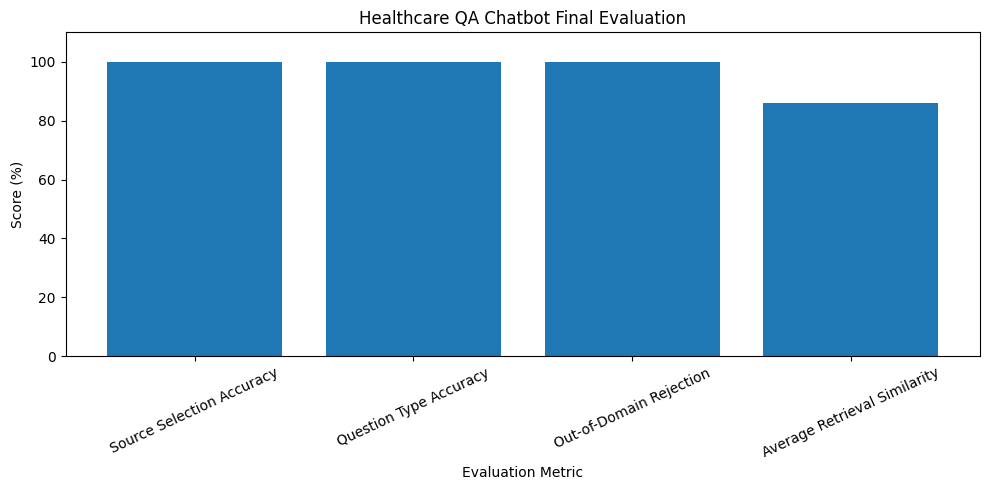

In [772]:
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# FINAL CHATBOT EVALUATION
# ============================================================

evaluation_questions = [
    # Structured Knowledge Base
    {
        "question": "What are the symptoms of diabetes?",
        "expected_source": "Structured Knowledge Base",
        "expected_type": "symptoms"
    },
    {
        "question": "What causes diabetes?",
        "expected_source": "Structured Knowledge Base",
        "expected_type": "causes"
    },
    {
        "question": "What are the treatments for diabetes?",
        "expected_source": "Structured Knowledge Base",
        "expected_type": "treatment"
    },
    {
        "question": "How can diabetes be prevented?",
        "expected_source": "Structured Knowledge Base",
        "expected_type": "prevention"
    },

    {
        "question": "What are the symptoms of malaria?",
        "expected_source": "Structured Knowledge Base",
        "expected_type": "symptoms"
    },
    {
        "question": "Who is at risk for malaria?",
        "expected_source": "Structured Knowledge Base",
        "expected_type": "susceptibility"
    },
    {
        "question": "How can malaria be prevented?",
        "expected_source": "Structured Knowledge Base",
        "expected_type": "prevention"
    },
    {
        "question": "What causes malaria?",
        "expected_source": "Structured Knowledge Base",
        "expected_type": "causes"
    },

    {
        "question": "What are the symptoms of dengue?",
        "expected_source": "Structured Knowledge Base",
        "expected_type": "symptoms"
    },
    {
        "question": "What causes dengue?",
        "expected_source": "Structured Knowledge Base",
        "expected_type": "causes"
    },
    {
        "question": "How can dengue be prevented?",
        "expected_source": "Structured Knowledge Base",
        "expected_type": "prevention"
    },
    {
        "question": "Who is at risk for dengue?",
        "expected_source": "Structured Knowledge Base",
        "expected_type": "susceptibility"
    },

    {
        "question": "What are the symptoms of asthma?",
        "expected_source": "Structured Knowledge Base",
        "expected_type": "symptoms"
    },
    {
        "question": "What are the treatments for asthma?",
        "expected_source": "Structured Knowledge Base",
        "expected_type": "treatment"
    },
    {
        "question": "What causes asthma?",
        "expected_source": "Structured Knowledge Base",
        "expected_type": "causes"
    },

    {
        "question": "What are the symptoms of tuberculosis?",
        "expected_source": "Structured Knowledge Base",
        "expected_type": "symptoms"
    },
    {
        "question": "What causes tuberculosis?",
        "expected_source": "Structured Knowledge Base",
        "expected_type": "causes"
    },

    # Semantic medical questions
    {
        "question": "How is tuberculosis diagnosed?",
        "expected_source": "MedQuAD Semantic IR",
        "expected_type": "exams and tests"
    },

    {
        "question": "I have a headache",
        "expected_source": "MedQuAD Semantic IR",
        "expected_type": "symptom_statement"
    },

    {
        "question": "I am feeling dizzy",
        "expected_source": "MedQuAD Semantic IR",
        "expected_type": "symptom_statement"
    },

    # Medical Wikipedia
    {
        "question": "What is anemia?",
        "expected_source": "Medical Wikipedia",
        "expected_type": "information"
    },

    # Out-of-domain
    {
        "question": "Who won the FIFA World Cup?",
        "expected_source": "No reliable source",
        "expected_type": "unknown"
    },

    {
        "question": "What is the capital of France?",
        "expected_source": "No reliable source",
        "expected_type": "unknown"
    },

    {
        "question": "cccccccccc",
        "expected_source": "No reliable source",
        "expected_type": "unknown"
    }
]


# ============================================================
# RUN EVALUATION
# ============================================================

evaluation_results = []

for item in evaluation_questions:

    question = item["question"]

    # Each question is evaluated independently
    current_topic = None

    result = healthcare_chat(
        question,
        current_topic
    )

    actual_source = result.get("source", "No reliable source")
    actual_type = result.get("question_type", "unknown")
    similarity = result.get("similarity", 0.0)

    evaluation_results.append({
        "question": question,
        "expected_source": item["expected_source"],
        "actual_source": actual_source,
        "expected_type": item["expected_type"],
        "actual_type": actual_type,
        "similarity": similarity
    })


evaluation_df = pd.DataFrame(evaluation_results)


# ============================================================
# SOURCE CORRECTNESS
# ============================================================

evaluation_df["source_correct"] = (
    evaluation_df["expected_source"]
    == evaluation_df["actual_source"]
)


# ============================================================
# QUESTION TYPE CORRECTNESS
# ============================================================

evaluation_df["type_correct"] = (
    evaluation_df["expected_type"]
    == evaluation_df["actual_type"]
)


# ============================================================
# OUT-OF-DOMAIN CORRECTNESS
# ============================================================

evaluation_df["ood_expected"] = (
    evaluation_df["expected_source"]
    == "No reliable source"
)

evaluation_df["ood_predicted"] = (
    evaluation_df["actual_source"]
    == "No reliable source"
)

evaluation_df["ood_correct"] = (
    evaluation_df["ood_expected"]
    == evaluation_df["ood_predicted"]
)


# ============================================================
# METRICS
# ============================================================

source_accuracy = (
    evaluation_df["source_correct"].mean() * 100
)

type_accuracy = (
    evaluation_df["type_correct"].mean() * 100
)

ood_accuracy = (
    evaluation_df["ood_correct"].mean() * 100
)

average_similarity = (
    evaluation_df["similarity"].mean() * 100
)


# ============================================================
# SUMMARY TABLE
# ============================================================

evaluation_summary = pd.DataFrame({
    "Metric": [
        "Source Selection Accuracy",
        "Question Type Accuracy",
        "Out-of-Domain Rejection",
        "Average Retrieval Similarity"
    ],
    "Score": [
        source_accuracy,
        type_accuracy,
        ood_accuracy,
        average_similarity
    ]
})


print("=" * 80)
print("FINAL HEALTHCARE QA CHATBOT EVALUATION")
print("=" * 80)

print(
    evaluation_summary.to_string(
        index=False,
        formatters={
            "Score": "{:.2f}".format
        }
    )
)

print("=" * 80)


# ============================================================
# SHOW ALL RESULTS
# ============================================================

print("\nDETAILED EVALUATION RESULTS")
print("=" * 80)

print(
    evaluation_df[
        [
            "question",
            "expected_source",
            "actual_source",
            "expected_type",
            "actual_type",
            "similarity"
        ]
    ].to_string(index=False)
)


# ============================================================
# SHOW INCORRECT SOURCE PREDICTIONS
# ============================================================

print("\nINCORRECT SOURCE PREDICTIONS")
print("=" * 80)

incorrect_sources = evaluation_df[
    evaluation_df["source_correct"] == False
]

if len(incorrect_sources) == 0:
    print("No incorrect source predictions.")
else:
    print(
        incorrect_sources[
            [
                "question",
                "expected_source",
                "actual_source",
                "similarity"
            ]
        ].to_string(index=False)
    )


# ============================================================
# SHOW INCORRECT QUESTION TYPES
# ============================================================

print("\nINCORRECT QUESTION TYPE PREDICTIONS")
print("=" * 80)

incorrect_types = evaluation_df[
    evaluation_df["type_correct"] == False
]

if len(incorrect_types) == 0:
    print("No incorrect question-type predictions.")
else:
    print(
        incorrect_types[
            [
                "question",
                "expected_type",
                "actual_type"
            ]
        ].to_string(index=False)
    )


# ============================================================
# FINAL GRAPH
# ============================================================

plt.figure(figsize=(10, 5))

plt.bar(
    evaluation_summary["Metric"],
    evaluation_summary["Score"]
)

plt.title("Healthcare QA Chatbot Final Evaluation")
plt.xlabel("Evaluation Metric")
plt.ylabel("Score (%)")
plt.xticks(rotation=25)
plt.ylim(0, 110)

plt.tight_layout()
plt.show()

In [774]:
# ============================================================
# FINAL INTERACTIVE HEALTHCARE QA CHATBOT
# ============================================================

print("=" * 70)
print("       HEALTHCARE QA CHATBOT")
print("=" * 70)
print("Ask a healthcare question.")
print("Type 'exit' to end the conversation.")
print("=" * 70)

current_topic = None

while True:

    question = input("\nYou: ").strip()

    if question.lower() == "exit":
        print("\nBot: Thank you. Goodbye!")
        print("Source: Dialogue Manager")
        print("Type: dialogue")
        break

    if not question:
        print("Bot: Please enter a healthcare-related question.")
        continue

    result = healthcare_chat(
        question,
        current_topic
    )

    print("\nBot:", result["answer"])
    print("Source:", result["source"])
    print("Type:", result["question_type"])

    if "current_topic" in result:
        current_topic = result["current_topic"]

    if current_topic is not None:
        print("Current Topic:", current_topic)

       HEALTHCARE QA CHATBOT
Ask a healthcare question.
Type 'exit' to end the conversation.



You:  Who won the FIFA World Cup?



Bot: I'm sorry, I could not find a reliable answer to that question.
Source: No reliable source
Type: unknown



You:  I have a headache



Bot: Not all headaches require medical attention. But some types of headache are signals of more serious disorders and call for prompt medical care. These include: sudden, severe headache or sudden headache associated with a stiff neck; headaches associated with fever, convulsions, or accompanied by confusion or loss of consciousness; headaches following a blow to the head, or associated with pain in the eye or ear; persistent headache in a person who was previously headache free; and recurring headache in children. Migraine headaches may last a day or more and can strike as often as several times a week or as rarely as once every few years.
Source: MedQuAD Semantic IR
Type: symptom_statement


...


Bot: fever, chills, sweating, headache, nausea, vomiting, muscle pain
Source: Structured Knowledge Base
Type: symptoms
Current Topic: malaria



You:  Who is at risk for it?



Bot: travel or residence in areas where malaria transmission occurs
Source: Structured Knowledge Base
Type: susceptibility
Current Topic: malaria



You:  exit



Bot: Thank you. Goodbye!
Source: Dialogue Manager
Type: dialogue


In [776]:
!pip install streamlit

Defaulting to user installation because normal site-packages is not writeable


DEPRECATION: Loading egg at c:\programdata\anaconda3\lib\site-packages\vboxapi-1.0-py3.11.egg is deprecated. pip 24.3 will enforce this behaviour change. A possible replacement is to use pip for package installation.. Discussion can be found at https://github.com/pypa/pip/issues/12330


In [778]:
import streamlit
print("Streamlit version:", streamlit.__version__)

Streamlit version: 1.30.0


In [780]:
healthcare_chat(question, current_topic)

{'answer': 'Thank you. Goodbye!',
 'source': 'Dialogue Manager',
 'question_type': 'dialogue',
 'similarity': 1.0,
 'current_topic': None}

In [784]:
import os
print(os.listdir())

['.ipynb_checkpoints', 'app.py', 'healthcare_knowledge.csv', 'Healthcare_QA_Chatbot.ipynb', 'medical_wikipedia_facts.csv', 'qa_test_set.csv']


In [786]:
!jupyter nbconvert --to script --output healthcare_backend Healthcare_QA_Chatbot.ipynb

[NbConvertApp] Converting notebook Healthcare_QA_Chatbot.ipynb to script
[NbConvertApp] Writing 199132 bytes to healthcare_backend.py


In [788]:
import os
print(os.listdir())

['.ipynb_checkpoints', 'app.py', 'healthcare_backend.py', 'healthcare_knowledge.csv', 'Healthcare_QA_Chatbot.ipynb', 'medical_wikipedia_facts.csv', 'qa_test_set.csv']


In [790]:
# ============================================================
# CLEAN HEALTHCARE BACKEND FOR STREAMLIT
# ============================================================

input_file = "healthcare_backend.py"
output_file = "healthcare_backend_clean.py"

with open(input_file, "r", encoding="utf-8") as f:
    lines = f.readlines()

cleaned_lines = []

for line in lines:

    if "get_ipython()" in line:
        continue

    cleaned_lines.append(line)

with open(output_file, "w", encoding="utf-8") as f:
    f.writelines(cleaned_lines)

print("Clean backend created successfully.")
print(output_file)

Clean backend created successfully.
healthcare_backend_clean.py


In [792]:
import os

if os.path.exists("healthcare_backend.py"):
    os.remove("healthcare_backend.py")

os.rename(
    "healthcare_backend_clean.py",
    "healthcare_backend.py"
)

print("healthcare_backend.py is now cleaned.")

healthcare_backend.py is now cleaned.


In [794]:
with open("healthcare_backend.py", "r", encoding="utf-8") as f:
    content = f.read()

if "get_ipython()" in content:
    print("Still contains get_ipython()")
else:
    print("SUCCESS: No get_ipython() found.")

SUCCESS: No get_ipython() found.


In [796]:
# ============================================================
# CREATE CLEAN STREAMLIT BACKEND FROM WORKING NOTEBOOK
# ============================================================

import nbformat
import re

notebook_file = "Healthcare_QA_Chatbot.ipynb"
backend_file = "healthcare_backend.py"

# Read notebook
with open(notebook_file, "r", encoding="utf-8") as f:
    notebook = nbformat.read(f, as_version=4)

# Collect code cells
code_cells = []

for cell in notebook.cells:

    if cell.cell_type == "code":

        code = cell.source

        # Remove Jupyter-only commands
        cleaned = []

        for line in code.splitlines():

            stripped = line.strip()

            if stripped.startswith("!"):
                continue

            if stripped.startswith("%"):
                continue

            if "get_ipython()" in line:
                continue

            # Skip notebook display-only commands
            if stripped.startswith("display("):
                continue

            cleaned.append(line)

        code = "\n".join(cleaned)

        if code.strip():
            code_cells.append(code)


# Find the healthcare_chat function
healthcare_chat_code = None

for code in code_cells:

    if re.search(
        r"^\s*def\s+healthcare_chat\s*\(",
        code,
        re.MULTILINE
    ):

        healthcare_chat_code = code
        break


if healthcare_chat_code is None:

    print("ERROR: healthcare_chat function was not found.")

else:

    print("SUCCESS: healthcare_chat function found.")

    # Create backend
    with open(
        backend_file,
        "w",
        encoding="utf-8"
    ) as f:

        f.write(
            "# ============================================================\n"
            "# HEALTHCARE QA CHATBOT BACKEND\n"
            "# ============================================================\n\n"
        )

        # Write all imports first
        for code in code_cells:

            for line in code.splitlines():

                if (
                    line.startswith("import ")
                    or line.startswith("from ")
                ):

                    f.write(line + "\n")

        f.write("\n")

        # Write the complete working code
        for code in code_cells:

            # Don't include interactive testing loops
            if "while True:" in code:
                continue

            # Don't include standalone print/test cells
            if code.strip().startswith("print("):
                continue

            f.write("\n")
            f.write(code)
            f.write("\n")


    print(
        "Created:",
        backend_file
    )

SUCCESS: healthcare_chat function found.
Created: healthcare_backend.py


In [798]:
import os

print(os.listdir())

with open(
    "healthcare_backend.py",
    "r",
    encoding="utf-8"
) as f:

    backend_text = f.read()

print(
    "\nhealthcare_chat found:",
    "def healthcare_chat(" in backend_text
)

['.ipynb_checkpoints', 'app.py', 'healthcare_backend.py', 'healthcare_knowledge.csv', 'Healthcare_QA_Chatbot.ipynb', 'medical_wikipedia_facts.csv', 'qa_test_set.csv', '__pycache__']

healthcare_chat found: True


In [800]:
import healthcare_backend

print("Backend imported successfully.")

print(
    "healthcare_chat:",
    hasattr(
        healthcare_backend,
        "healthcare_chat"
    )
)

IndentationError: unindent does not match any outer indentation level (healthcare_backend.py, line 4415)